# First Implementation 


>>There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


### Import


In [38]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise
import common
import frameData
import pose_estimator_gauss_newton


In [39]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



In [40]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Notebook utility functions




---
### Convert to frame, create a list of these frames

In [41]:
import convert_video_frame
convert_video_frame.video_to_frames_and_save(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\fake.mp4", r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake")

FPS : 24.0
Nombre total de trames : 121
121 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake


In [42]:
dossier_fake = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake")

In [43]:
fake_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_fake.rglob("*")
    if f.is_file()
)

print(f"{len(fake_frame_paths)} fichiers trouvés dans {dossier_fake}")

121 fichiers trouvés dans C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake


In [44]:

KEYFRAME_PATH = fake_frame_paths[0]
TARGET_PATH= fake_frame_paths[1]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake\frame_00000.png
C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake\frame_00001.png


Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.

In [45]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


### Extract keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [46]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


In [47]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake\frame_00000.png
keyframe_image shape = (832, 1104) dtype = uint8
keyframe_depth shape = (832, 1104) dtype = float32
depth min/max = 1.390641689300537 84.03084564208984
valid depth ratio = 1.0


Text(0.5, 1.0, 'Inverse depth')

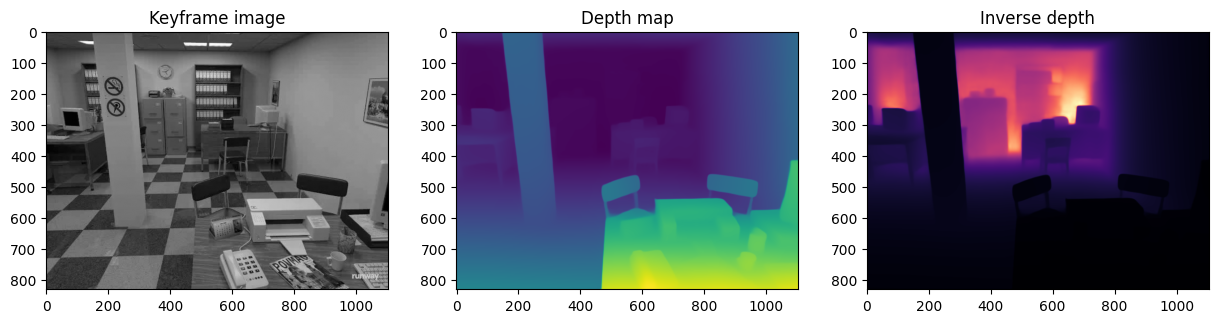

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




### **Intrinsics**




Dans ce notebook, les intrinseques doivent etre definies **une seule fois** dans la cellule suivante.

Idee simple :
- tu choisis `USER_FX`, `USER_FY`, `USER_CX`, `USER_CY`
- ces valeurs sont la **source de verite**
- elles sont passees a `camera.camera(...)`
- ensuite on affiche clairement ce que le pipeline utilise vraiment

Important :
- `frameData.py` et `camera.py` redimensionnent tout vers la resolution interne definie dans `params.py`
- donc on affiche a la fois :
  - `K_user` = la matrice que tu choisis
  - `K_used_lvl0` = la matrice effectivement utilisee au niveau 0 de la pyramide

Comme ca, il n'y a plus d'ambiguite sur les intrinseques utilisees dans la suite du notebook.


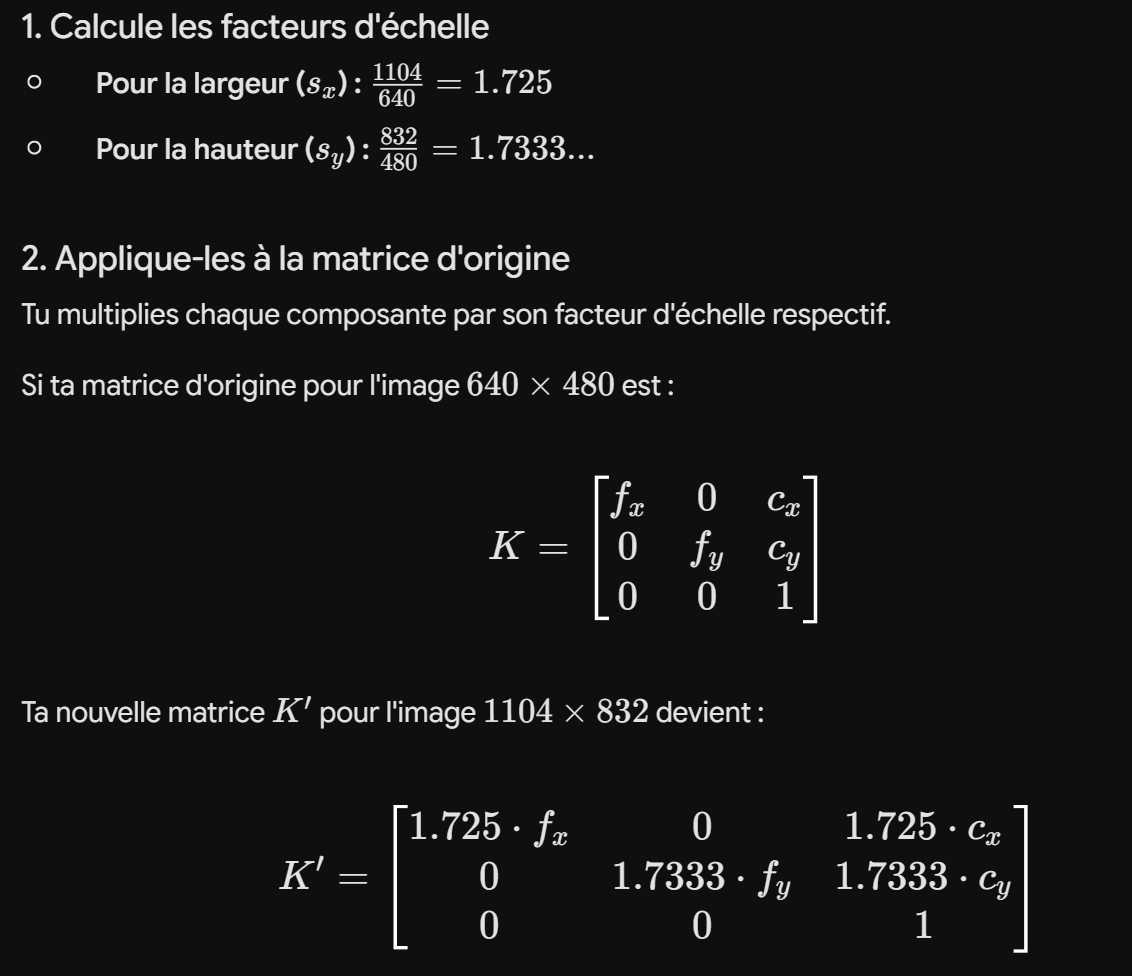

In [49]:

import base64
from IPython.display import HTML
with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\capture.png","rb") as f:
    with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\capture.png","rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')
HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')

In [50]:
# ==================================================
# Intrinseques a definir UNE FOIS au debut
# ==================================================
loaded_height, loaded_width = keyframe_image.shape[:2]

# Mets ici les intrinseques que tu veux utiliser.
# Ce bloc est la source de verite pour tout le notebook.
USER_WIDTH = loaded_width
USER_HEIGHT = loaded_height


#Pour Emanuel
USER_FX = 481.20 * 1.725
USER_FY = 480.0 * 1.73333
USER_CX = 319.5 * 1.725
USER_CY = 239.5 * 1.73333


#Pour tum RGB
#USER_FX = 525.0  # focal length x
#USER_FY = 525.0  # focal length y
#USER_CX = 319.5  # optical center x
#USER_CY = 239.5  # optical center y




intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

K_user = np.array([
    [USER_FX, 0.0, USER_CX],
    [0.0, USER_FY, USER_CY],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array([
    [cam.fx[0], 0.0, cam.cx[0]],
    [0.0, cam.fy[0], cam.cy[0]],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("USER intrinsics chosen at the beginning of the notebook:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Loaded keyframe size:
  width  = 1104
  height = 832

USER intrinsics chosen at the beginning of the notebook:
{'width': 1104, 'height': 832, 'fx': 830.07, 'fy': 831.9984000000001, 'cx': 551.1375, 'cy': 415.132535}

K_user =
[[830.07       0.       551.1375  ]
 [  0.       831.9984   415.132535]
 [  0.         0.         1.      ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[481.2        0.       319.5     ]
 [  0.       479.999077 239.499539]
 [  0.         0.         1.      ]]


In [51]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)

assert np.isclose(cam.fx[0], USER_FX * scale_x)
assert np.isclose(cam.fy[0], USER_FY * scale_y)
assert np.isclose(cam.cx[0], USER_CX * scale_x)
assert np.isclose(cam.cy[0], USER_CY * scale_y)

print()
print("Assertion passed: the notebook is using the intrinsics defined above.")


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 0.5797101449275363
  scale_y = 0.5769230769230769

  USER_FX -> cam.fx[0] : 830.07 -> 481.20000000000005
  USER_FY -> cam.fy[0] : 831.9984000000001 -> 479.9990769230769
  USER_CX -> cam.cx[0] : 551.1375 -> 319.50000000000006
  USER_CY -> cam.cy[0] : 415.132535 -> 239.49953942307693

Expected level-0 values after internal resize:
  expected fx = 481.20000000000005
  expected fy = 479.9990769230769
  expected cx = 319.50000000000006
  expected cy = 239.49953942307693

Assertion passed: the notebook is using the intrinsics defined above.


### Verification for every pyramid level

On affiche maintenant les intrinseques utilisees a **chaque niveau** de la pyramide, et on verifie qu elles correspondent bien a la regle automatique du code : division par `2**lvl` a partir du niveau 0.

In [52]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    expected_fx = base_fx / scale
    expected_fy = base_fy / scale
    expected_cx = base_cx / scale
    expected_cy = base_cy / scale
    expected_width = int(base_width / scale)
    expected_height = int(base_height / scale)

    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    assert np.isclose(cam.fx[lvl], expected_fx)
    assert np.isclose(cam.fy[lvl], expected_fy)
    assert np.isclose(cam.cx[lvl], expected_cx)
    assert np.isclose(cam.cy[lvl], expected_cy)
    assert cam.width[lvl] == expected_width
    assert cam.height[lvl] == expected_height

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()

print("All assertions passed: each level uses the expected intrinsics.")


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 481.200000, 479.999077
  cx, cy = 319.500000, 239.499539
  K =
[[481.2        0.       319.5     ]
 [  0.       479.999077 239.499539]
 [  0.         0.         1.      ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 240.600000, 239.999538
  cx, cy = 159.750000, 119.749770
  K =
[[240.6        0.       159.75    ]
 [  0.       239.999538 119.74977 ]
 [  0.         0.         1.      ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 120.300000, 119.999769
  cx, cy = 79.875000, 59.874885
  K =
[[120.3        0.        79.875   ]
 [  0.       119.999769  59.874885]
 [  0.         0.         1.      ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 60.150000, 59.999885
  cx, cy = 39.937500, 29.937442
  K =
[[60.15      0.       39.9375  ]
 [ 0.       59.999885 29.937442]
 [ 0.        0.        1.      ]]

LEVEL 4
  scale  = 1 / 16
  size   = 40 x 30
  fx, fy = 

In [53]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


### Extract the the current image




Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.

In [54]:
current_image_path = normalize_image_path(TARGET_PATH)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

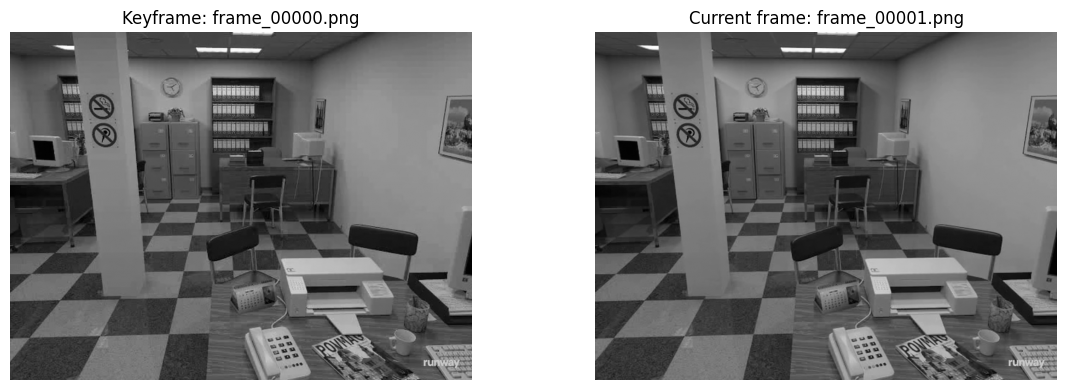

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


---
### **Initial pose and optimization updates**

Dans la cellule suivante, `pose_solver` est cree avec `cam`.
Donc les intrinseques utilisees pour l'estimation de pose sont bien celles affichees juste au-dessus.


In [56]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 481.20000000000005
  pose_solver.camera.fy[0] = 479.9990769230769
  pose_solver.camera.cx[0] = 319.50000000000006
  pose_solver.camera.cy[0] = 239.49953942307693

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 481.20000000000005, 'fy': 479.9990769230769, 'cx': 319.50000000000006, 'cy': 239.49953942307693}

Initial photometric errors before optimization:
  level 4 = 97.82301740812363
  level 3 = 83.81394306209356
  level 2 = 93.63231092663462


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [57]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  97.82301740812363
 error improvement too small, level converged! it:  2  error:  92.12557303956643  lambda:  0.0
lvl:  3  initial error:  78.78321810583937
 error improvement too small, level converged! it:  3  error:  73.21900336727386  lambda:  0.0
lvl:  2  initial error:  70.98244908477989
 error improvement too small, level converged! it:  2  error:  70.2621639699289  lambda:  0.0
Final photometric errors after optimization:
  level 4 = 93.96316596056025
  level 3 = 73.70316562376428
  level 2 = 70.2621639699289


#### Sanity check on pose estimation

Ici on verifie que le resultat a du sens :
- les erreurs photometriques doivent baisser apres optimisation
- la pose finale doit contenir des valeurs finies
- on veut aussi garder une trace interpretable du gain obtenu a chaque niveau.

In [58]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
}

error_improvement = {
    "lvl4": float(initial_error_lvl4 - final_error_lvl4),
    "lvl3": float(initial_error_lvl3 - final_error_lvl3),
    "lvl2": float(initial_error_lvl2 - final_error_lvl2),
}

print("Optimization summary:")
for lvl in [4, 3, 2]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = error_improvement[f"lvl{lvl}"]
    print(f"  level {lvl}: initial={initial_value:.6f}, final={final_value:.6f}, improvement={improvement:.6f}")

pose_matrix_now = current_frame.pose.as_matrix()
pose_is_finite = bool(np.isfinite(pose_matrix_now).all())
errors_improved = {lvl: (error_improvement[f"lvl{lvl}"] > 0.0) for lvl in [4, 3, 2]}

print()
print("Pose matrix finite ->", pose_is_finite)
print("Errors improved by level ->", errors_improved)

assert pose_is_finite, "Pose matrix contains non-finite values."
assert all(errors_improved.values()), "At least one pyramid level did not improve after optimization."

print()
print("Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.")


Optimization summary:
  level 4: initial=97.823017, final=93.963166, improvement=3.859851
  level 3: initial=83.813943, final=73.703166, improvement=10.110777
  level 2: initial=93.632311, final=70.262164, improvement=23.370147

Pose matrix finite -> True
Errors improved by level -> {4: True, 3: True, 2: True}

Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.


### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [59]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 0.999998 -0.000517 -0.002067  0.003614]
 [ 0.000518  1.        0.000527 -0.002194]
 [ 0.002067 -0.000528  0.999998  0.003952]
 [ 0.        0.        0.        1.      ]]


--
Comparaison avec le GT

In [60]:
GT_Pose = np.array([
    [0.999994773, -0.001180835, -0.002703893, -0.017635176],
    [0.001167188,  0.999986898, -0.005040318, -0.021989598],
    [0.002709795,  0.005037578,  0.999983107,  0.000817620],
    [0.0,          0.0,          0.0,          1.0],
], dtype=np.float64)


Difference = extrinsic_matrix - GT_Pose
A = np.round(Difference, 2)  # 1 chiffre après la virgule

print(A)

[[ 0.    0.    0.    0.02]
 [-0.    0.    0.01  0.02]
 [-0.   -0.01  0.    0.  ]
 [ 0.    0.    0.    0.  ]]


----------- 

---
### **x'=HX (core of the NoteBook)**

On garde maintenant **une seule metrique** : la **photometric error**.

Definition :
- on reprojecte chaque pixel valide du keyframe dans l image courante
- on compare l intensite du keyframe a l intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides



In [61]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "level": lvl,
    }


---
### Evaluation

In [62]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)

In [63]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 6868395.0


In [64]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]

total_valid_pixels = int(valid_abs_errors.size)
num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))





num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))








print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 304545
  difference > 200         = 0
  150 <= difference <= 200 = 0
  100 <= difference < 150  = 14
   50 <= difference < 100  = 209
   30 <= difference < 50   = 921
   10 <= difference < 30   = 10737
    0 <= difference < 10   = 292664


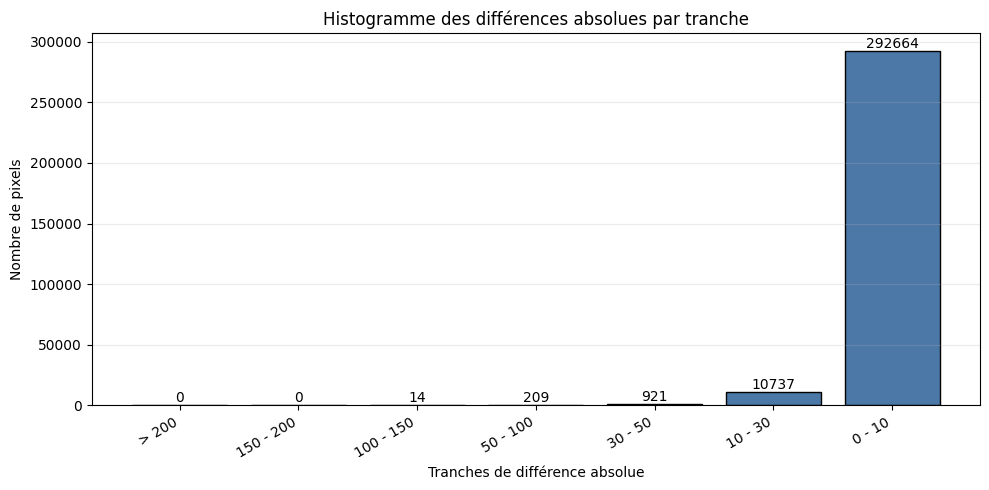

In [65]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des différences absolues par tranche")
plt.xlabel("Tranches de différence absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


### Squared photometric error map

Cette figure n ajoute pas une nouvelle metrique.
Elle sert seulement a voir **ou** l erreur photometrique se concentre dans l image.


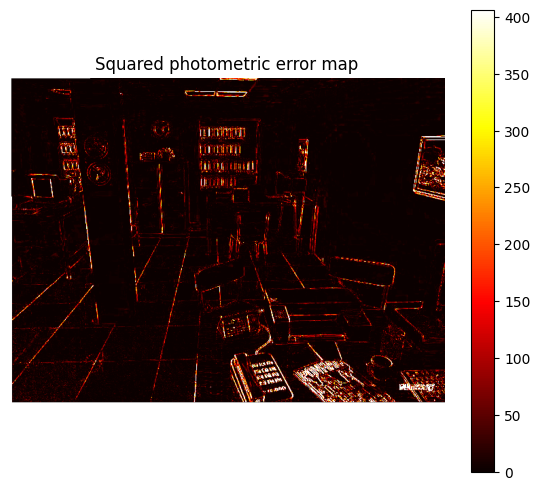

In [66]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.show()


In [67]:
print("Only evaluation metric used in this notebook:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")


Only evaluation metric used in this notebook:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels


------
### **Scale sur toutes les images**

In [68]:
print(fake_frame_paths[0])

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\frames_fake\frame_00000.png


Sequence fake:
  source size = 1104 x 832
  working size level-0 = 640 x 480
  fx level-0 = 481.20000000000005
  fy level-0 = 479.9990769230769

[fake] frame 0 -> keyframe de reference: frame_00000.png
lvl:  4  initial error:  97.82301740812363
 error improvement too small, level converged! it:  2  error:  92.12557303956643  lambda:  0.0
lvl:  3  initial error:  78.78321810583937
 error improvement too small, level converged! it:  3  error:  73.21900336727386  lambda:  0.0
lvl:  2  initial error:  70.98244908477989
 error improvement too small, level converged! it:  2  error:  70.2621639699289  lambda:  0.0
[fake] frame 1 -> frame_00001.png | sum error = 6868395.00 | mean abs error = 2.2338 | valid pixels = 304545


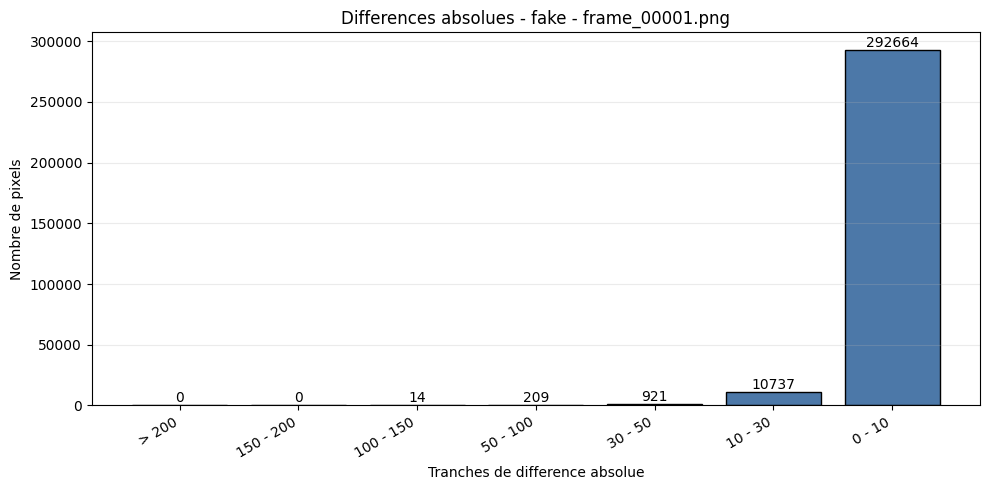

lvl:  4  initial error:  189.03868471953552
 error improvement too small, level converged! it:  2  error:  170.84515537858707  lambda:  0.0
lvl:  3  initial error:  154.56747212588962
 error improvement too small, level converged! it:  3  error:  146.29201881935876  lambda:  0.0
lvl:  2  initial error:  97.06834295724866
update too small, level converged! it:  2  error:  92.90934014657495  lambda:  14073748835532.8
[fake] frame 2 -> frame_00002.png | sum error = 17868738.00 | mean abs error = 3.5715 | valid pixels = 304097


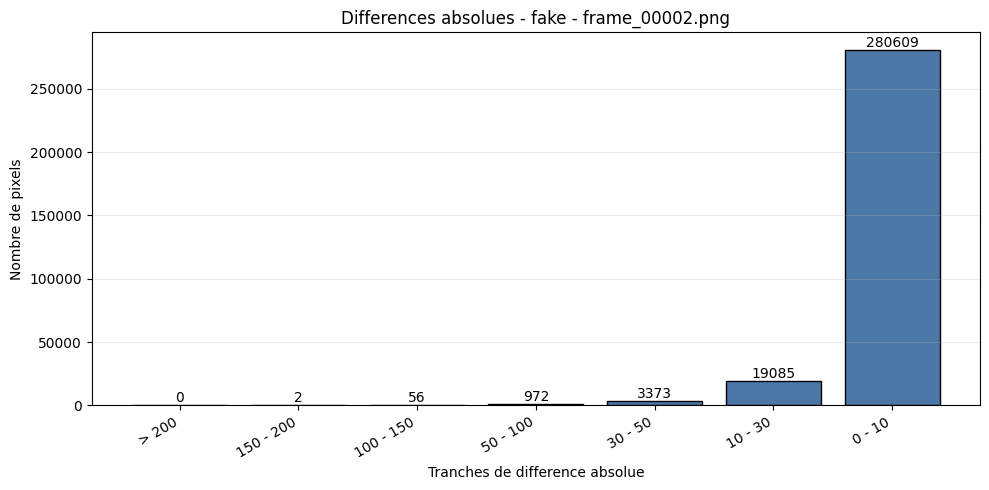

lvl:  4  initial error:  271.02127659574427
 error improvement too small, level converged! it:  5  error:  232.48112469763734  lambda:  51.2
lvl:  3  initial error:  209.21429386407274
 error improvement too small, level converged! it:  4  error:  188.05253919605832  lambda:  219902325555.2
lvl:  2  initial error:  134.94795330683775
update too small, level converged! it:  2  error:  134.00606300004185  lambda:  14073748835532.8
[fake] frame 3 -> frame_00003.png | sum error = 31200860.00 | mean abs error = 4.5818 | valid pixels = 303722


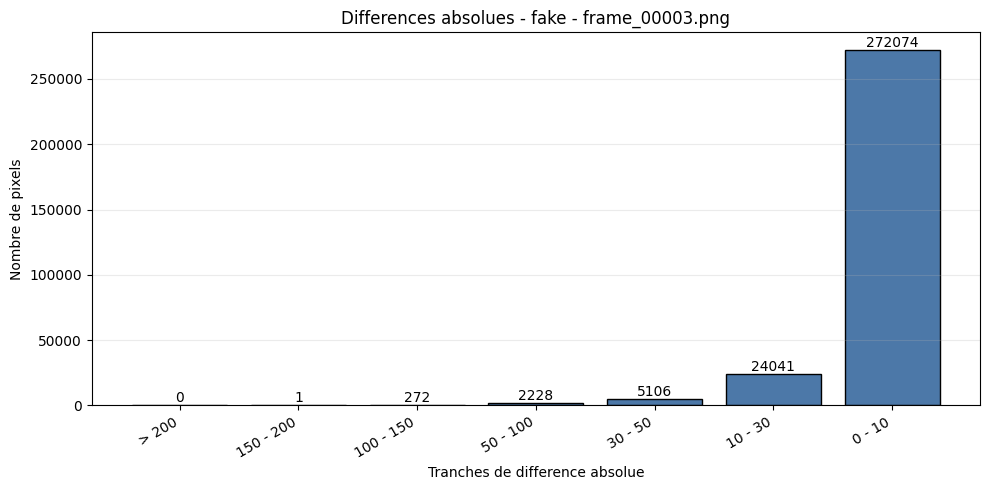

lvl:  4  initial error:  354.3955512572529
 error improvement too small, level converged! it:  5  error:  285.9241349761741  lambda:  0.0
lvl:  3  initial error:  238.78447383985397
 error improvement too small, level converged! it:  4  error:  201.6034305370789  lambda:  0.8
lvl:  2  initial error:  170.08008111685587
update too small, level converged! it:  2  error:  161.33623652692083  lambda:  28147497671065.6
[fake] frame 4 -> frame_00004.png | sum error = 45485128.00 | mean abs error = 5.6935 | valid pixels = 302877


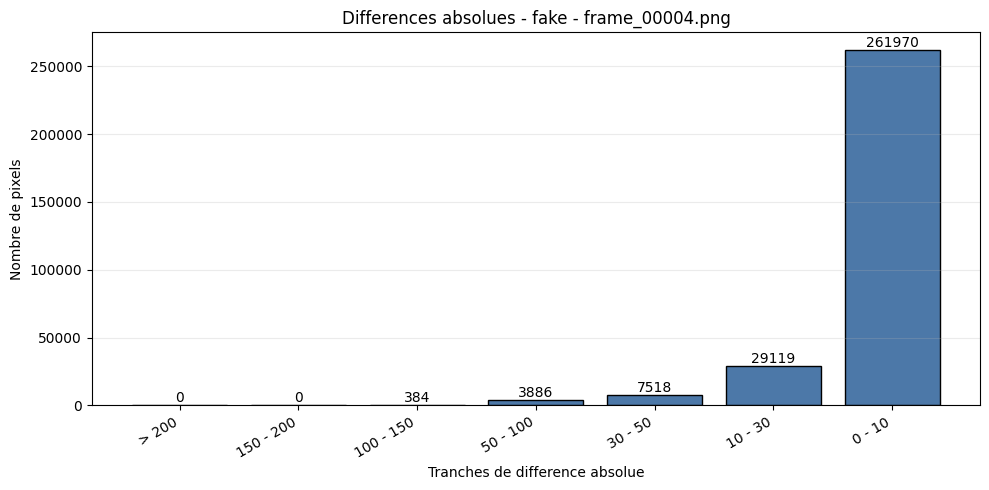

lvl:  4  initial error:  406.1324951644095
 error improvement too small, level converged! it:  5  error:  317.26438184814674  lambda:  1.6
lvl:  3  initial error:  261.9740032036961
update too small, level converged! it:  4  error:  224.8555668932368  lambda:  7036874417766.4
lvl:  2  initial error:  175.0716226717981
 error improvement too small, level converged! it:  2  error:  174.79352705047322  lambda:  3518437208883.2
[fake] frame 5 -> frame_00005.png | sum error = 56224936.00 | mean abs error = 6.2591 | valid pixels = 302438


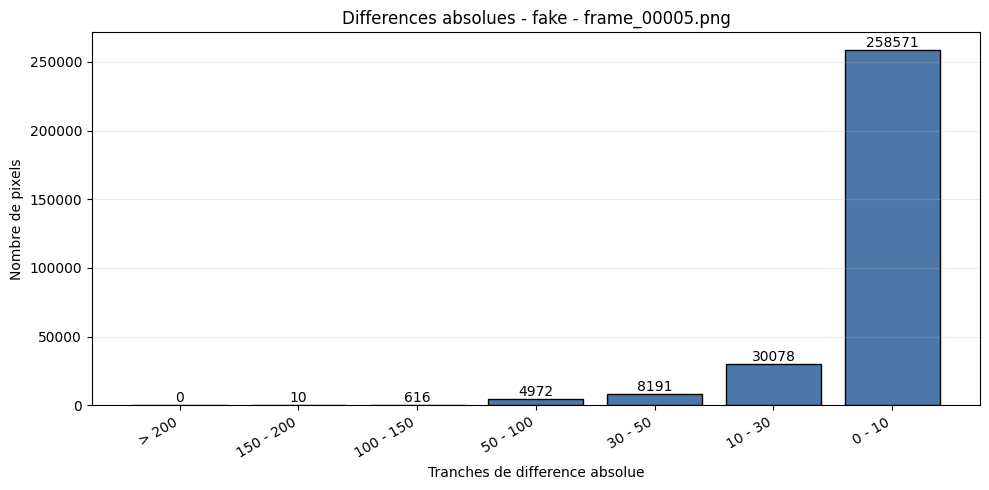

lvl:  4  initial error:  507.6818181818175
 error improvement too small, level converged! it:  5  error:  365.92352404139837  lambda:  0.0
lvl:  3  initial error:  289.3297891964909
 error improvement too small, level converged! it:  4  error:  259.61043228315475  lambda:  109951162777.6
lvl:  2  initial error:  207.58044895365956
 error improvement too small, level converged! it:  1  error:  207.4267810131864  lambda:  0.2
[fake] frame 6 -> frame_00006.png | sum error = 64860916.00 | mean abs error = 6.7848 | valid pixels = 301834


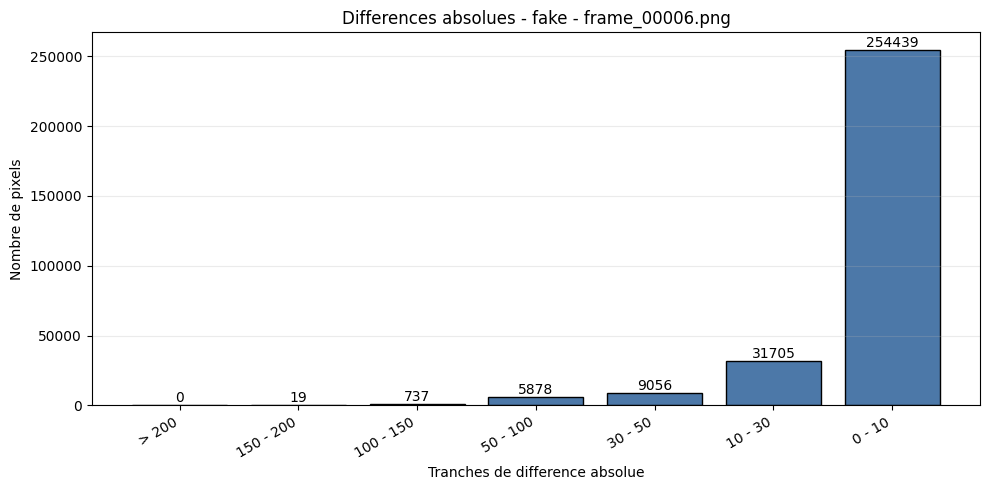

lvl:  4  initial error:  554.1324951644096
 error improvement too small, level converged! it:  6  error:  381.3358458681132  lambda:  0.0
lvl:  3  initial error:  297.5563266452192
 error improvement too small, level converged! it:  4  error:  287.75884773878073  lambda:  109951162777.6
lvl:  2  initial error:  244.92385760169566
 error improvement too small, level converged! it:  2  error:  238.53893535382386  lambda:  1759218604441.6
[fake] frame 7 -> frame_00007.png | sum error = 75454080.00 | mean abs error = 7.4854 | valid pixels = 300985


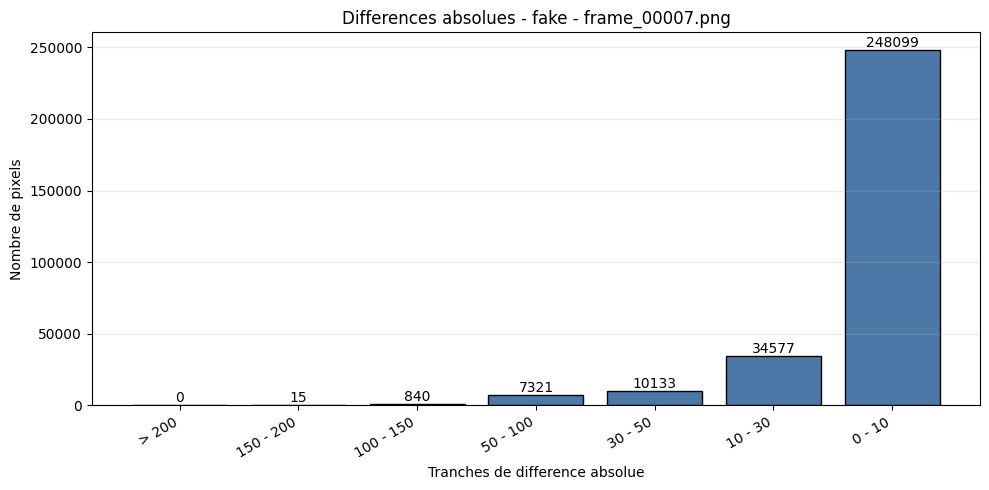

lvl:  4  initial error:  607.2301740812371
 error improvement too small, level converged! it:  5  error:  390.8974228023114  lambda:  219902325555.2
lvl:  3  initial error:  316.2219958539965
 error improvement too small, level converged! it:  3  error:  282.04773739795417  lambda:  219902325555.2
lvl:  2  initial error:  258.23391792283394
 error improvement too small, level converged! it:  2  error:  248.90191335871387  lambda:  7036874417766.4
[fake] frame 8 -> frame_00008.png | sum error = 81149648.00 | mean abs error = 7.8038 | valid pixels = 300556


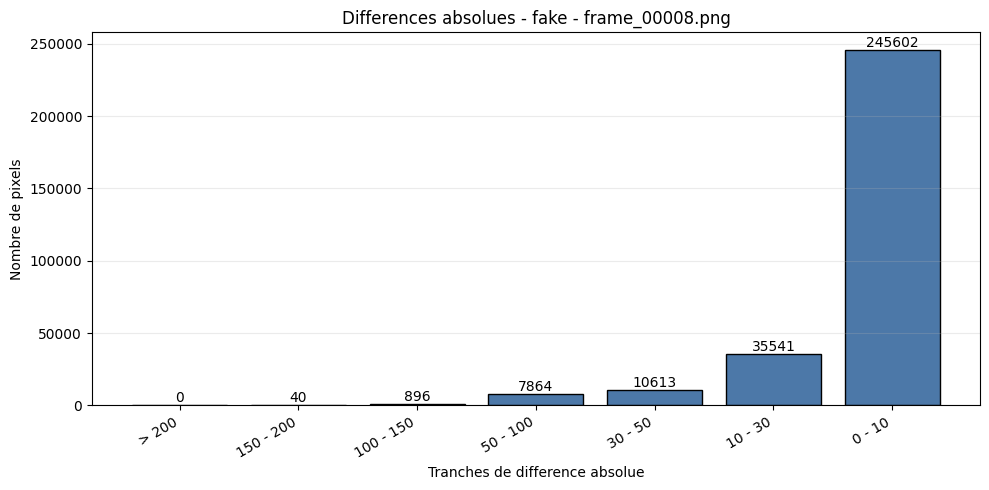

lvl:  4  initial error:  721.6286266924559
 error improvement too small, level converged! it:  4  error:  421.8764723512271  lambda:  0.1
lvl:  3  initial error:  308.7177862345388
 error improvement too small, level converged! it:  3  error:  274.6509191163545  lambda:  0.0
lvl:  2  initial error:  276.56667411466736
update too small, level converged! it:  4  error:  260.9969851697017  lambda:  14073748835532.8
[fake] frame 9 -> frame_00009.png | sum error = 87125912.00 | mean abs error = 8.1302 | valid pixels = 300056


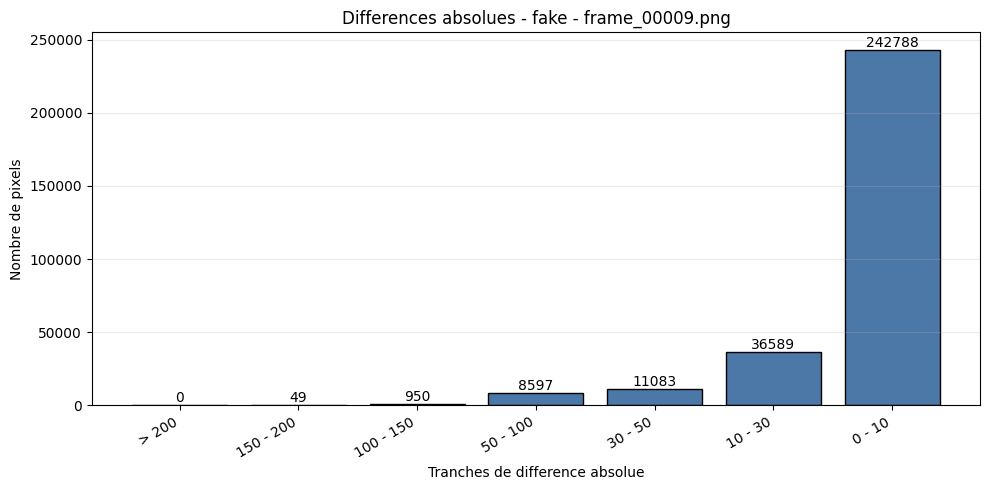

lvl:  4  initial error:  804.2659574468079
 error improvement too small, level converged! it:  5  error:  439.10507210565294  lambda:  879609302220.8
lvl:  3  initial error:  316.1816600553039
 error improvement too small, level converged! it:  3  error:  290.8603435640878  lambda:  0.4
lvl:  2  initial error:  302.2486362475872
 error improvement too small, level converged! it:  4  error:  287.4135228138338  lambda:  0.0
[fake] frame 10 -> frame_00010.png | sum error = 95512592.00 | mean abs error = 8.6079 | valid pixels = 299416


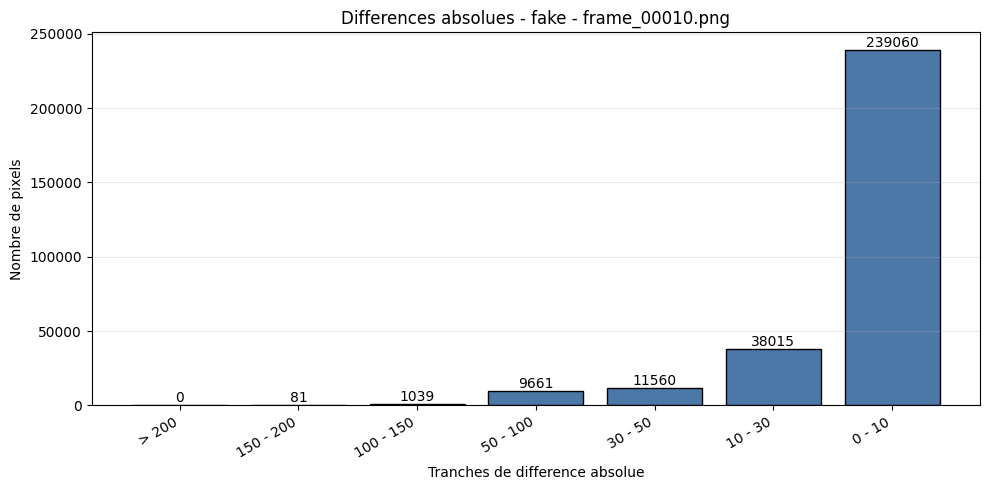

lvl:  4  initial error:  875.8829787234033
 error improvement too small, level converged! it:  5  error:  455.5171504745205  lambda:  0.1
lvl:  3  initial error:  344.43793217940976
 error improvement too small, level converged! it:  4  error:  306.1239636358897  lambda:  439804651110.4
lvl:  2  initial error:  340.2126478436959
 error improvement too small, level converged! it:  4  error:  323.7619330722014  lambda:  0.0
[fake] frame 11 -> frame_00011.png | sum error = 103862224.00 | mean abs error = 9.0616 | valid pixels = 298855


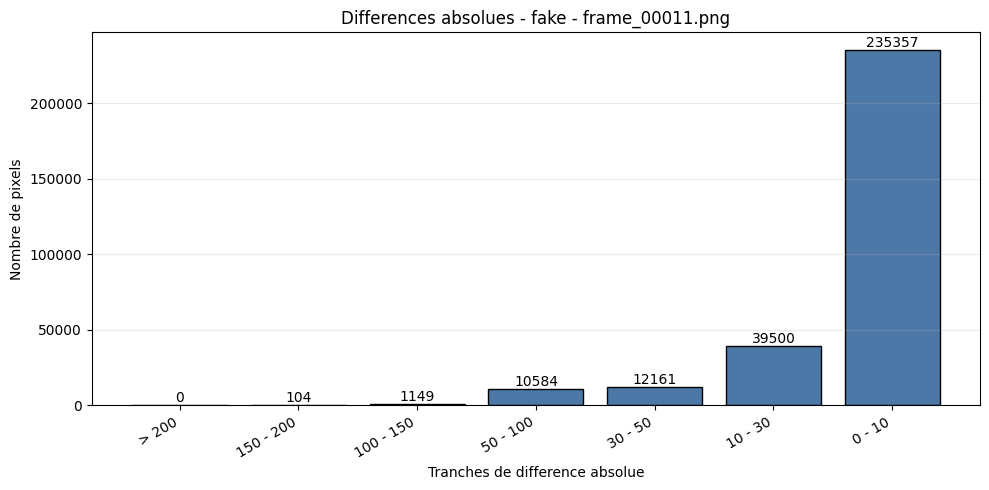

lvl:  4  initial error:  928.1005802707923
 error improvement too small, level converged! it:  3  error:  488.00992557069304  lambda:  0.1
lvl:  3  initial error:  387.67375948696827
 error improvement too small, level converged! it:  4  error:  356.7093790975143  lambda:  879609302220.8
lvl:  2  initial error:  359.68601248167397
 error improvement too small, level converged! it:  4  error:  349.4853624040166  lambda:  0.0
[fake] frame 12 -> frame_00012.png | sum error = 112895600.00 | mean abs error = 9.5767 | valid pixels = 298221


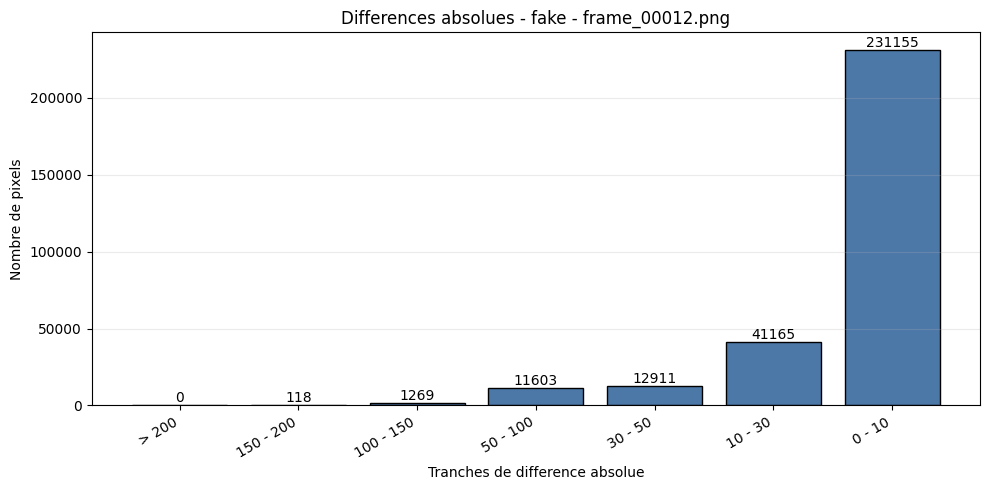

lvl:  4  initial error:  992.4922630560916
 error improvement too small, level converged! it:  3  error:  503.99649979025213  lambda:  25.6
lvl:  3  initial error:  406.8973790761573
 error improvement too small, level converged! it:  4  error:  376.681679965395  lambda:  879609302220.8
lvl:  2  initial error:  384.3118347024127
 error improvement too small, level converged! it:  2  error:  367.7414584650545  lambda:  3.2
[fake] frame 13 -> frame_00013.png | sum error = 122051192.00 | mean abs error = 10.0770 | valid pixels = 297479


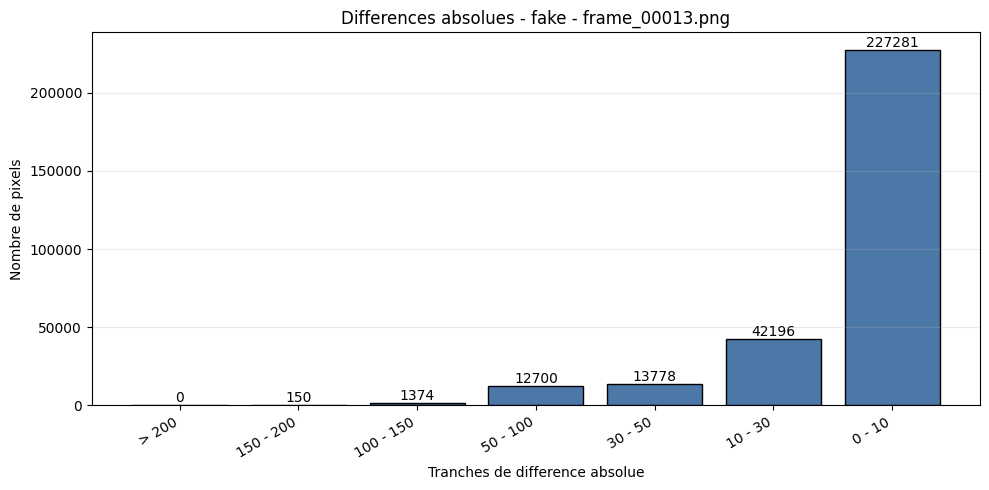

lvl:  4  initial error:  1085.6276595744669
 error improvement too small, level converged! it:  3  error:  530.6634380514042  lambda:  12.8
lvl:  3  initial error:  436.1271059981576
 error improvement too small, level converged! it:  3  error:  397.4423627444205  lambda:  0.4
lvl:  2  initial error:  416.75426702542006
 error improvement too small, level converged! it:  4  error:  397.76218565711036  lambda:  0.0
[fake] frame 14 -> frame_00014.png | sum error = 130683272.00 | mean abs error = 10.5405 | valid pixels = 297005


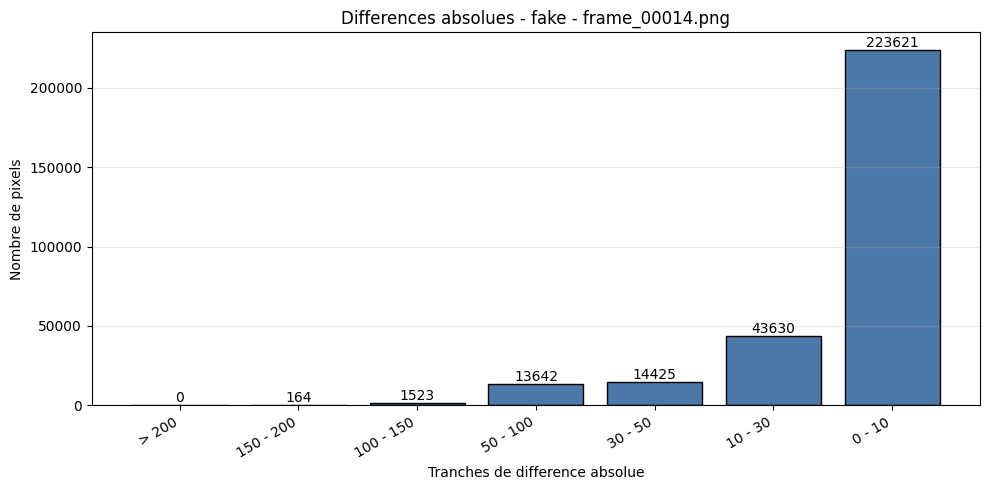

xFormers not available
xFormers not available


Depth Anything loaded on cpu (97.47M parameters)
lvl:  4  initial error:  1131.6373307543506
 error improvement too small, level converged! it:  4  error:  513.8110127137464  lambda:  0.0
lvl:  3  initial error:  457.7983503167442
 error improvement too small, level converged! it:  3  error:  416.6543254979476  lambda:  0.8
lvl:  2  initial error:  450.8346817651028
 error improvement too small, level converged! it:  6  error:  424.04338191639664  lambda:  0.0
[fake] frame 15 -> frame_00015.png | sum error = 136736576.00 | mean abs error = 10.8720 | valid pixels = 296446


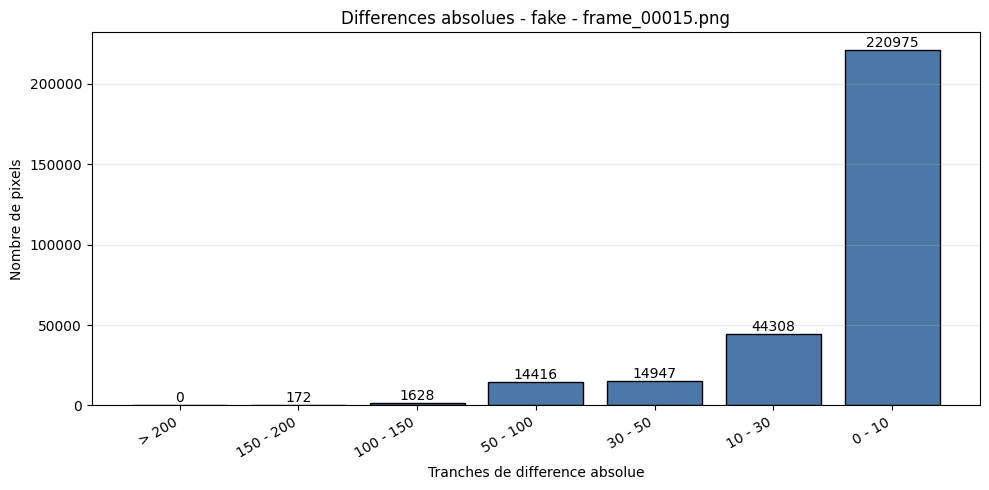

lvl:  4  initial error:  1193.1856866537705
update too small, level converged! it:  5  error:  511.1222575983312  lambda:  56294995342131.2
lvl:  3  initial error:  487.0112966579106
 error improvement too small, level converged! it:  3  error:  443.38849427546063  lambda:  3.2
lvl:  2  initial error:  465.998693127895
update too small, level converged! it:  2  error:  457.3068379139908  lambda:  112589990684262.4
[fake] frame 16 -> frame_00016.png | sum error = 147232304.00 | mean abs error = 11.5103 | valid pixels = 295353


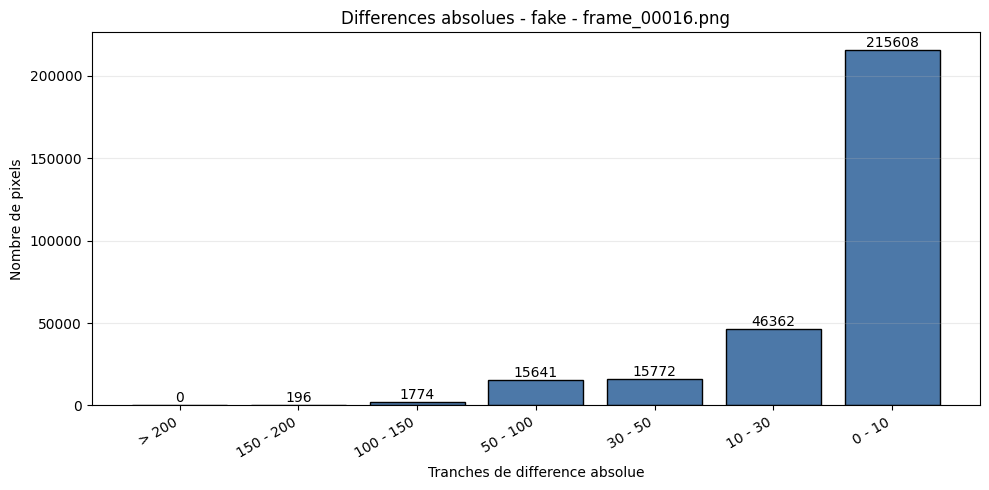

lvl:  4  initial error:  1260.3858800773683
 error improvement too small, level converged! it:  3  error:  531.1455925579529  lambda:  1.6
lvl:  3  initial error:  525.7779589605673
 error improvement too small, level converged! it:  3  error:  446.10014201147595  lambda:  3518437208883.2
lvl:  2  initial error:  480.62700919105856
 error improvement too small, level converged! it:  2  error:  464.23144667975566  lambda:  12.8
[fake] frame 17 -> frame_00017.png | sum error = 153209584.00 | mean abs error = 11.7989 | valid pixels = 294871


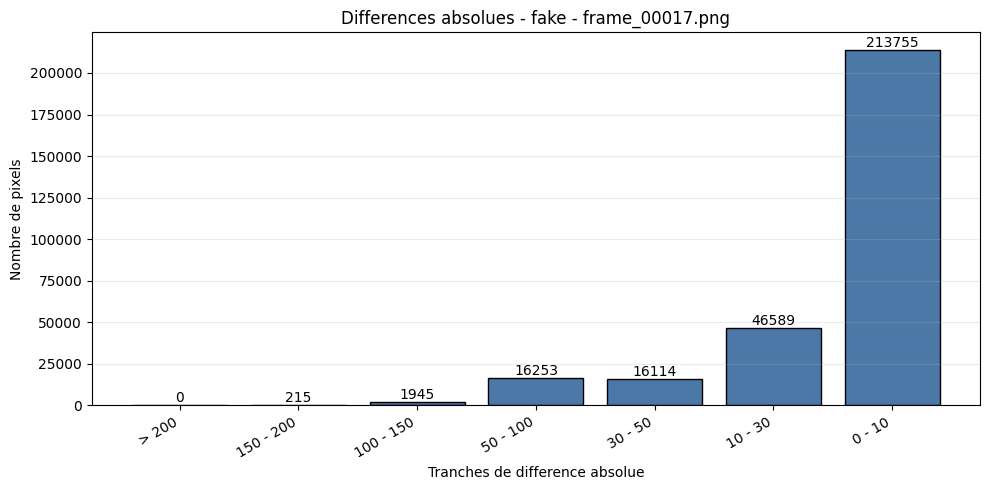

lvl:  4  initial error:  1287.7543520309466
 error improvement too small, level converged! it:  4  error:  545.0144696768563  lambda:  7036874417766.4
lvl:  3  initial error:  557.8472136328623
 error improvement too small, level converged! it:  3  error:  456.42846642711186  lambda:  0.4
lvl:  2  initial error:  506.9302729302652
 error improvement too small, level converged! it:  5  error:  479.2235620106995  lambda:  0.4
[fake] frame 18 -> frame_00018.png | sum error = 159530704.00 | mean abs error = 12.0622 | valid pixels = 294580


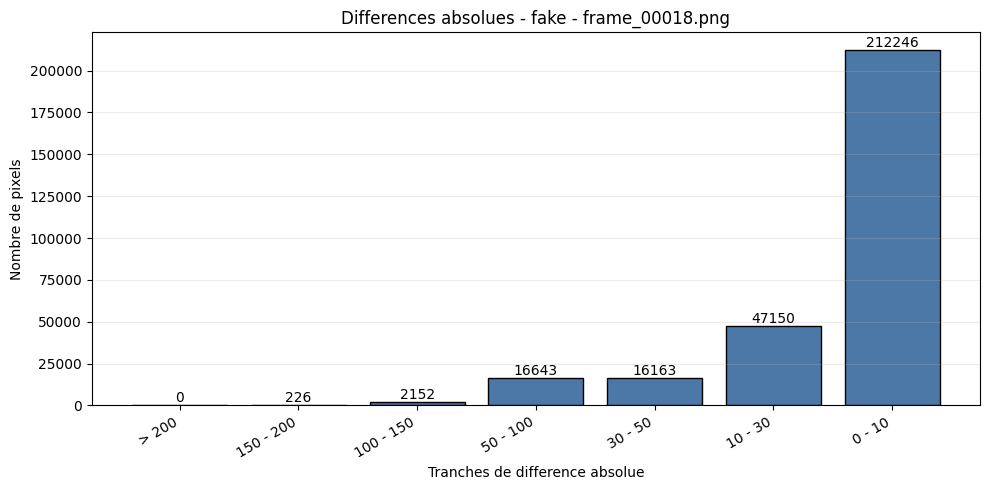

lvl:  4  initial error:  1382.6924564796893
 error improvement too small, level converged! it:  3  error:  527.4954329566275  lambda:  0.4
lvl:  3  initial error:  571.5543787226243
 error improvement too small, level converged! it:  3  error:  488.9912848944724  lambda:  0.4
lvl:  2  initial error:  541.5563559726958
 error improvement too small, level converged! it:  2  error:  527.2546153488522  lambda:  0.0
[fake] frame 19 -> frame_00019.png | sum error = 168591584.00 | mean abs error = 12.5658 | valid pixels = 293777


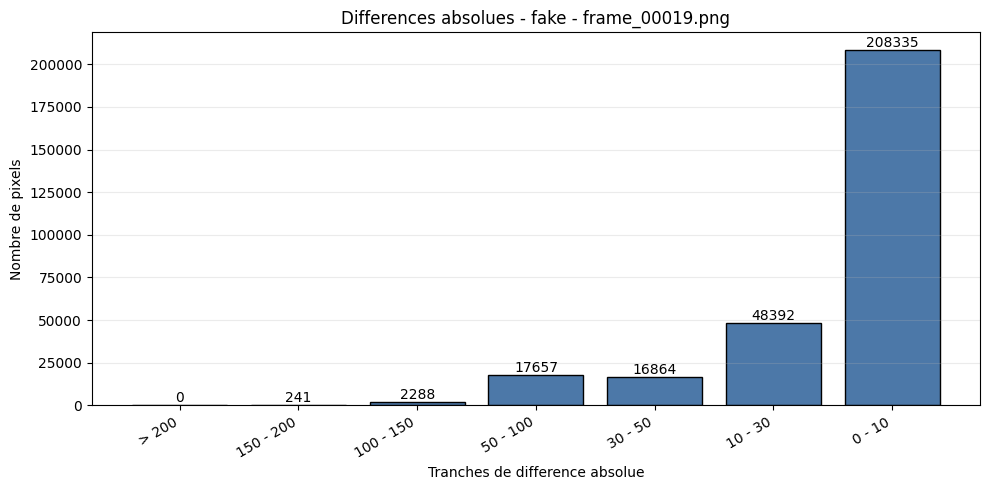

lvl:  4  initial error:  1427.0918762088966
 error improvement too small, level converged! it:  3  error:  547.7142367963403  lambda:  0.0
lvl:  3  initial error:  612.5757320371891
 error improvement too small, level converged! it:  3  error:  550.0171861799934  lambda:  54975581388.8
lvl:  2  initial error:  557.2920047570472
 error improvement too small, level converged! it:  2  error:  545.9816451207381  lambda:  3518437208883.2
[fake] frame 20 -> frame_00020.png | sum error = 178294208.00 | mean abs error = 13.1250 | valid pixels = 292868


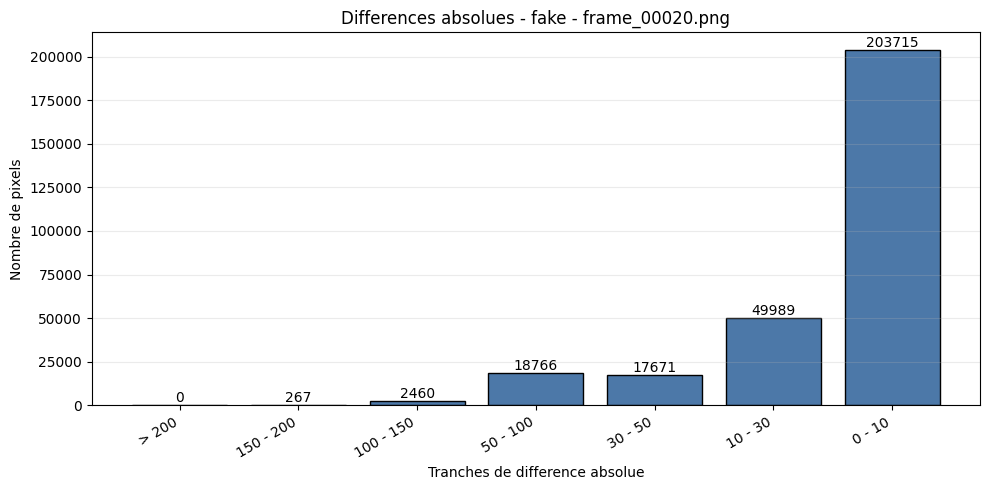

lvl:  4  initial error:  1482.9061895551247
 error improvement too small, level converged! it:  5  error:  571.9679809918302  lambda:  439804651110.4
lvl:  3  initial error:  656.4206292580837
 error improvement too small, level converged! it:  3  error:  584.8441020931095  lambda:  0.0
lvl:  2  initial error:  596.0264023068247
 error improvement too small, level converged! it:  2  error:  571.7074958781318  lambda:  28147497671065.6
[fake] frame 21 -> frame_00021.png | sum error = 185106224.00 | mean abs error = 13.4788 | valid pixels = 292223


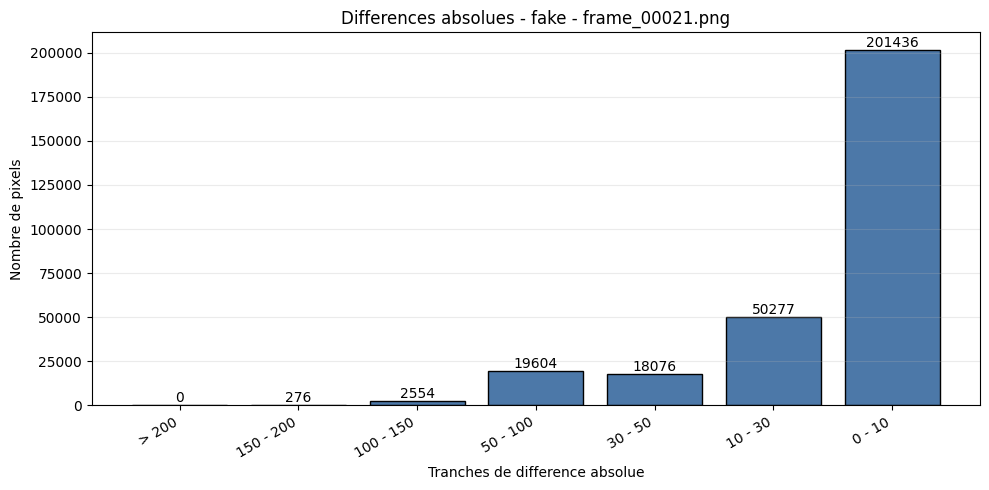

lvl:  4  initial error:  1524.6789168278515
 error improvement too small, level converged! it:  4  error:  591.4942495724638  lambda:  1.6
lvl:  3  initial error:  650.3506977197541
 error improvement too small, level converged! it:  4  error:  587.7821149882508  lambda:  0.0
lvl:  2  initial error:  628.8416845528931
 error improvement too small, level converged! it:  6  error:  595.6382382778166  lambda:  0.1
[fake] frame 22 -> frame_00022.png | sum error = 189592112.00 | mean abs error = 13.6568 | valid pixels = 292072


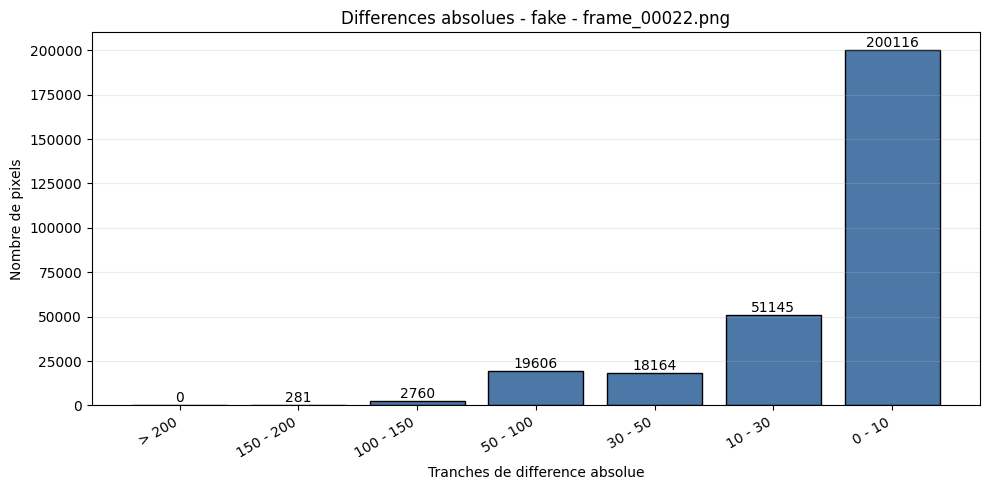

lvl:  4  initial error:  1542.1353965183737
update too small, level converged! it:  5  error:  624.8883078933467  lambda:  225179981368524.8
lvl:  3  initial error:  665.8907465672302
 error improvement too small, level converged! it:  4  error:  610.7650577926914  lambda:  0.0
lvl:  2  initial error:  650.1189232307693
 error improvement too small, level converged! it:  2  error:  629.2464812872779  lambda:  0.0
[fake] frame 23 -> frame_00023.png | sum error = 198125824.00 | mean abs error = 14.2048 | valid pixels = 291019


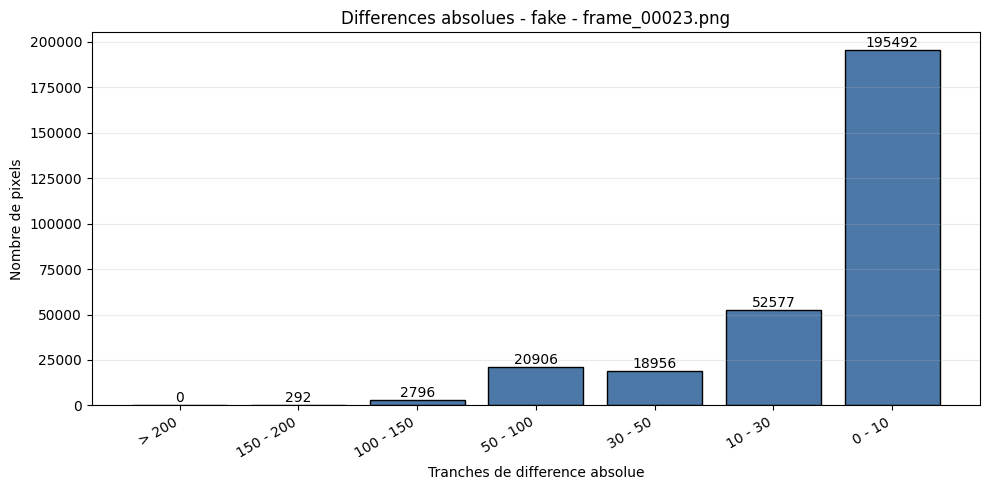

lvl:  4  initial error:  1608.932301740811
 error improvement too small, level converged! it:  5  error:  662.4607920181538  lambda:  3.2
lvl:  3  initial error:  682.3175722509128
 error improvement too small, level converged! it:  4  error:  639.8162638107319  lambda:  0.0
lvl:  2  initial error:  673.5206787834484
 error improvement too small, level converged! it:  2  error:  649.6208862566847  lambda:  0.0
[fake] frame 24 -> frame_00024.png | sum error = 205059520.00 | mean abs error = 14.6172 | valid pixels = 290371


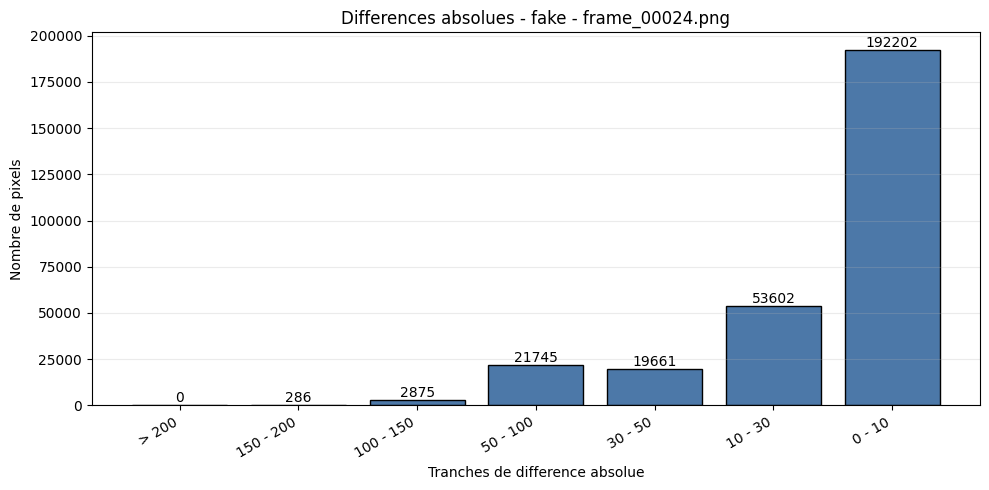

lvl:  4  initial error:  1685.8617021276582
 error improvement too small, level converged! it:  5  error:  686.745218403623  lambda:  6.4
lvl:  3  initial error:  705.2269361468058
 error improvement too small, level converged! it:  3  error:  653.880356671707  lambda:  0.2
lvl:  2  initial error:  693.1851682412037
 error improvement too small, level converged! it:  5  error:  658.2617260366698  lambda:  0.8
[fake] frame 25 -> frame_00025.png | sum error = 209605280.00 | mean abs error = 14.8194 | valid pixels = 289800


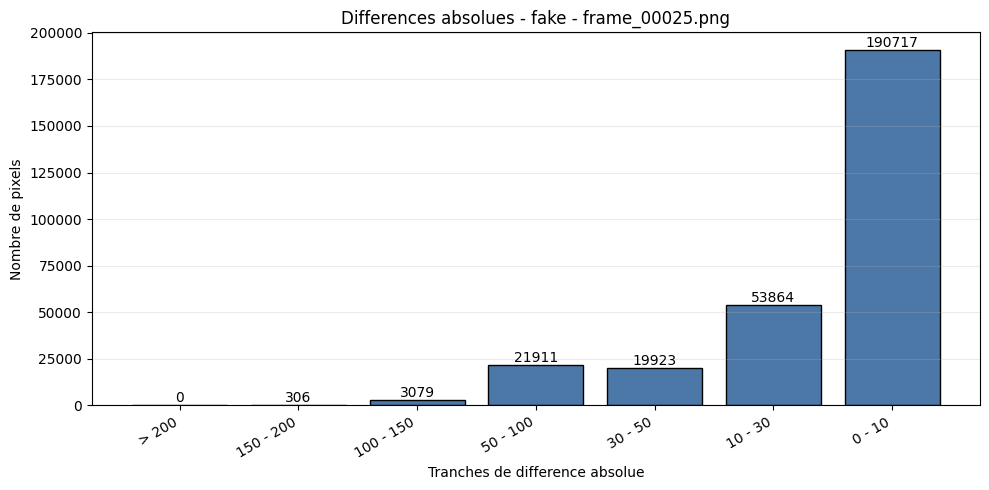

lvl:  4  initial error:  1784.2988394584127
 error improvement too small, level converged! it:  3  error:  727.5292705725182  lambda:  0.0
lvl:  3  initial error:  734.4917550943225
 error improvement too small, level converged! it:  4  error:  669.5698768197508  lambda:  0.0
lvl:  2  initial error:  710.2188092856495
 error improvement too small, level converged! it:  4  error:  688.939813160859  lambda:  0.0
[fake] frame 26 -> frame_00026.png | sum error = 216337616.00 | mean abs error = 15.2062 | valid pixels = 288981


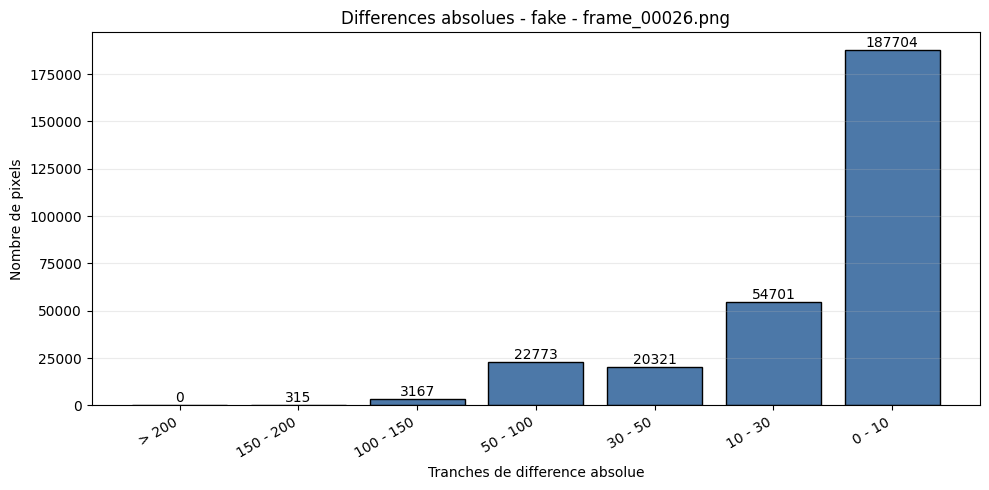

lvl:  4  initial error:  1840.6324951644087
update too small, level converged! it:  3  error:  732.2634769371703  lambda:  450359962737049.6
lvl:  3  initial error:  740.4098498014001
 error improvement too small, level converged! it:  3  error:  699.0414739857691  lambda:  25.6
lvl:  2  initial error:  732.5336534566857
 error improvement too small, level converged! it:  6  error:  707.326197049801  lambda:  0.4
[fake] frame 27 -> frame_00027.png | sum error = 223881424.00 | mean abs error = 15.6240 | valid pixels = 288070


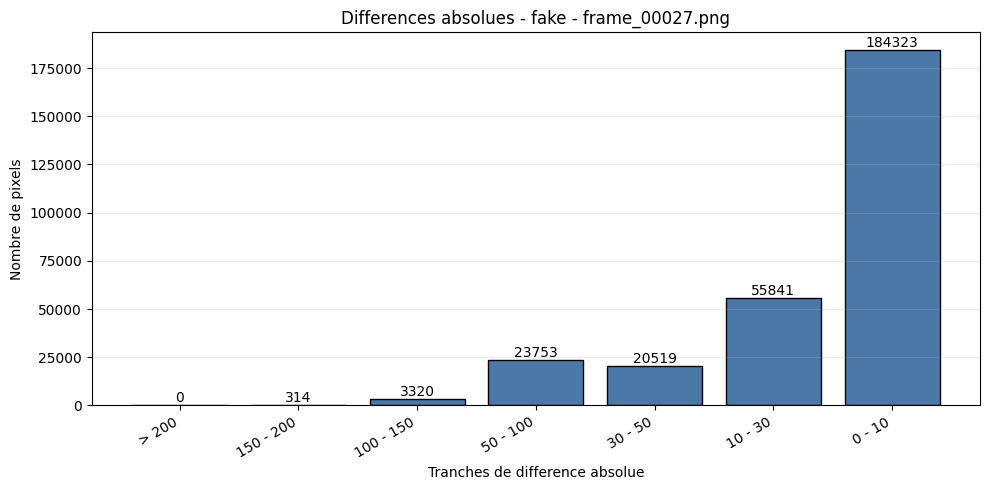

lvl:  4  initial error:  1875.7224371373295
update too small, level converged! it:  3  error:  703.4144424780546  lambda:  450359962737049.6
lvl:  3  initial error:  758.6266997181511
 error improvement too small, level converged! it:  3  error:  710.8265685201007  lambda:  1.6
lvl:  2  initial error:  750.909424089882
 error improvement too small, level converged! it:  2  error:  743.5251304229065  lambda:  0.0
[fake] frame 28 -> frame_00028.png | sum error = 232896816.00 | mean abs error = 16.2319 | valid pixels = 287063


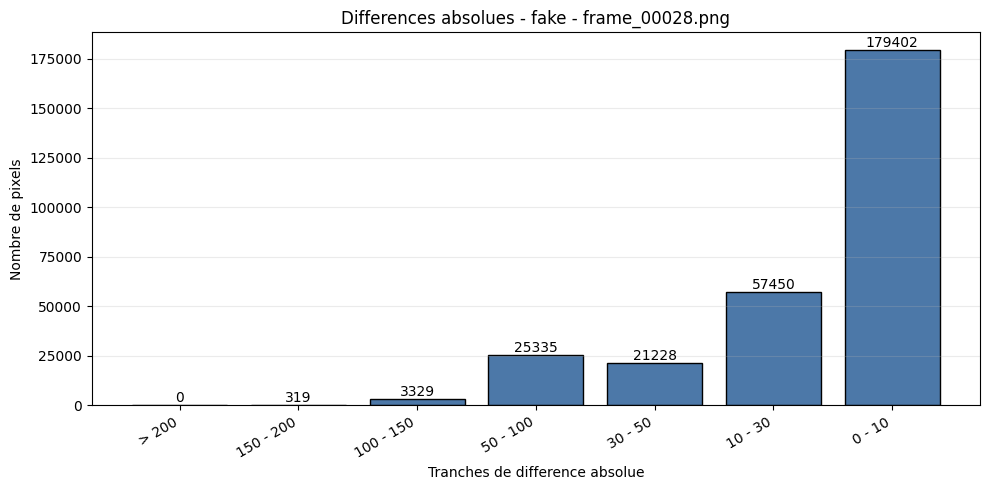

lvl:  4  initial error:  1867.6856866537705
 error improvement too small, level converged! it:  3  error:  676.9944348252644  lambda:  1759218604441.6
lvl:  3  initial error:  787.6041241313325
 error improvement too small, level converged! it:  4  error:  741.8722338597025  lambda:  0.8
lvl:  2  initial error:  778.8142590420764
 error improvement too small, level converged! it:  2  error:  766.1116058139286  lambda:  6.4
[fake] frame 29 -> frame_00029.png | sum error = 240845488.00 | mean abs error = 16.6597 | valid pixels = 286260


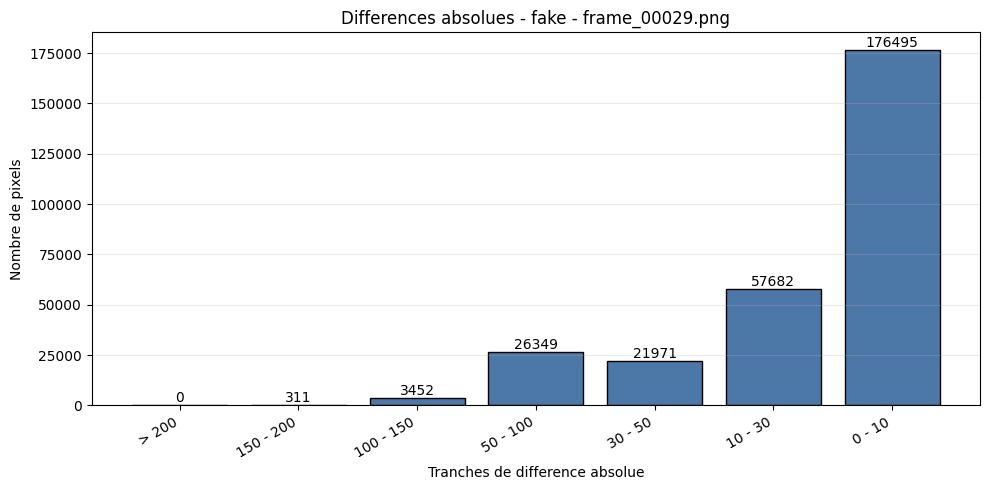

lvl:  4  initial error:  1855.9284332688576
 error improvement too small, level converged! it:  3  error:  670.3336928335469  lambda:  1.6
lvl:  3  initial error:  807.84314486959
 error improvement too small, level converged! it:  3  error:  769.8316220410132  lambda:  0.0
lvl:  2  initial error:  813.866182316972
 error improvement too small, level converged! it:  3  error:  804.565654028802  lambda:  0.0
[fake] frame 30 -> frame_00030.png | sum error = 247728592.00 | mean abs error = 17.0010 | valid pixels = 285447


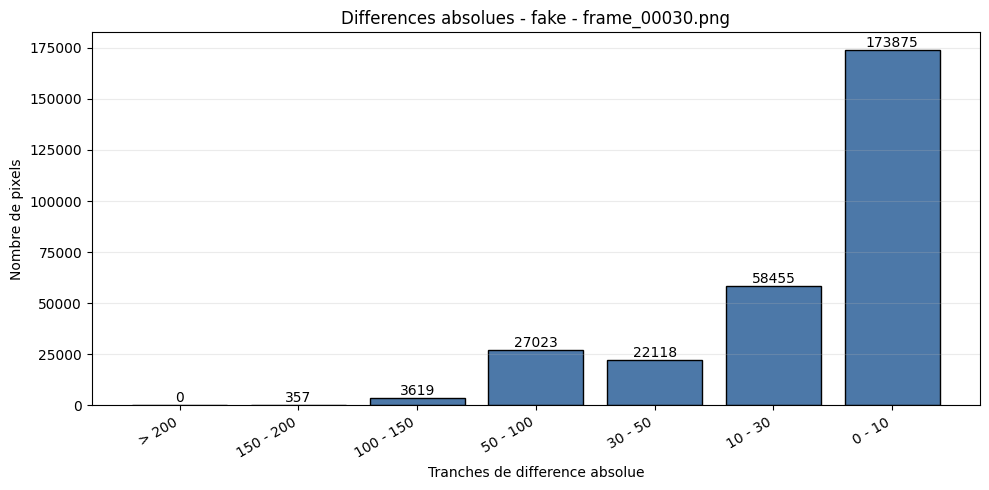

lvl:  4  initial error:  1904.2398452611203
 error improvement too small, level converged! it:  3  error:  699.9170884401299  lambda:  1.6
lvl:  3  initial error:  836.5601087515645
 error improvement too small, level converged! it:  6  error:  776.4302219525657  lambda:  0.2
lvl:  2  initial error:  839.20418428007
update too small, level converged! it:  2  error:  833.6670819010035  lambda:  28147497671065.6
[fake] frame 31 -> frame_00031.png | sum error = 258169744.00 | mean abs error = 17.5102 | valid pixels = 285239


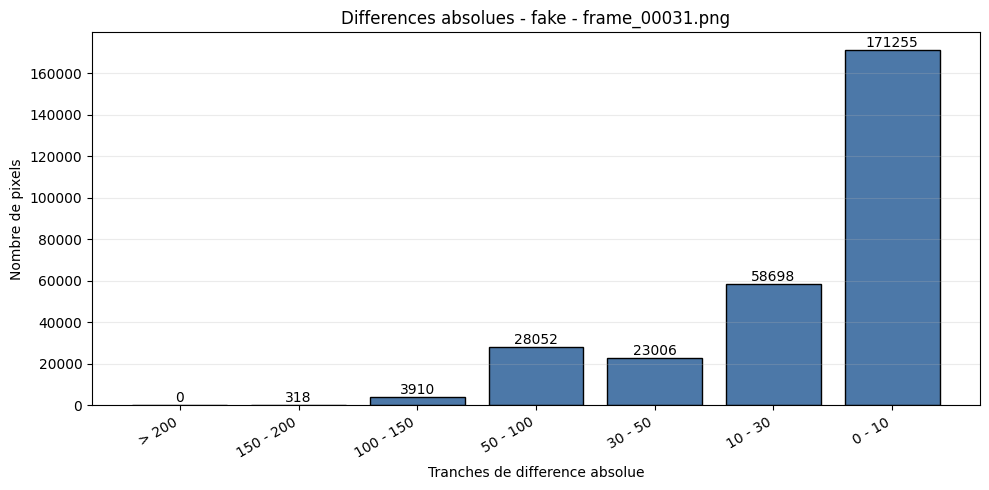

lvl:  4  initial error:  1939.3907156673101
 error improvement too small, level converged! it:  3  error:  745.5340657847113  lambda:  14073748835532.8
lvl:  3  initial error:  847.1814854705265
 error improvement too small, level converged! it:  7  error:  790.947154993846  lambda:  0.0
lvl:  2  initial error:  864.8744167335973
update too small, level converged! it:  2  error:  860.8712895148647  lambda:  28147497671065.6
[fake] frame 32 -> frame_00032.png | sum error = 266483232.00 | mean abs error = 17.8886 | valid pixels = 284860


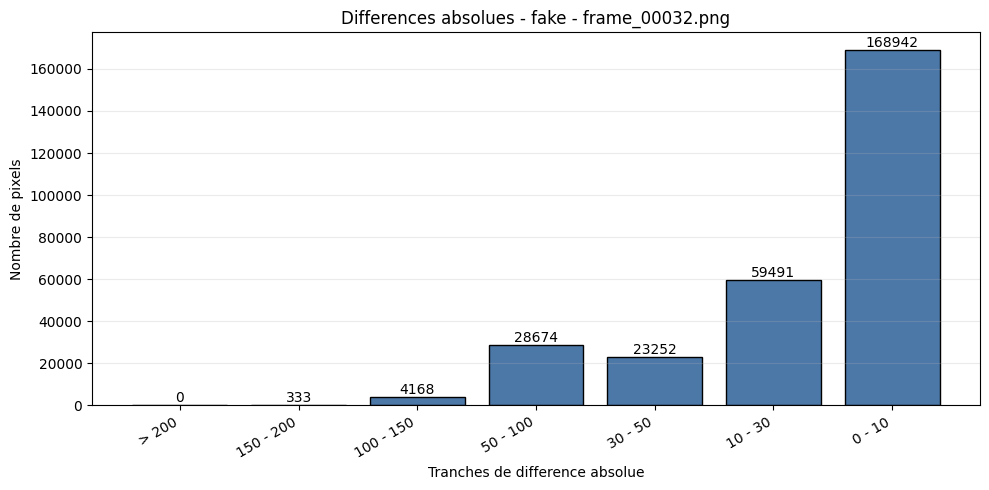

lvl:  4  initial error:  2005.3355899419719
 error improvement too small, level converged! it:  4  error:  763.395050329753  lambda:  0.1
lvl:  3  initial error:  866.5146330467027
 error improvement too small, level converged! it:  8  error:  813.5140666072153  lambda:  0.0
lvl:  2  initial error:  893.5942805922807
 error improvement too small, level converged! it:  2  error:  885.7308756567064  lambda:  3518437208883.2
[fake] frame 33 -> frame_00033.png | sum error = 273042304.00 | mean abs error = 18.2161 | valid pixels = 284131


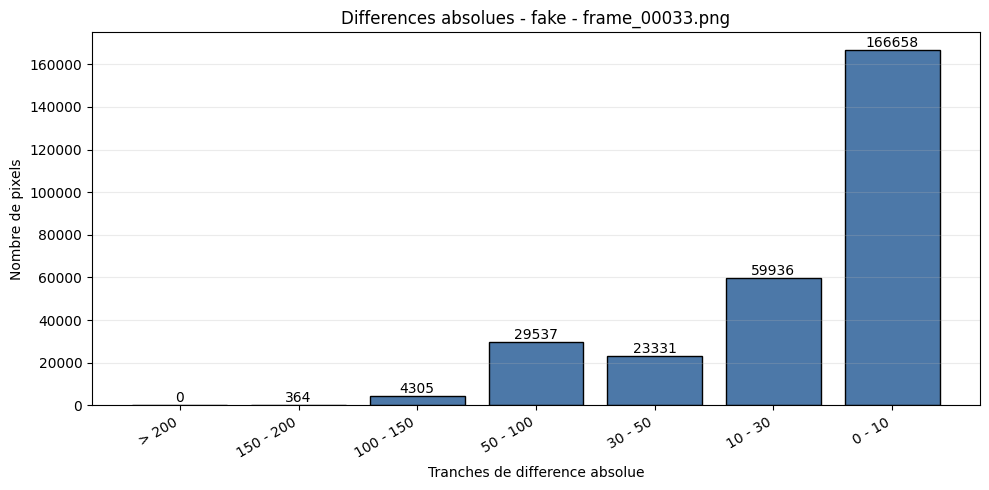

lvl:  4  initial error:  2085.4661508704053
 error improvement too small, level converged! it:  6  error:  805.6444822160373  lambda:  0.1
lvl:  3  initial error:  911.5902283461909
 error improvement too small, level converged! it:  2  error:  873.2463447877735  lambda:  3.2
lvl:  2  initial error:  922.9137681020294
 error improvement too small, level converged! it:  3  error:  916.9658014534082  lambda:  0.1
[fake] frame 34 -> frame_00034.png | sum error = 280692032.00 | mean abs error = 18.8023 | valid pixels = 282688


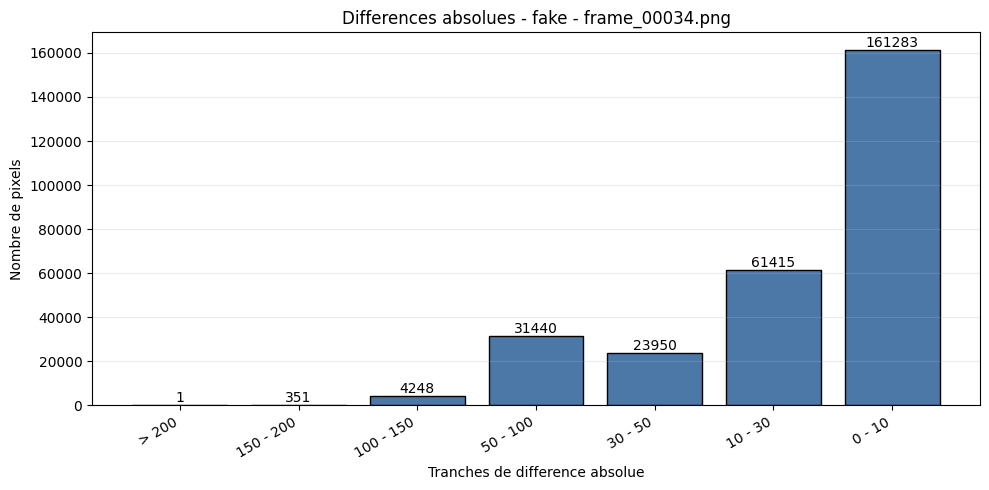

lvl:  4  initial error:  2100.883945841392
 error improvement too small, level converged! it:  4  error:  844.7466970119914  lambda:  14073748835532.8
lvl:  3  initial error:  909.971979454469
update too small, level converged! it:  2  error:  875.3059726303626  lambda:  450359962737049.6
lvl:  2  initial error:  953.8129225490944
 error improvement too small, level converged! it:  1  error:  953.7007916445788  lambda:  6.4
[fake] frame 35 -> frame_00035.png | sum error = 293127744.00 | mean abs error = 19.5089 | valid pixels = 282096


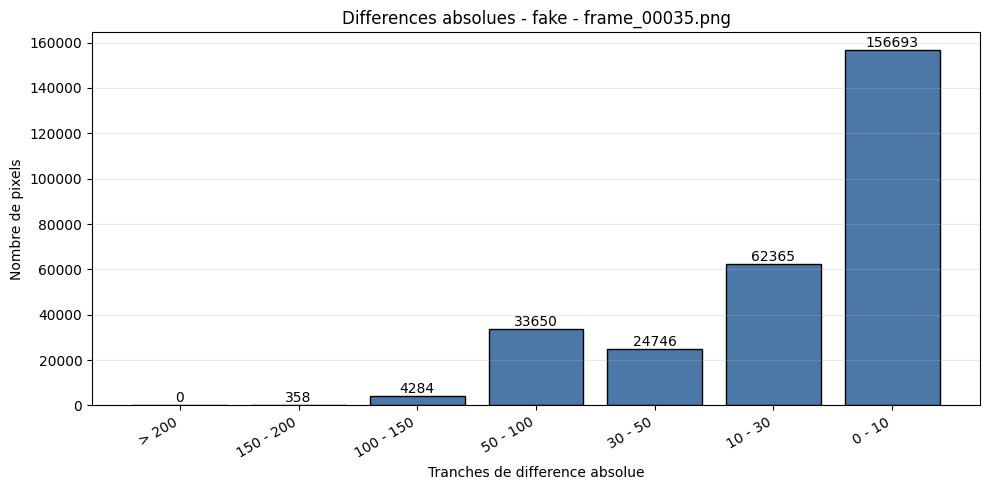

lvl:  4  initial error:  2169.8413926499024
 error improvement too small, level converged! it:  5  error:  861.0102310872458  lambda:  0.0
lvl:  3  initial error:  923.825452635654
 error improvement too small, level converged! it:  2  error:  883.1914334233265  lambda:  7036874417766.4
lvl:  2  initial error:  988.3464631180427
 error improvement too small, level converged! it:  1  error:  988.300120691327  lambda:  6.4
[fake] frame 36 -> frame_00036.png | sum error = 301214688.00 | mean abs error = 19.7486 | valid pixels = 281697


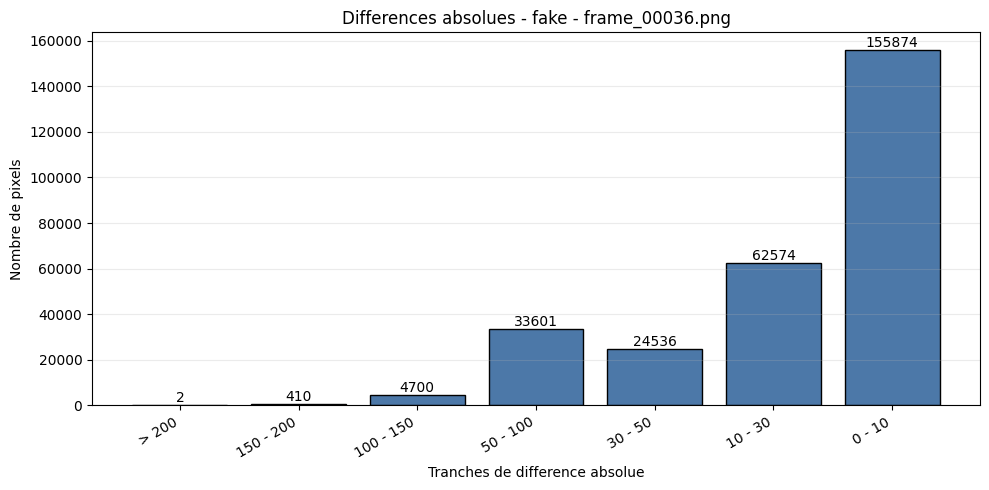

lvl:  4  initial error:  2194.218568665376
 error improvement too small, level converged! it:  6  error:  863.380562760363  lambda:  0.0
lvl:  3  initial error:  959.9694674241239
 error improvement too small, level converged! it:  2  error:  919.9837232740878  lambda:  0.8
lvl:  2  initial error:  1035.616625487431
 error improvement too small, level converged! it:  5  error:  1027.35201719621  lambda:  0.8
[fake] frame 37 -> frame_00037.png | sum error = 306739808.00 | mean abs error = 19.9460 | valid pixels = 280487


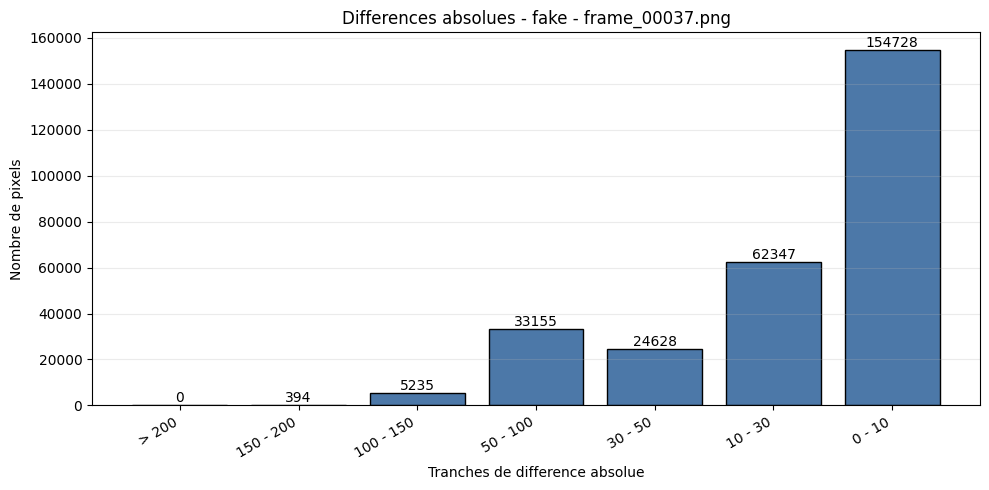

lvl:  4  initial error:  2239.9294003868463
update too small, level converged! it:  4  error:  988.5154902123434  lambda:  450359962737049.6
lvl:  3  initial error:  1041.7288766876839
 error improvement too small, level converged! it:  2  error:  1001.9140866361945  lambda:  0.0
lvl:  2  initial error:  1069.5845390719135
 error improvement too small, level converged! it:  1  error:  1069.5739022558685  lambda:  0.2
[fake] frame 38 -> frame_00038.png | sum error = 320172800.00 | mean abs error = 20.7595 | valid pixels = 279806


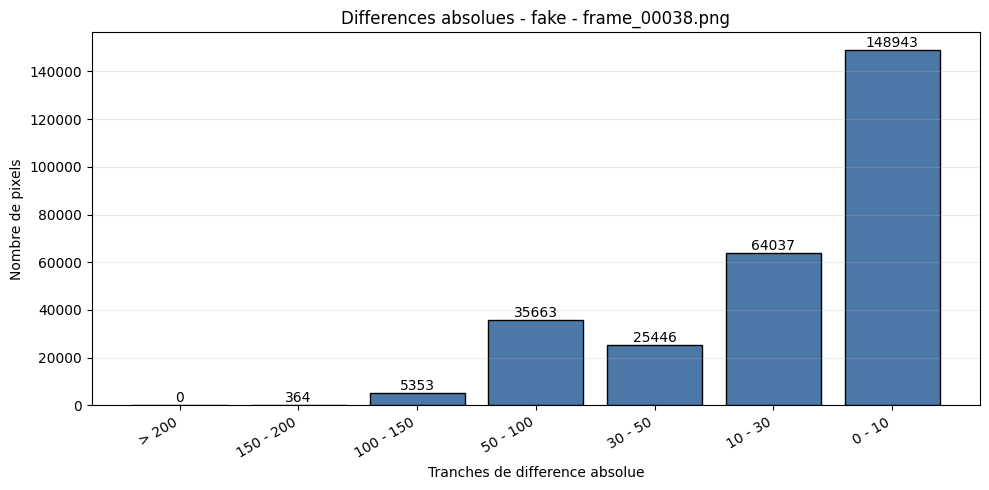

lvl:  4  initial error:  2293.2359767891676
update too small, level converged! it:  3  error:  1015.2654977221969  lambda:  112589990684262.4
lvl:  3  initial error:  1076.8786467653679
 error improvement too small, level converged! it:  5  error:  1031.2093456632008  lambda:  1759218604441.6
lvl:  2  initial error:  1099.002952557863
 error improvement too small, level converged! it:  2  error:  1096.8803741868064  lambda:  439804651110.4
[fake] frame 39 -> frame_00039.png | sum error = 329653408.00 | mean abs error = 21.2008 | valid pixels = 278747


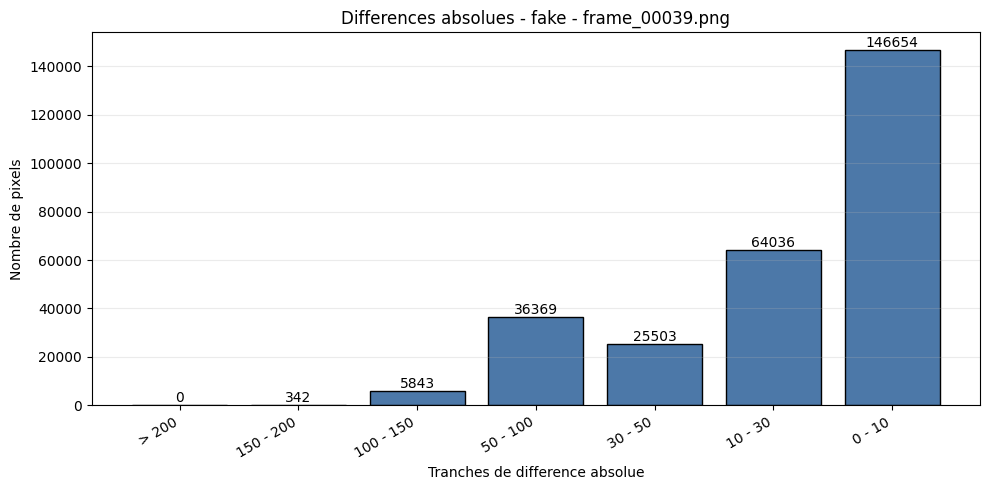

lvl:  4  initial error:  2311.9961315280457
 error improvement too small, level converged! it:  3  error:  1015.5680547470387  lambda:  0.8
lvl:  3  initial error:  1098.7257472542215
 error improvement too small, level converged! it:  6  error:  1056.4225066300014  lambda:  0.0
lvl:  2  initial error:  1148.1714525412385
 error improvement too small, level converged! it:  1  error:  1147.2591630533004  lambda:  0.1
[fake] frame 40 -> frame_00040.png | sum error = 339606144.00 | mean abs error = 21.5759 | valid pixels = 278266


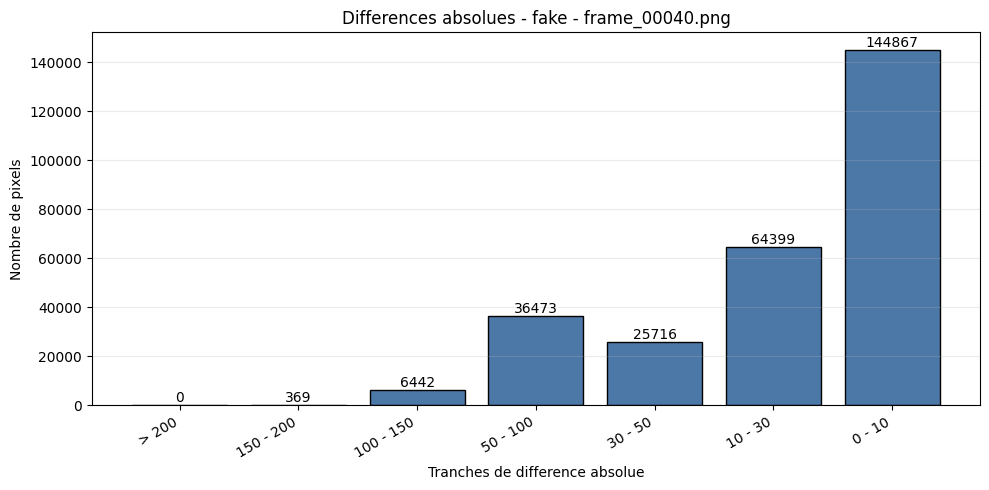

lvl:  4  initial error:  2356.4738878143125
 error improvement too small, level converged! it:  4  error:  1077.1910320002544  lambda:  0.1
lvl:  3  initial error:  1124.230328137235
 error improvement too small, level converged! it:  2  error:  1098.9622931229405  lambda:  0.0
lvl:  2  initial error:  1173.844846940699
 error improvement too small, level converged! it:  1  error:  1173.7169635785071  lambda:  0.8
[fake] frame 41 -> frame_00041.png | sum error = 353683552.00 | mean abs error = 22.2925 | valid pixels = 277847


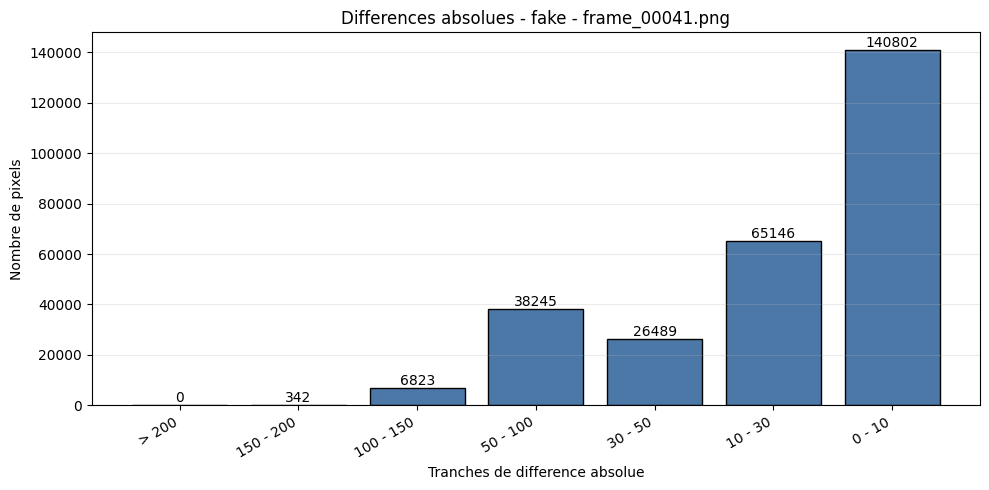

lvl:  4  initial error:  2373.8607350096704
 error improvement too small, level converged! it:  5  error:  1123.1765274756021  lambda:  0.1
lvl:  3  initial error:  1178.2601446941958
 error improvement too small, level converged! it:  2  error:  1160.061406257554  lambda:  0.0
lvl:  2  initial error:  1216.4686277470878
 error improvement too small, level converged! it:  1  error:  1216.386009960124  lambda:  3.2
[fake] frame 42 -> frame_00042.png | sum error = 365271616.00 | mean abs error = 22.8548 | valid pixels = 276729


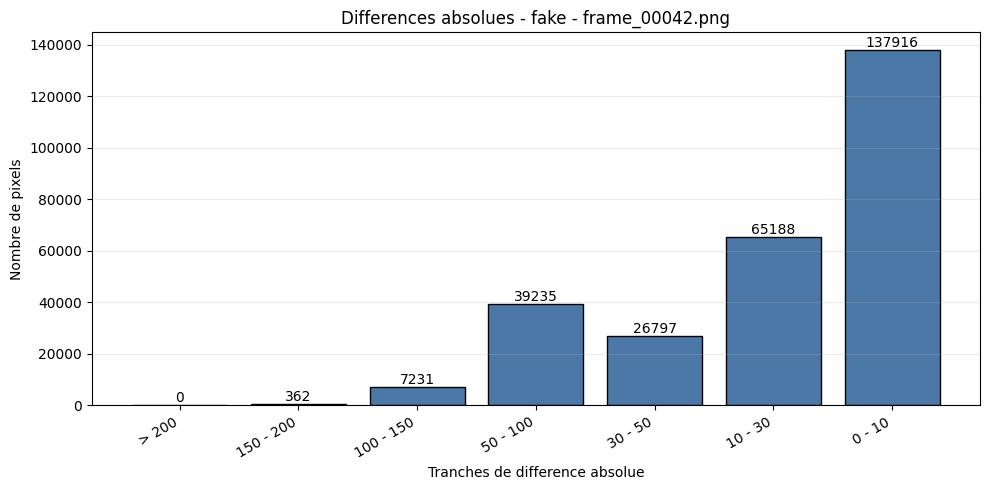

lvl:  4  initial error:  2489.943907156672
 error improvement too small, level converged! it:  5  error:  1220.9989478222378  lambda:  0.0
lvl:  3  initial error:  1201.2659387124704
 error improvement too small, level converged! it:  3  error:  1188.1704316373323  lambda:  0.0
lvl:  2  initial error:  1271.1235898076966
 error improvement too small, level converged! it:  1  error:  1271.0347842326898  lambda:  0.2
[fake] frame 43 -> frame_00043.png | sum error = 373826016.00 | mean abs error = 23.1658 | valid pixels = 275732


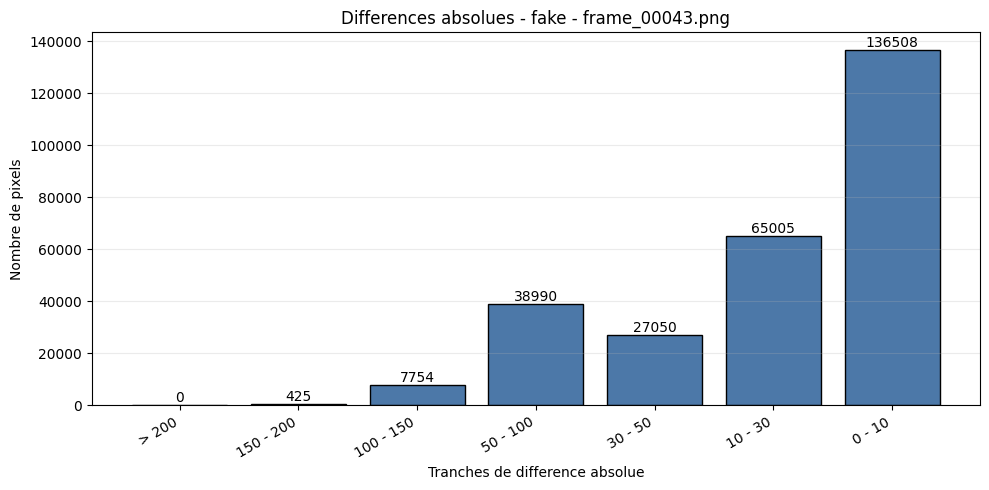

lvl:  4  initial error:  2529.7514506769817
 error improvement too small, level converged! it:  7  error:  1285.7292418950942  lambda:  0.0
lvl:  3  initial error:  1275.8112669759728
 error improvement too small, level converged! it:  4  error:  1244.7457823047816  lambda:  0.0
lvl:  2  initial error:  1312.6632487951847
 error improvement too small, level converged! it:  2  error:  1309.44398029898  lambda:  0.0
[fake] frame 44 -> frame_00044.png | sum error = 384625024.00 | mean abs error = 23.6381 | valid pixels = 274866


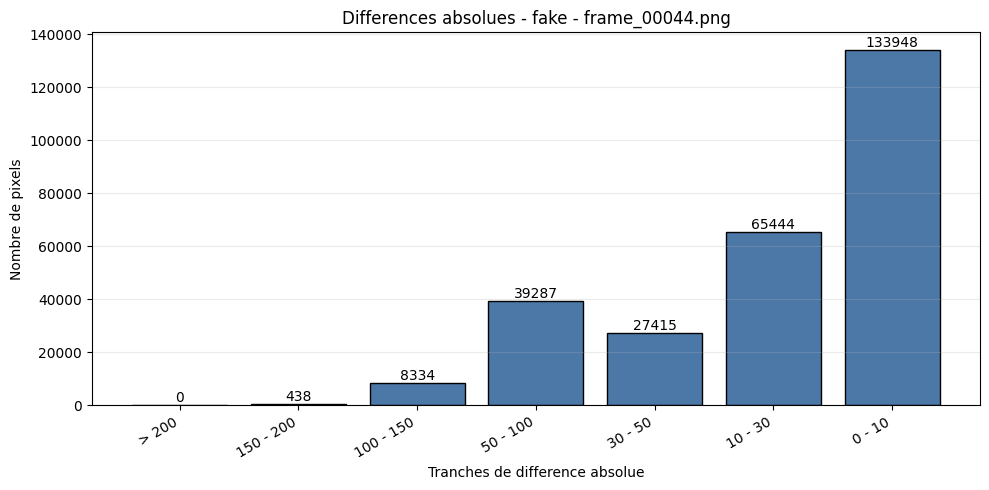

lvl:  4  initial error:  2588.7833655705986
 error improvement too small, level converged! it:  9  error:  1326.727717345424  lambda:  0.0
lvl:  3  initial error:  1299.349085007499
 error improvement too small, level converged! it:  5  error:  1250.3035792476721  lambda:  13743895347.2
lvl:  2  initial error:  1351.324419245338
 error improvement too small, level converged! it:  1  error:  1350.7565911082945  lambda:  0.0
[fake] frame 45 -> frame_00045.png | sum error = 395471328.00 | mean abs error = 24.0970 | valid pixels = 274485


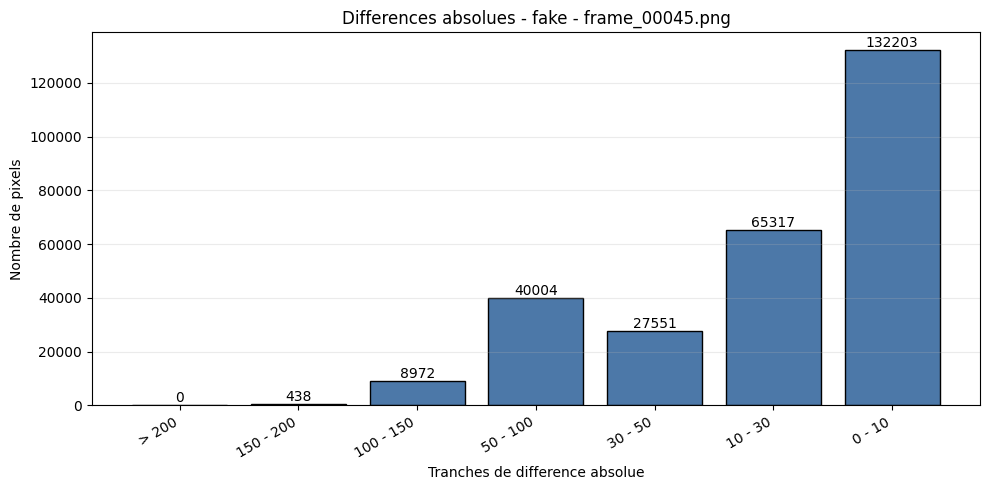

lvl:  4  initial error:  2649.8955512572525
 error improvement too small, level converged! it:  9  error:  1344.9883735740132  lambda:  1.6
lvl:  3  initial error:  1371.4700378223872
 error improvement too small, level converged! it:  2  error:  1320.6397766042658  lambda:  0.0
lvl:  2  initial error:  1404.3463398504414
 error improvement too small, level converged! it:  1  error:  1403.8715745960724  lambda:  0.4
[fake] frame 46 -> frame_00046.png | sum error = 409195104.00 | mean abs error = 24.7340 | valid pixels = 273988


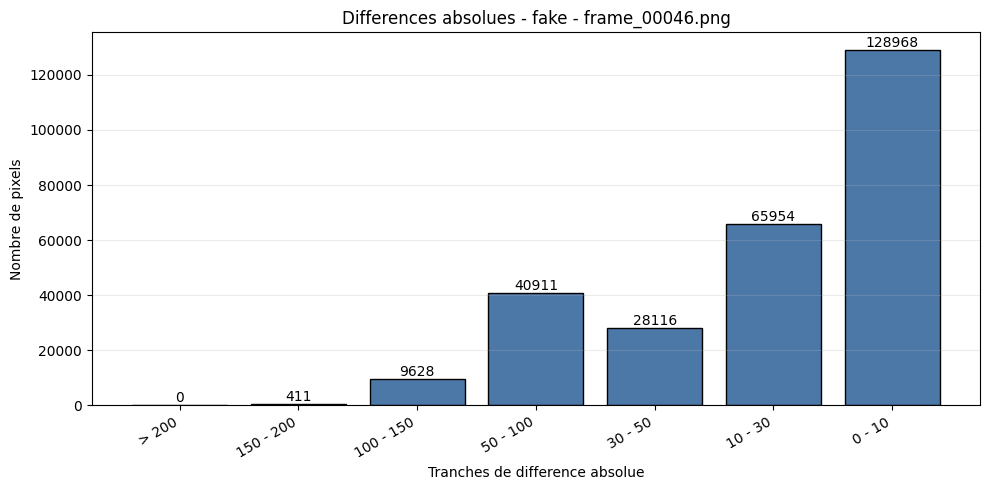

lvl:  4  initial error:  2743.48742746615
 error improvement too small, level converged! it:  4  error:  1435.9300932553356  lambda:  0.0
lvl:  3  initial error:  1379.1961640546187
 error improvement too small, level converged! it:  4  error:  1351.5861268762687  lambda:  0.0
lvl:  2  initial error:  1452.7240585043949
 error improvement too small, level converged! it:  1  error:  1452.6659112377583  lambda:  0.8
[fake] frame 47 -> frame_00047.png | sum error = 420172000.00 | mean abs error = 25.3736 | valid pixels = 272551


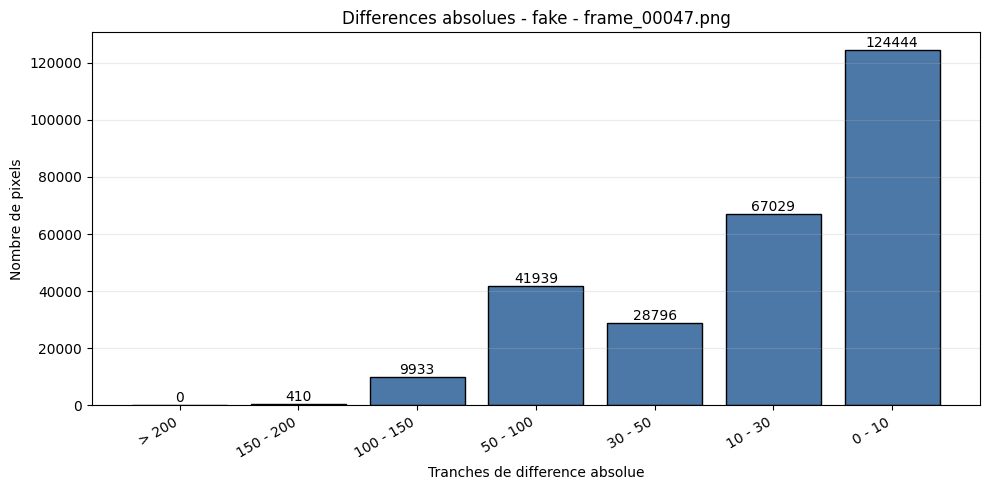

lvl:  4  initial error:  2803.1218568665367
 error improvement too small, level converged! it:  3  error:  1461.536221112889  lambda:  25.6
lvl:  3  initial error:  1406.7823384944495
update too small, level converged! it:  2  error:  1392.3427654649015  lambda:  112589990684262.4
lvl:  2  initial error:  1500.00734919773
 error improvement too small, level converged! it:  1  error:  1499.7990992350685  lambda:  0.8
[fake] frame 48 -> frame_00048.png | sum error = 432939488.00 | mean abs error = 25.9764 | valid pixels = 271960


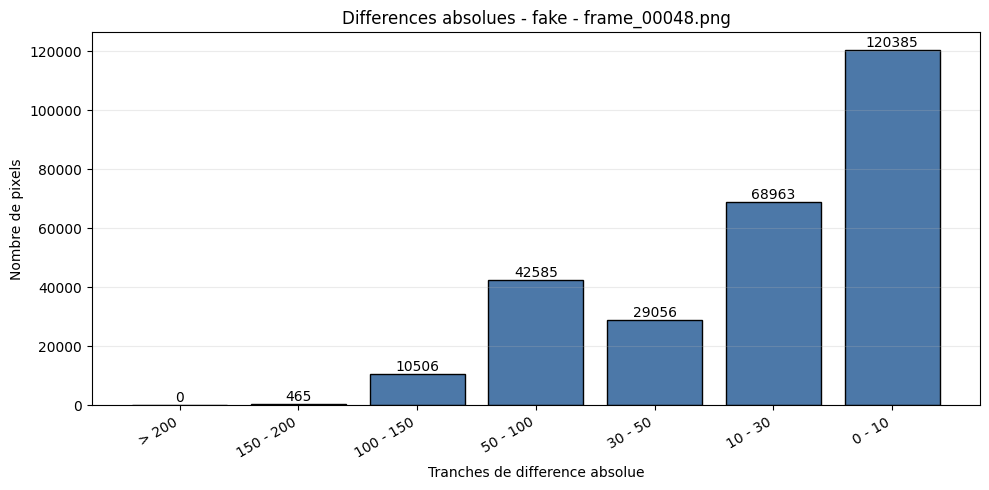

lvl:  4  initial error:  2812.7707930367496
 error improvement too small, level converged! it:  4  error:  1430.9706159836244  lambda:  0.1
lvl:  3  initial error:  1450.618459498357
 error improvement too small, level converged! it:  7  error:  1404.7070708013282  lambda:  0.0
lvl:  2  initial error:  1542.475391593745
 error improvement too small, level converged! it:  5  error:  1532.2328021920655  lambda:  0.0
[fake] frame 49 -> frame_00049.png | sum error = 439279808.00 | mean abs error = 26.2560 | valid pixels = 270868


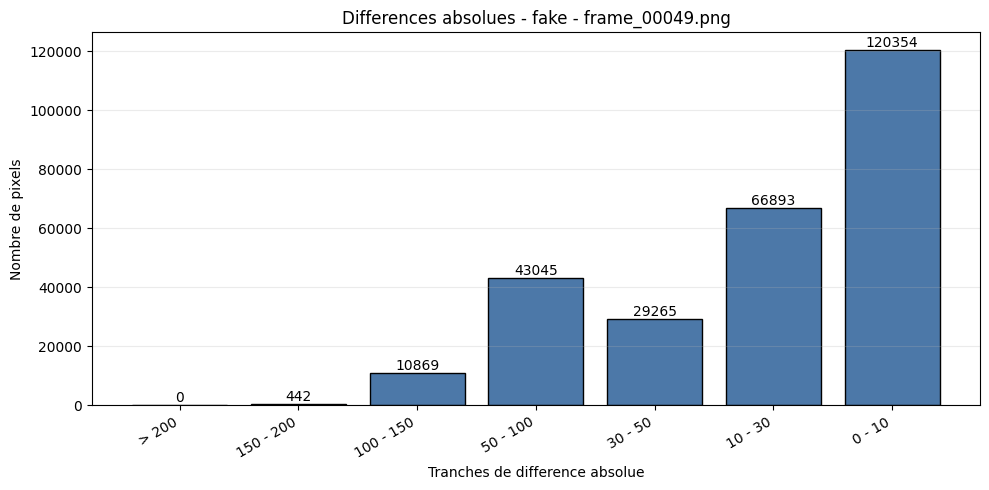

lvl:  4  initial error:  2872.570599613152
 error improvement too small, level converged! it:  5  error:  1442.8487572181134  lambda:  6.4
lvl:  3  initial error:  1464.2714553845046
 error improvement too small, level converged! it:  5  error:  1418.4910688064438  lambda:  0.1
lvl:  2  initial error:  1570.5244623527547
 error improvement too small, level converged! it:  1  error:  1569.3680074654449  lambda:  0.0
[fake] frame 50 -> frame_00050.png | sum error = 449344608.00 | mean abs error = 26.7076 | valid pixels = 270746


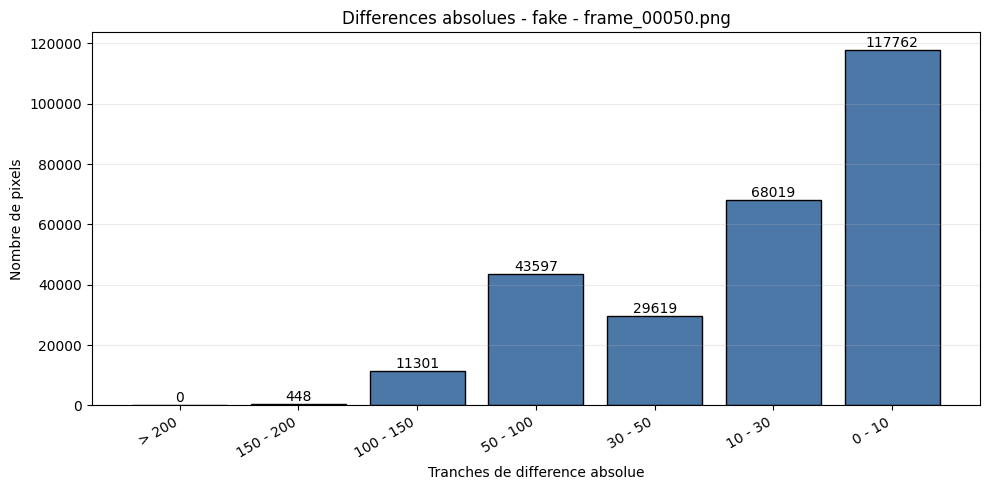

lvl:  4  initial error:  3039.8123791102503
 error improvement too small, level converged! it:  6  error:  1488.362300783939  lambda:  0.1
lvl:  3  initial error:  1536.9874771138202
 error improvement too small, level converged! it:  7  error:  1502.8937716606254  lambda:  0.0
lvl:  2  initial error:  1596.3336037845256
 error improvement too small, level converged! it:  1  error:  1596.1208928326305  lambda:  0.8
[fake] frame 51 -> frame_00051.png | sum error = 456616128.00 | mean abs error = 27.2437 | valid pixels = 269499


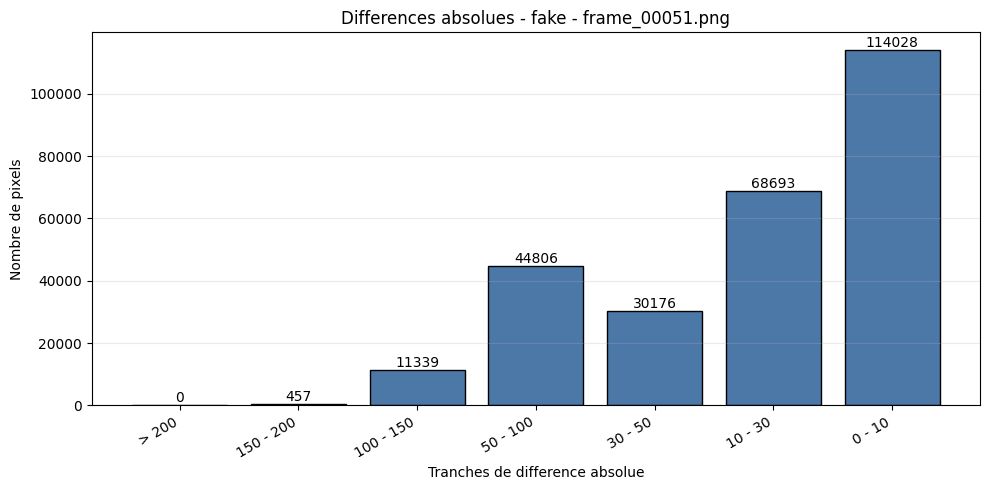

lvl:  4  initial error:  3060.4381044487413
 error improvement too small, level converged! it:  4  error:  1569.2139561291128  lambda:  0.4
lvl:  3  initial error:  1556.7799336839223
 error improvement too small, level converged! it:  2  error:  1522.7448335614076  lambda:  3.2
lvl:  2  initial error:  1666.573757893915
 error improvement too small, level converged! it:  3  error:  1654.249995326361  lambda:  0.0
[fake] frame 52 -> frame_00052.png | sum error = 466220064.00 | mean abs error = 27.8829 | valid pixels = 268280


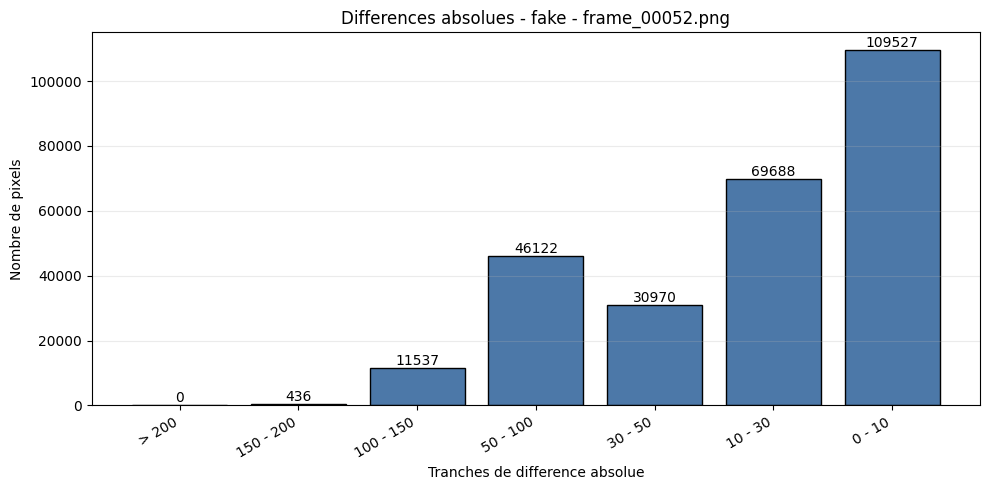

lvl:  4  initial error:  3057.253384912958
 error improvement too small, level converged! it:  6  error:  1603.0764681121564  lambda:  1.6
lvl:  3  initial error:  1605.9407954739265
 error improvement too small, level converged! it:  6  error:  1544.127271337186  lambda:  0.0
lvl:  2  initial error:  1685.4060638250714
 error improvement too small, level converged! it:  4  error:  1676.6487202887079  lambda:  0.0
[fake] frame 53 -> frame_00053.png | sum error = 472108992.00 | mean abs error = 28.3406 | valid pixels = 266928


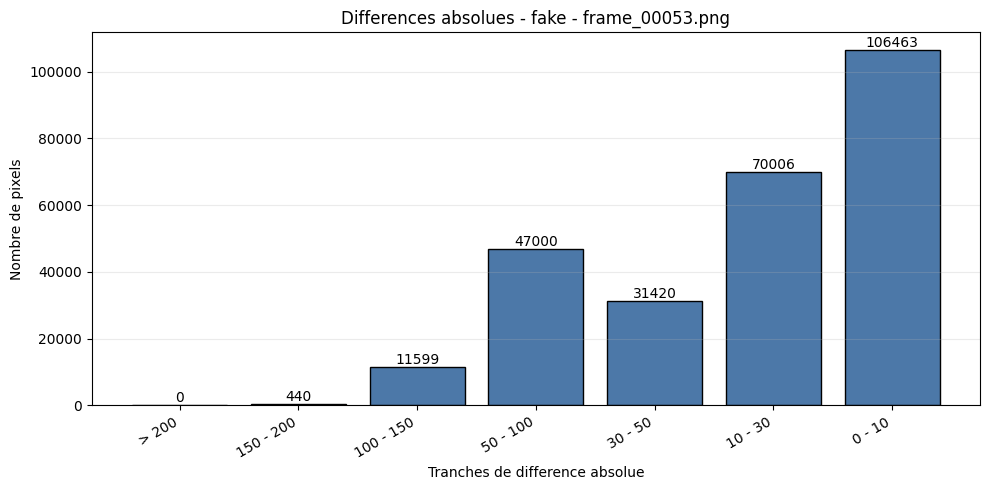

lvl:  4  initial error:  3125.4593810444867
 error improvement too small, level converged! it:  5  error:  1638.1793197351187  lambda:  0.2
lvl:  3  initial error:  1606.214609591352
 error improvement too small, level converged! it:  2  error:  1588.1012515147681  lambda:  0.0
lvl:  2  initial error:  1748.0180559182713
 error improvement too small, level converged! it:  2  error:  1738.5931520214801  lambda:  0.0
[fake] frame 54 -> frame_00054.png | sum error = 486788672.00 | mean abs error = 29.0214 | valid pixels = 266358


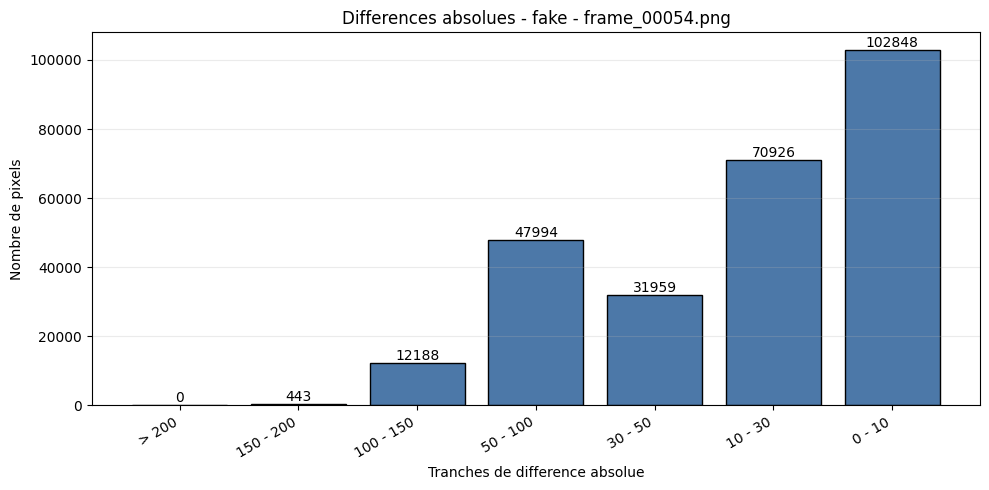

lvl:  4  initial error:  3156.5377176015463
update too small, level converged! it:  5  error:  1647.463323191168  lambda:  450359962737049.6
lvl:  3  initial error:  1654.2853966676507
 error improvement too small, level converged! it:  2  error:  1652.0562202997382  lambda:  0.2
lvl:  2  initial error:  1771.9768246780518
 error improvement too small, level converged! it:  3  error:  1762.0409092445504  lambda:  0.0
[fake] frame 55 -> frame_00055.png | sum error = 493644768.00 | mean abs error = 29.3889 | valid pixels = 265208


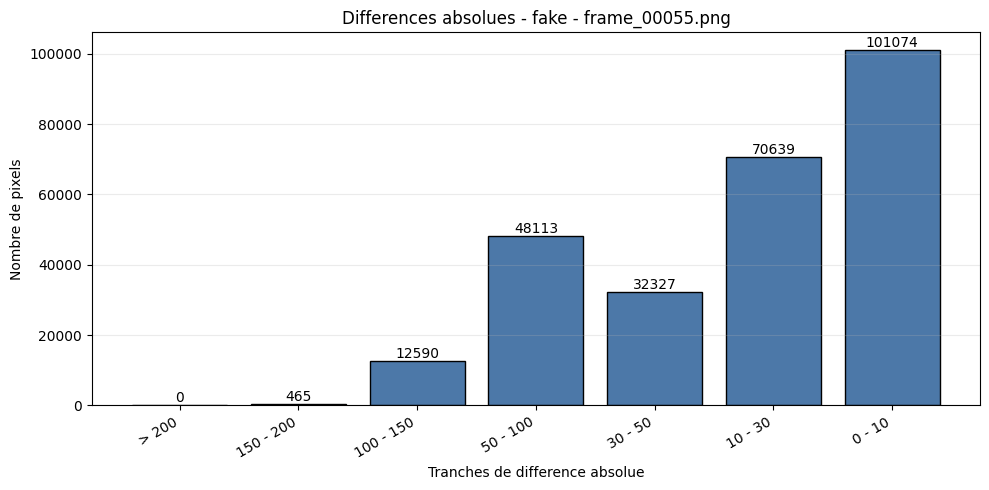

lvl:  4  initial error:  3218.766924564796
 error improvement too small, level converged! it:  5  error:  1715.4709346375928  lambda:  204.8
lvl:  3  initial error:  1699.5469401399955
 error improvement too small, level converged! it:  2  error:  1663.137974042937  lambda:  0.4
lvl:  2  initial error:  1829.0590730790195
 error improvement too small, level converged! it:  4  error:  1800.9286672772603  lambda:  0.0
[fake] frame 56 -> frame_00056.png | sum error = 501674560.00 | mean abs error = 29.8175 | valid pixels = 264362


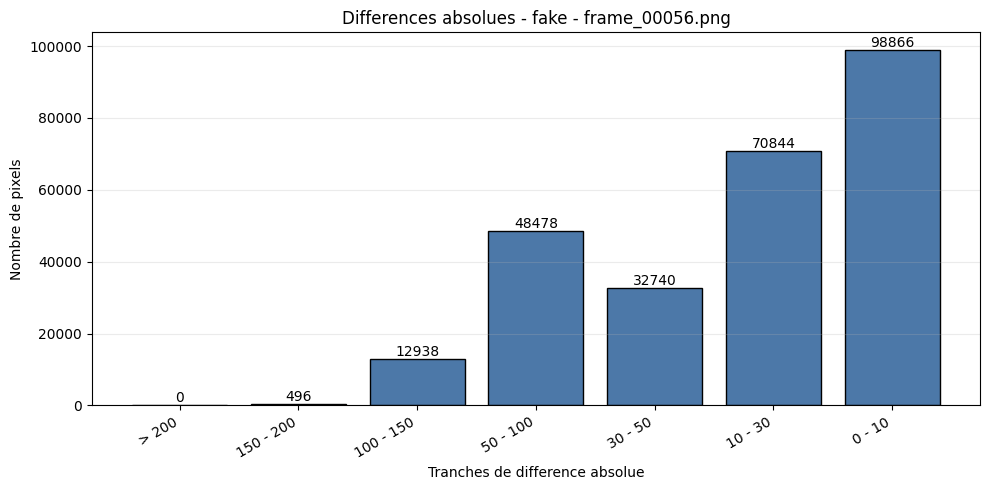

lvl:  4  initial error:  3435.719535783365
 error improvement too small, level converged! it:  4  error:  1782.6561717616974  lambda:  0.1
lvl:  3  initial error:  1703.458856454315
 error improvement too small, level converged! it:  2  error:  1683.4694619728675  lambda:  1759218604441.6
lvl:  2  initial error:  1873.3163546547198
 error improvement too small, level converged! it:  5  error:  1843.146453905113  lambda:  0.0
[fake] frame 57 -> frame_00057.png | sum error = 511285504.00 | mean abs error = 30.3102 | valid pixels = 263439


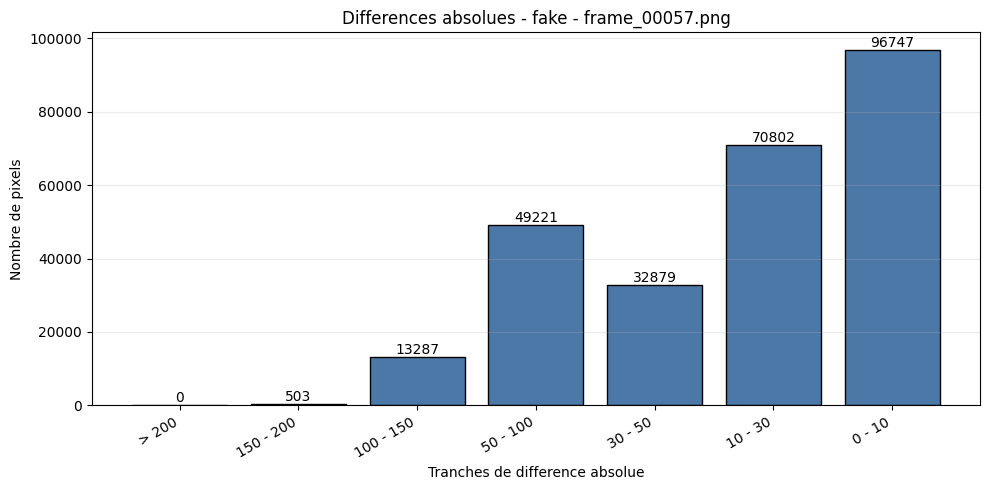

lvl:  4  initial error:  3401.538684719535
 error improvement too small, level converged! it:  8  error:  1756.8398867430808  lambda:  0.0
lvl:  3  initial error:  1784.785731064054
 error improvement too small, level converged! it:  2  error:  1775.2440516084105  lambda:  1.6
lvl:  2  initial error:  1919.9072115215217
 error improvement too small, level converged! it:  3  error:  1906.6651984038228  lambda:  0.0
[fake] frame 58 -> frame_00058.png | sum error = 525201312.00 | mean abs error = 30.8957 | valid pixels = 263360


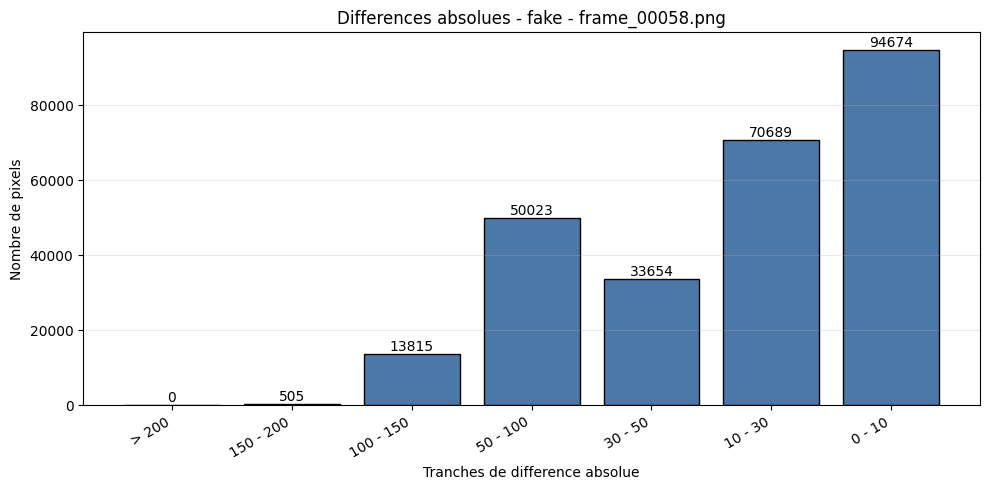

lvl:  4  initial error:  3460.1479690522233
 error improvement too small, level converged! it:  6  error:  1833.281885528441  lambda:  6.4
lvl:  3  initial error:  1825.6126077164188
 error improvement too small, level converged! it:  2  error:  1820.7811868060485  lambda:  0.0
lvl:  2  initial error:  1933.4414780238212
 error improvement too small, level converged! it:  2  error:  1928.7919970064215  lambda:  0.0
[fake] frame 59 -> frame_00059.png | sum error = 535459488.00 | mean abs error = 31.3485 | valid pixels = 263162


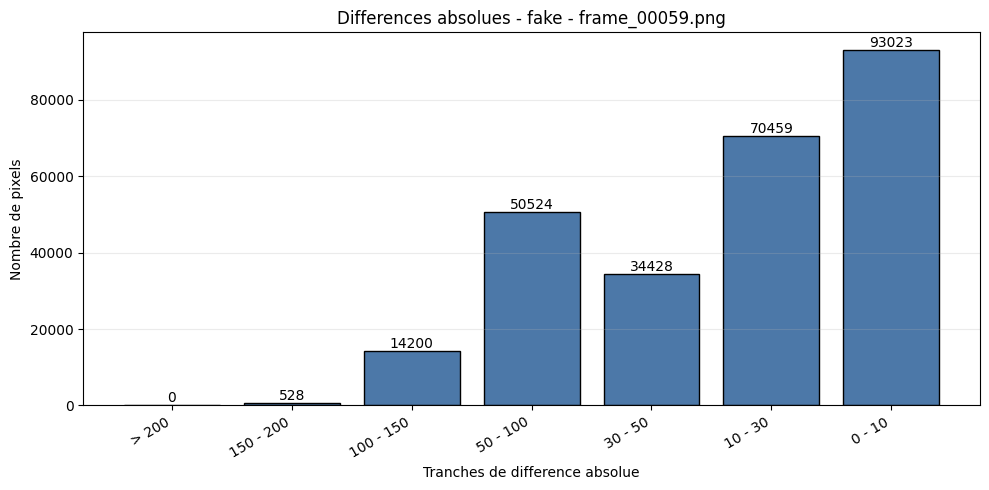

lvl:  4  initial error:  3526.9767891682777
 error improvement too small, level converged! it:  3  error:  1939.9243182289347  lambda:  0.0
lvl:  3  initial error:  1832.2611692597252
 error improvement too small, level converged! it:  2  error:  1819.515287823802  lambda:  0.0
lvl:  2  initial error:  1988.4109683994227
 error improvement too small, level converged! it:  2  error:  1985.2728235744944  lambda:  0.0
[fake] frame 60 -> frame_00060.png | sum error = 545828672.00 | mean abs error = 31.8962 | valid pixels = 262485


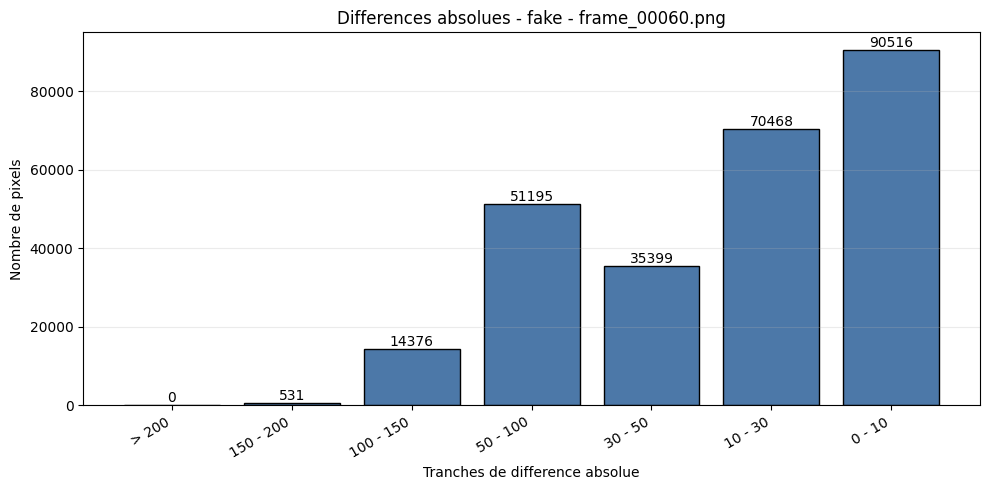

lvl:  4  initial error:  3539.456479690522
 error improvement too small, level converged! it:  5  error:  1874.03314159719  lambda:  12.8
lvl:  3  initial error:  1923.2280553608744
 error improvement too small, level converged! it:  3  error:  1882.6614307024543  lambda:  0.0
lvl:  2  initial error:  2025.0171002740128
 error improvement too small, level converged! it:  3  error:  2015.8916019499375  lambda:  0.0
[fake] frame 61 -> frame_00061.png | sum error = 553038464.00 | mean abs error = 32.3144 | valid pixels = 261948


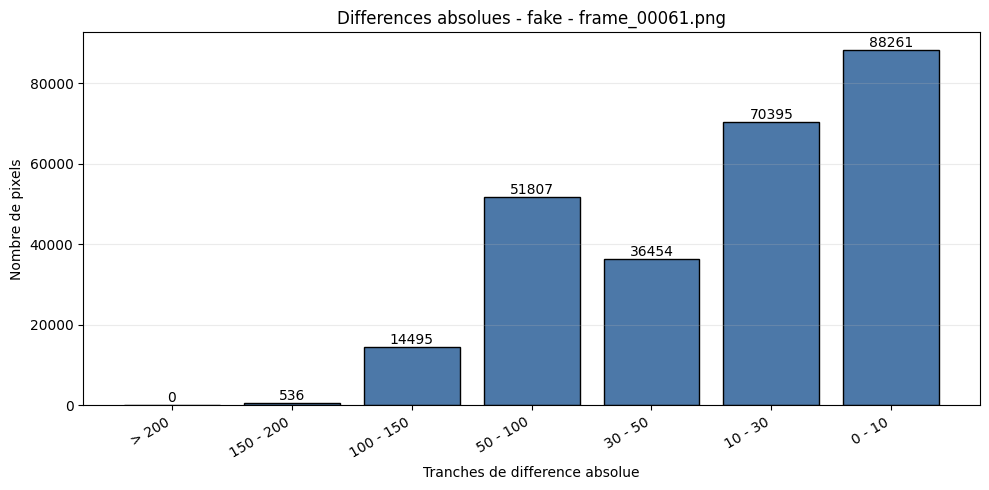

lvl:  4  initial error:  3642.460348162475
 error improvement too small, level converged! it:  4  error:  1945.7837538484935  lambda:  1759218604441.6
lvl:  3  initial error:  1937.0734031226634
 error improvement too small, level converged! it:  3  error:  1893.2377733098688  lambda:  0.0
lvl:  2  initial error:  2061.7538457852424
 error improvement too small, level converged! it:  2  error:  2058.326268537781  lambda:  0.0
[fake] frame 62 -> frame_00062.png | sum error = 562032960.00 | mean abs error = 32.7052 | valid pixels = 261410


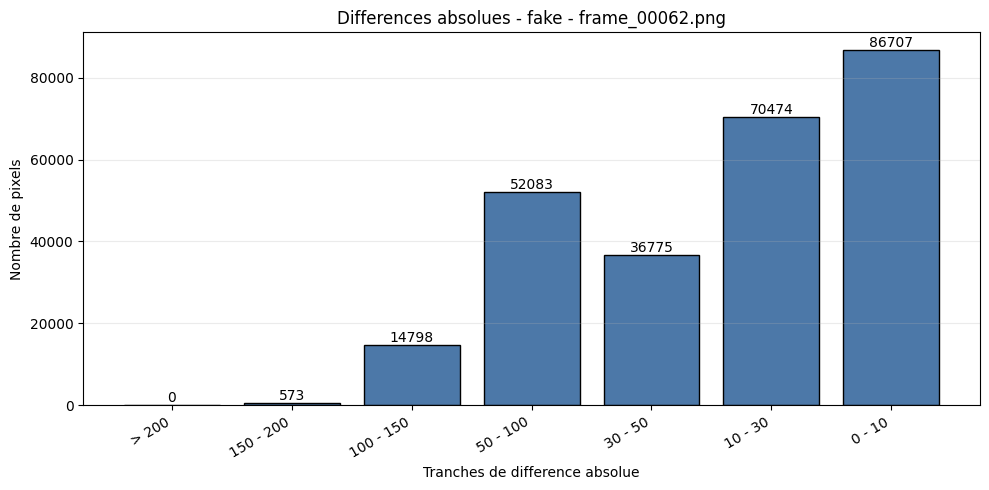

lvl:  4  initial error:  3674.6112185686643
 error improvement too small, level converged! it:  4  error:  1898.7861961575013  lambda:  1759218604441.6
lvl:  3  initial error:  2004.276858607705
 error improvement too small, level converged! it:  3  error:  1976.913147494723  lambda:  0.1
lvl:  2  initial error:  2107.256386011656
 error improvement too small, level converged! it:  5  error:  2094.46991379621  lambda:  0.0
[fake] frame 63 -> frame_00063.png | sum error = 571019840.00 | mean abs error = 33.1104 | valid pixels = 260492


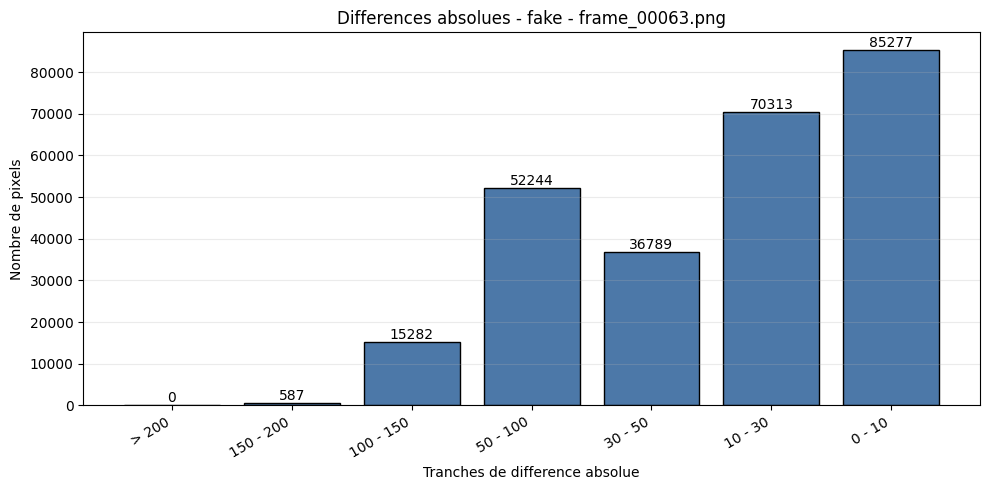

lvl:  4  initial error:  3801.313346228239
 error improvement too small, level converged! it:  6  error:  1927.472396725785  lambda:  439804651110.4
lvl:  3  initial error:  2016.6801247156761
 error improvement too small, level converged! it:  3  error:  1990.4081852600366  lambda:  0.0
lvl:  2  initial error:  2148.2465840905934
 error improvement too small, level converged! it:  5  error:  2123.728534382802  lambda:  0.0
[fake] frame 64 -> frame_00064.png | sum error = 579081856.00 | mean abs error = 33.5316 | valid pixels = 259357


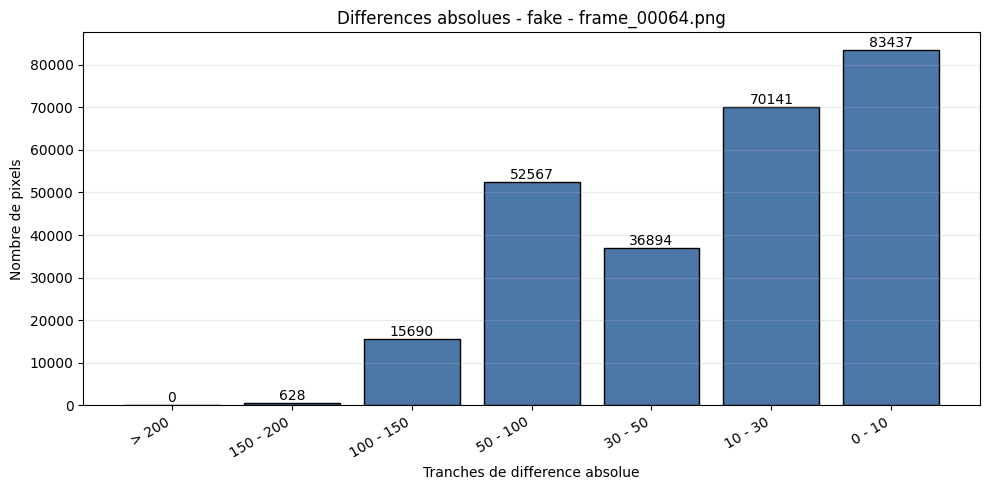

lvl:  4  initial error:  3896.5232108317205
 error improvement too small, level converged! it:  3  error:  1994.2626547063503  lambda:  439804651110.4
lvl:  3  initial error:  2029.902162667471
 error improvement too small, level converged! it:  3  error:  2003.8562539000654  lambda:  0.2
lvl:  2  initial error:  2211.666396039384
 error improvement too small, level converged! it:  3  error:  2197.689324223533  lambda:  0.0
[fake] frame 65 -> frame_00065.png | sum error = 589099840.00 | mean abs error = 33.9854 | valid pixels = 258403


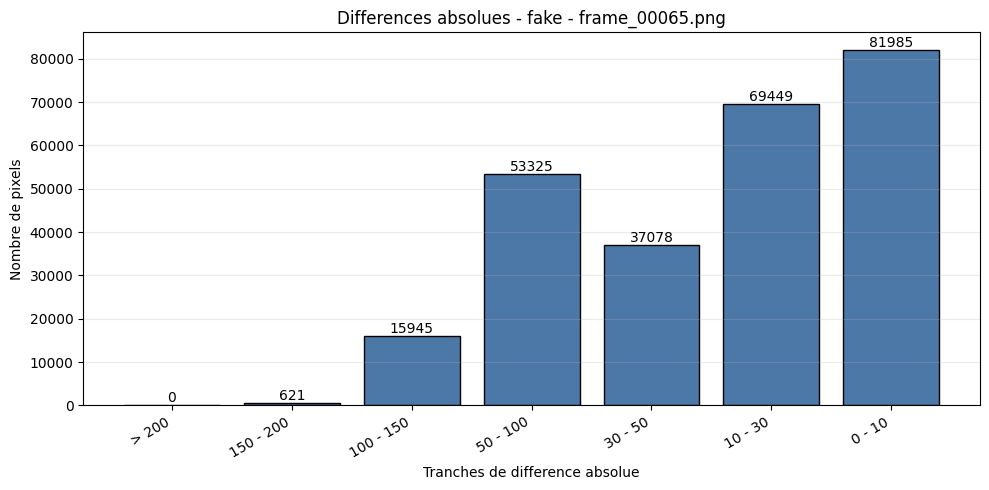

lvl:  4  initial error:  3991.9294003868463
 error improvement too small, level converged! it:  5  error:  2061.330746198518  lambda:  1.6
lvl:  3  initial error:  2110.75275509218
 error improvement too small, level converged! it:  2  error:  2100.1699623875325  lambda:  0.0
lvl:  2  initial error:  2270.774669947405
 error improvement too small, level converged! it:  5  error:  2245.080618053488  lambda:  0.0
[fake] frame 66 -> frame_00066.png | sum error = 598660608.00 | mean abs error = 34.6562 | valid pixels = 254705


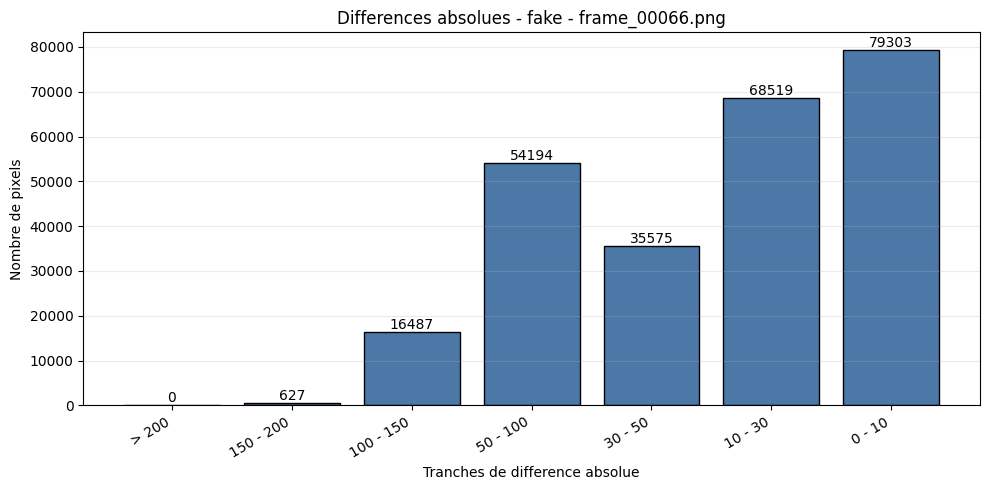

lvl:  4  initial error:  3971.680851063829
 error improvement too small, level converged! it:  4  error:  2092.7859518531686  lambda:  12.8
lvl:  3  initial error:  2129.048130761555
 error improvement too small, level converged! it:  2  error:  2120.34618482475  lambda:  0.0
lvl:  2  initial error:  2335.4082916273114
 error improvement too small, level converged! it:  8  error:  2290.4971575848854  lambda:  0.0
[fake] frame 67 -> frame_00067.png | sum error = 610064640.00 | mean abs error = 35.0418 | valid pixels = 255211


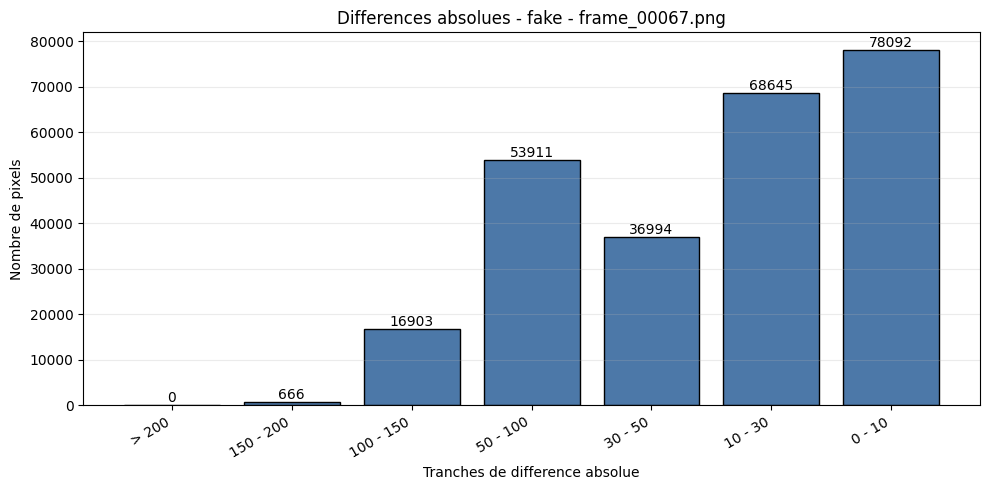

lvl:  4  initial error:  4070.779497098645
 error improvement too small, level converged! it:  6  error:  2111.6537387329377  lambda:  0.0
lvl:  3  initial error:  2154.7999883465873
 error improvement too small, level converged! it:  3  error:  2142.1054687007645  lambda:  12.8
lvl:  2  initial error:  2351.6571449284743
 error improvement too small, level converged! it:  4  error:  2323.3563800812763  lambda:  0.0
[fake] frame 68 -> frame_00068.png | sum error = 618768320.00 | mean abs error = 35.4558 | valid pixels = 253778


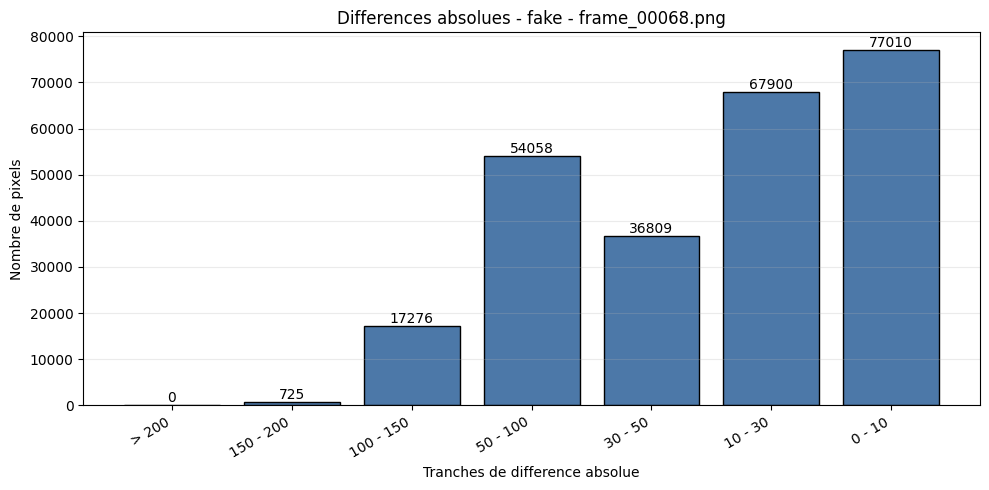

lvl:  4  initial error:  4124.374274661508
 error improvement too small, level converged! it:  4  error:  2149.078602912841  lambda:  1.6
lvl:  3  initial error:  2170.754882082275
 error improvement too small, level converged! it:  2  error:  2167.3121980328474  lambda:  102.4
lvl:  2  initial error:  2400.6329690344955
 error improvement too small, level converged! it:  2  error:  2391.434610346194  lambda:  0.0
[fake] frame 69 -> frame_00069.png | sum error = 625709440.00 | mean abs error = 35.8745 | valid pixels = 252317


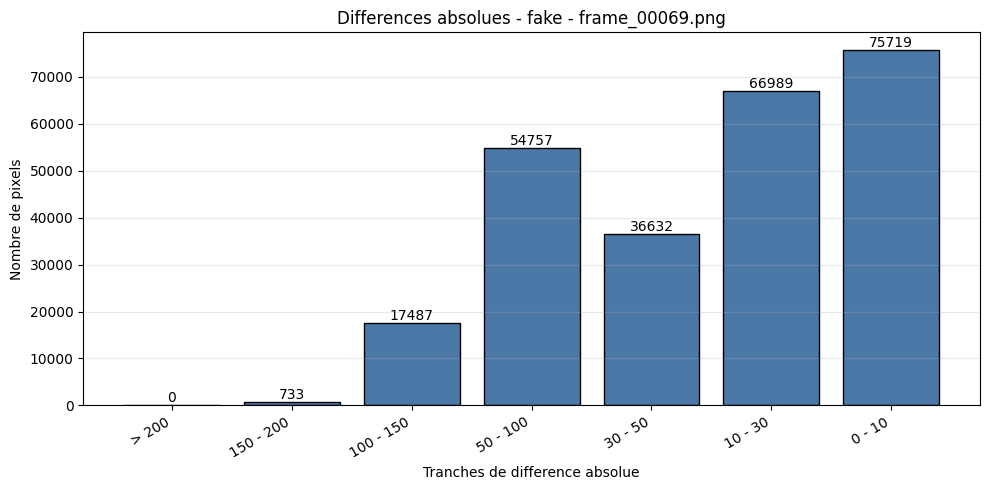

lvl:  4  initial error:  4157.020309477755
 error improvement too small, level converged! it:  5  error:  2158.1911932770154  lambda:  0.1
lvl:  3  initial error:  2281.2036205890627
 error improvement too small, level converged! it:  3  error:  2267.8441958243598  lambda:  0.0
lvl:  2  initial error:  2415.906050717654
 error improvement too small, level converged! it:  2  error:  2409.486696130398  lambda:  0.0
[fake] frame 70 -> frame_00070.png | sum error = 635180096.00 | mean abs error = 36.2523 | valid pixels = 251379


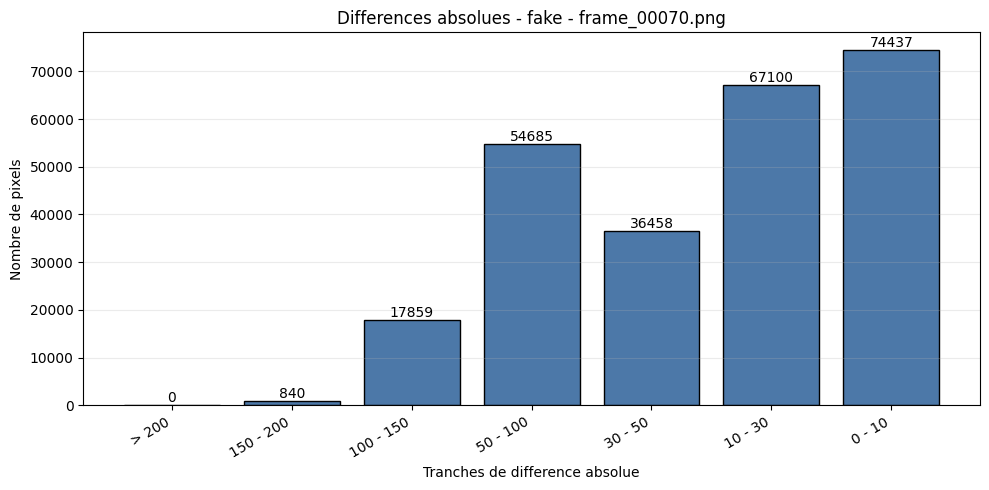

lvl:  4  initial error:  4096.978723404254
 error improvement too small, level converged! it:  3  error:  2133.397604474441  lambda:  0.0
lvl:  3  initial error:  2302.2893285107184
 error improvement too small, level converged! it:  3  error:  2284.315884481746  lambda:  0.0
lvl:  2  initial error:  2462.781261787917
 error improvement too small, level converged! it:  4  error:  2447.1863036042328  lambda:  0.0
[fake] frame 71 -> frame_00071.png | sum error = 634748672.00 | mean abs error = 36.6616 | valid pixels = 248599


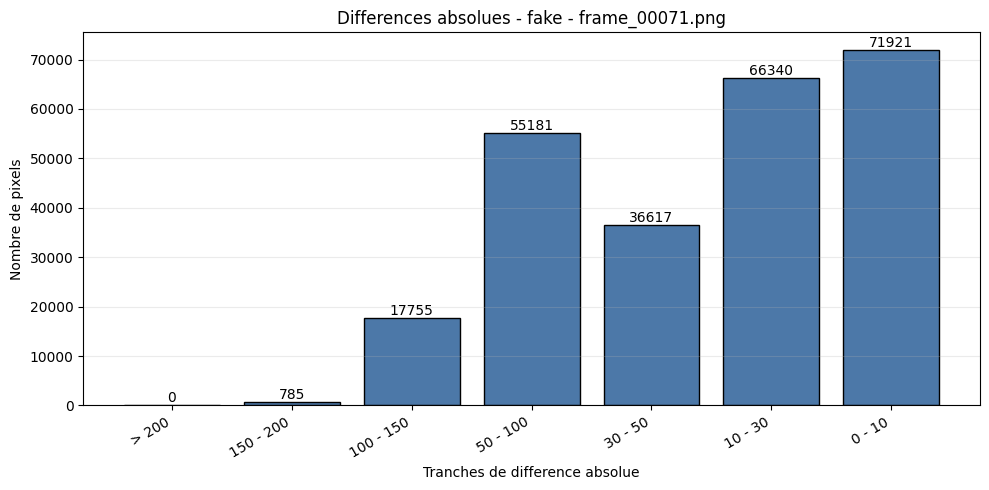

lvl:  4  initial error:  4165.727272727272
 error improvement too small, level converged! it:  2  error:  2298.807268268676  lambda:  0.0
lvl:  3  initial error:  2290.306726268618
 error improvement too small, level converged! it:  1  error:  2289.16665901265  lambda:  0.0
lvl:  2  initial error:  2487.8610261381673
 error improvement too small, level converged! it:  2  error:  2481.2676502714176  lambda:  0.0
[fake] frame 72 -> frame_00072.png | sum error = 641215744.00 | mean abs error = 37.1457 | valid pixels = 246954


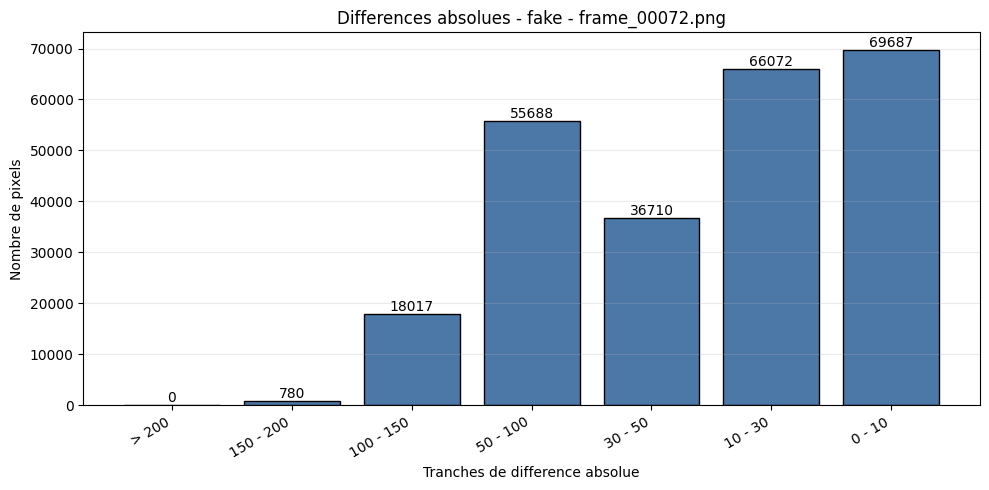

lvl:  4  initial error:  4293.645067698259
 error improvement too small, level converged! it:  2  error:  2379.681908487828  lambda:  0.0
lvl:  3  initial error:  2337.406286522498
 error improvement too small, level converged! it:  1  error:  2337.3198198006244  lambda:  0.2
lvl:  2  initial error:  2534.7455383669644
 error improvement too small, level converged! it:  2  error:  2529.022294433788  lambda:  1.6
[fake] frame 73 -> frame_00073.png | sum error = 647760960.00 | mean abs error = 37.5824 | valid pixels = 245400


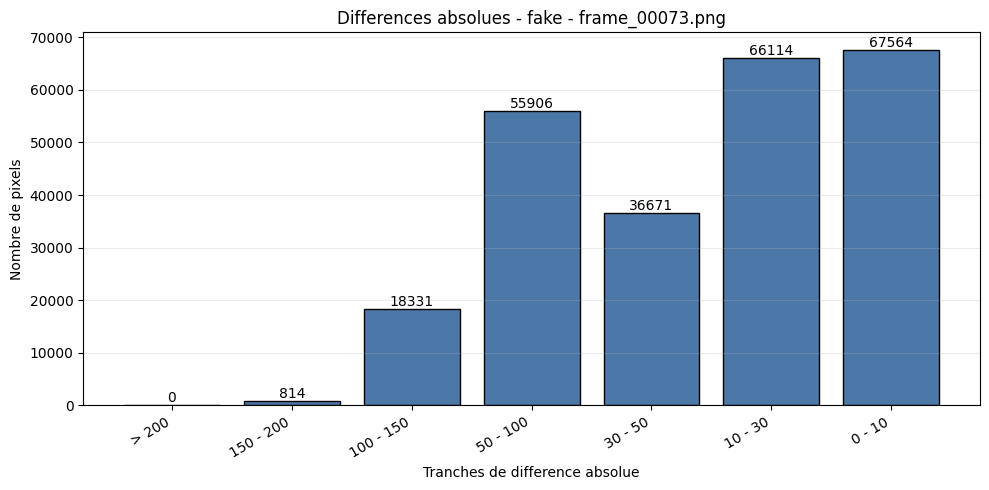

lvl:  4  initial error:  4305.744680851063
 error improvement too small, level converged! it:  7  error:  2347.875943004945  lambda:  0.1
lvl:  3  initial error:  2391.400394117489
 error improvement too small, level converged! it:  1  error:  2390.3439556864755  lambda:  0.0
lvl:  2  initial error:  2595.924047319857
 error improvement too small, level converged! it:  7  error:  2564.033395566704  lambda:  0.0
[fake] frame 74 -> frame_00074.png | sum error = 652705344.00 | mean abs error = 37.7748 | valid pixels = 244310


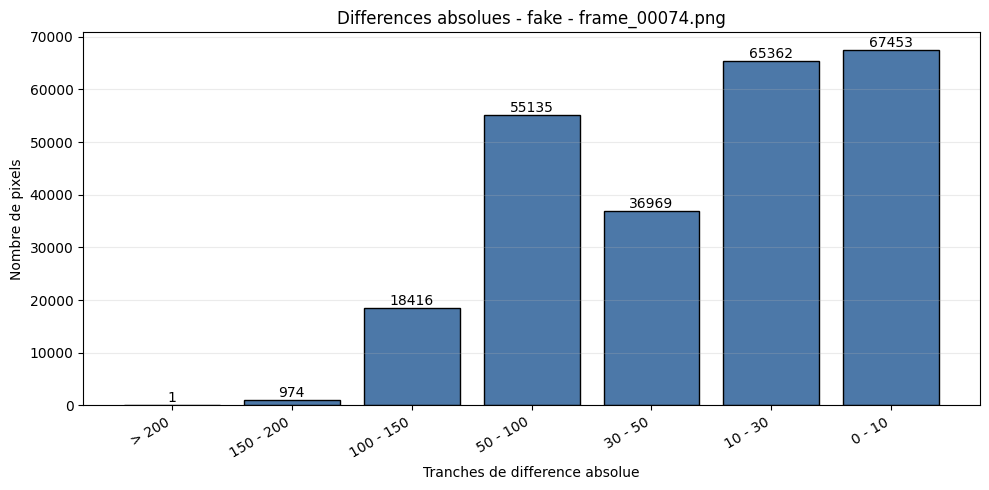

lvl:  4  initial error:  4315.043520309477
 error improvement too small, level converged! it:  11  error:  2361.642818781014  lambda:  879609302220.8
lvl:  3  initial error:  2469.1915903198737
 error improvement too small, level converged! it:  8  error:  2444.6777325009452  lambda:  0.0
lvl:  2  initial error:  2622.5217925067
 error improvement too small, level converged! it:  1  error:  2622.3235735069743  lambda:  1.6
[fake] frame 75 -> frame_00075.png | sum error = 665594688.00 | mean abs error = 38.4350 | valid pixels = 243897


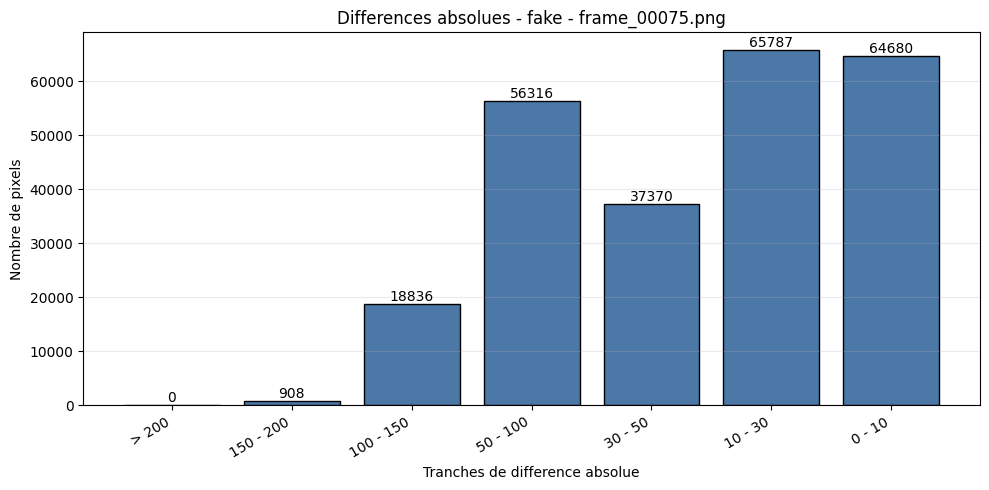

lvl:  4  initial error:  4355.637330754351
 error improvement too small, level converged! it:  2  error:  2403.465759627455  lambda:  1.6
lvl:  3  initial error:  2513.935103742005
 error improvement too small, level converged! it:  4  error:  2488.3018006665275  lambda:  204.8
lvl:  2  initial error:  2665.7233481053195
 error improvement too small, level converged! it:  2  error:  2653.553938373575  lambda:  0.0
[fake] frame 76 -> frame_00076.png | sum error = 673657984.00 | mean abs error = 38.6531 | valid pixels = 244036


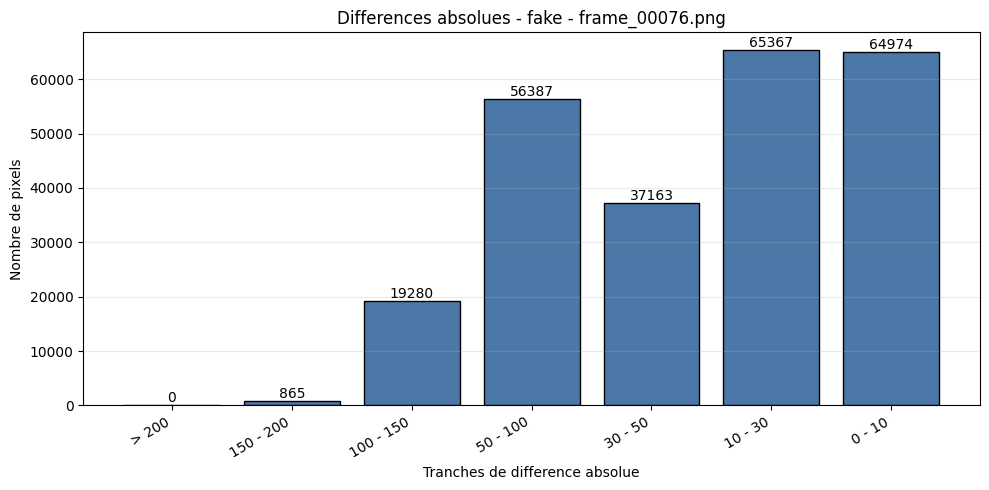

lvl:  4  initial error:  4333.514506769825
 error improvement too small, level converged! it:  4  error:  2386.026893870463  lambda:  0.4
lvl:  3  initial error:  2526.230095795603
 error improvement too small, level converged! it:  4  error:  2508.16690365086  lambda:  0.0
lvl:  2  initial error:  2673.801382722277
 error improvement too small, level converged! it:  1  error:  2673.6692825293158  lambda:  3.2
[fake] frame 77 -> frame_00077.png | sum error = 675257984.00 | mean abs error = 39.0722 | valid pixels = 241689


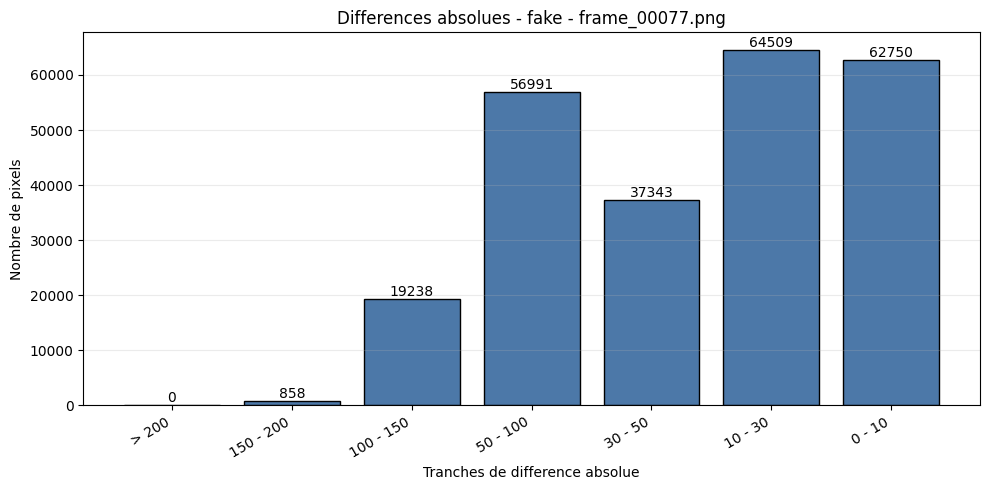

lvl:  4  initial error:  4268.735009671179
 error improvement too small, level converged! it:  4  error:  2428.3934294960573  lambda:  1.6
lvl:  3  initial error:  2578.657997674851
 error improvement too small, level converged! it:  6  error:  2552.1125034711063  lambda:  0.0
lvl:  2  initial error:  2717.5556969452127
 error improvement too small, level converged! it:  1  error:  2716.804100889451  lambda:  0.0
[fake] frame 78 -> frame_00078.png | sum error = 681664768.00 | mean abs error = 39.2807 | valid pixels = 241487


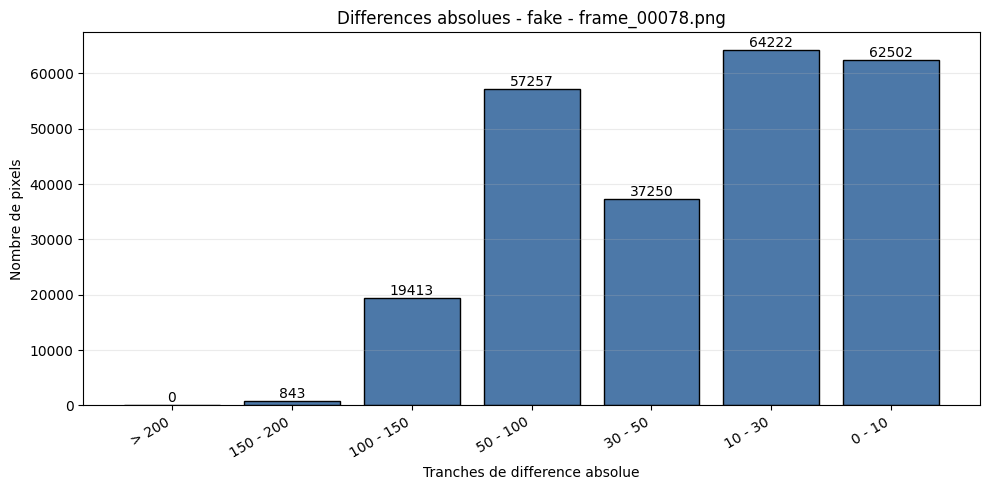

lvl:  4  initial error:  4247.019342359767
 error improvement too small, level converged! it:  3  error:  2475.4560037138963  lambda:  0.4
lvl:  3  initial error:  2581.5444209112334
 error improvement too small, level converged! it:  2  error:  2573.5614053851386  lambda:  0.0
lvl:  2  initial error:  2752.8765021007366
 error improvement too small, level converged! it:  2  error:  2749.263846066434  lambda:  0.4
[fake] frame 79 -> frame_00079.png | sum error = 688315456.00 | mean abs error = 39.5080 | valid pixels = 241293


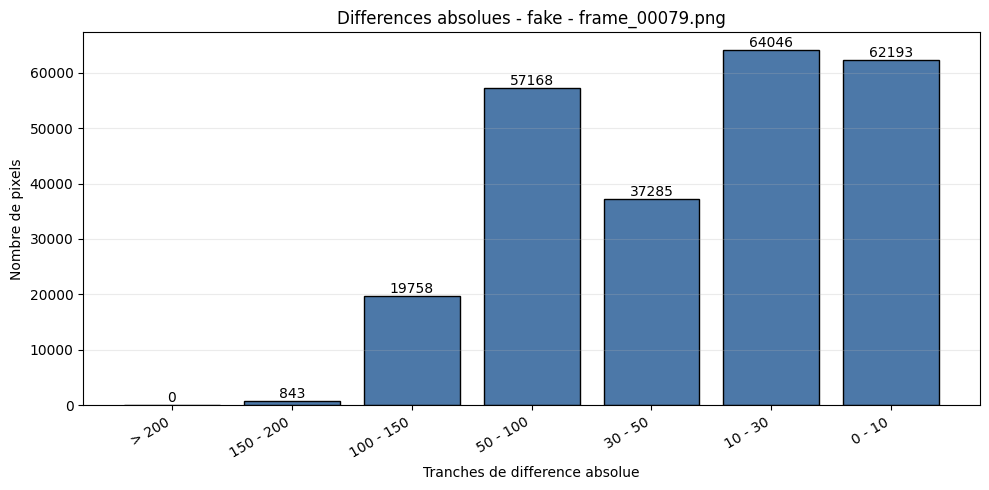

lvl:  4  initial error:  4284.399419729205
 error improvement too small, level converged! it:  3  error:  2486.1631973173157  lambda:  1759218604441.6
lvl:  3  initial error:  2606.5464239823336
 error improvement too small, level converged! it:  4  error:  2577.6651099931605  lambda:  12.8
lvl:  2  initial error:  2783.3083266591093
 error improvement too small, level converged! it:  2  error:  2776.8405823927874  lambda:  0.0
[fake] frame 80 -> frame_00080.png | sum error = 693416256.00 | mean abs error = 39.7906 | valid pixels = 240530


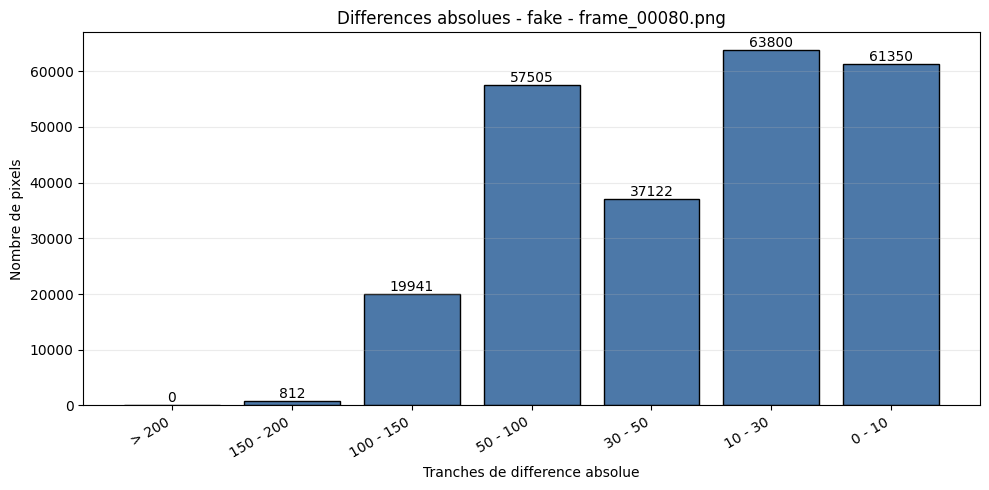

lvl:  4  initial error:  4306.659574468084
 error improvement too small, level converged! it:  2  error:  2554.2221699924335  lambda:  1.6
lvl:  3  initial error:  2646.3949341759117
 error improvement too small, level converged! it:  3  error:  2602.045188633842  lambda:  0.0
lvl:  2  initial error:  2797.9234226682934
 error improvement too small, level converged! it:  2  error:  2789.653686900583  lambda:  0.4
[fake] frame 81 -> frame_00081.png | sum error = 697476864.00 | mean abs error = 40.0642 | valid pixels = 239709


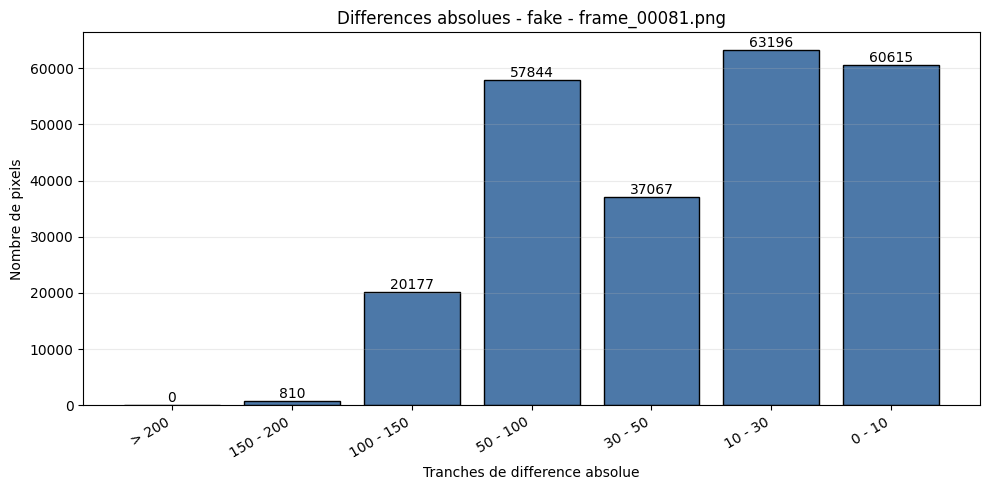

lvl:  4  initial error:  4306.941972920696
 error improvement too small, level converged! it:  2  error:  2650.590532542111  lambda:  0.8
lvl:  3  initial error:  2648.299863127204
 error improvement too small, level converged! it:  3  error:  2622.8794372017273  lambda:  0.1
lvl:  2  initial error:  2861.143128244591
 error improvement too small, level converged! it:  3  error:  2843.381201505536  lambda:  0.0
[fake] frame 82 -> frame_00082.png | sum error = 700315008.00 | mean abs error = 40.2956 | valid pixels = 238608


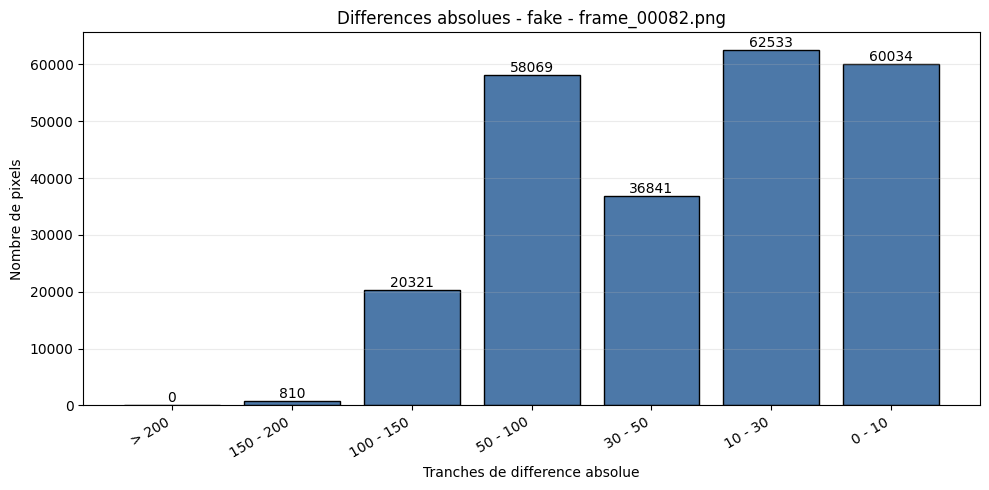

lvl:  4  initial error:  4241.134429400386
 error improvement too small, level converged! it:  10  error:  2494.0877202146444  lambda:  12.8
lvl:  3  initial error:  2557.1371464722993
 error improvement too small, level converged! it:  2  error:  2540.2512927635476  lambda:  0.1
lvl:  2  initial error:  2717.4541171396213
 error improvement too small, level converged! it:  8  error:  2679.667034318681  lambda:  0.0
[fake] frame 83 -> frame_00083.png | sum error = 613039552.00 | mean abs error = 39.9492 | valid pixels = 220081


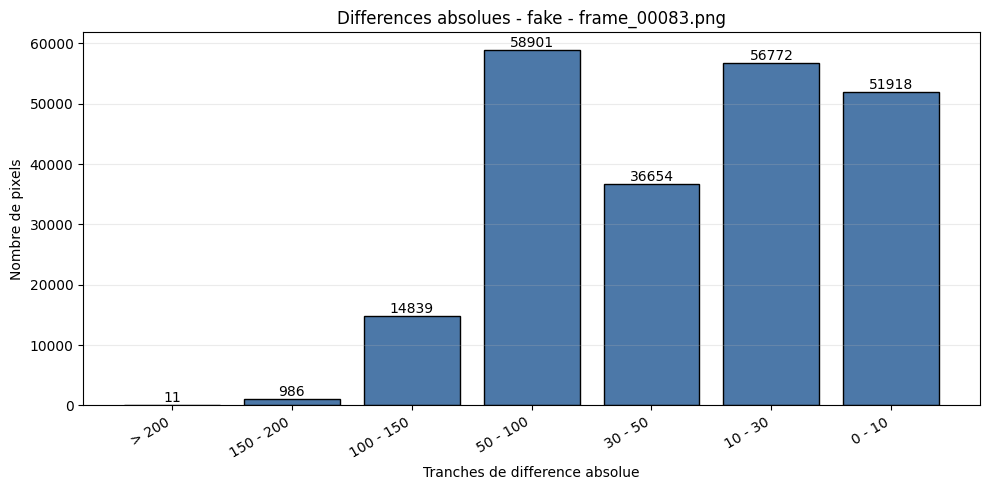

lvl:  4  initial error:  4208.428433268858
 error improvement too small, level converged! it:  2  error:  2453.794908935689  lambda:  12.8
lvl:  3  initial error:  2624.8557528241163
 error improvement too small, level converged! it:  6  error:  2564.8162409580145  lambda:  0.0
lvl:  2  initial error:  2723.511476533227
 error improvement too small, level converged! it:  1  error:  2721.86153932642  lambda:  0.0
[fake] frame 84 -> frame_00084.png | sum error = 621278720.00 | mean abs error = 40.3666 | valid pixels = 219343


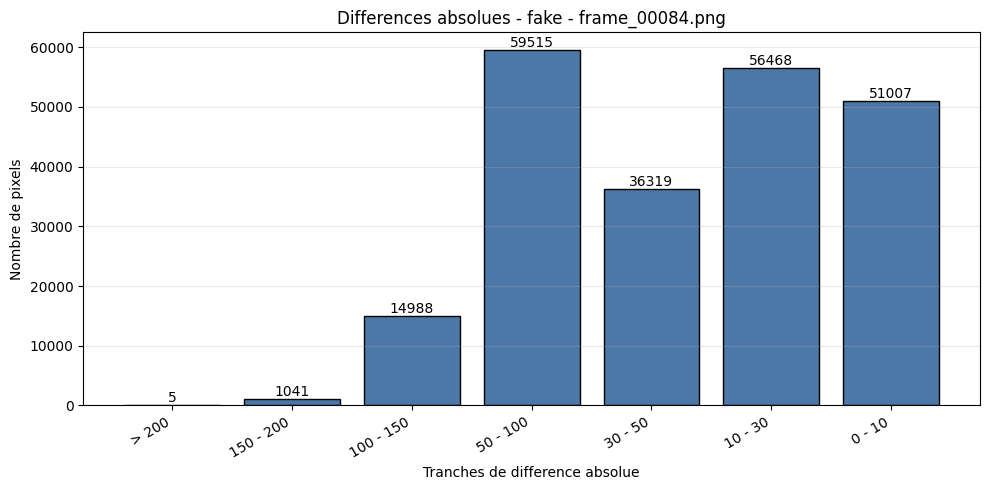

lvl:  4  initial error:  4245.2920696324945
 error improvement too small, level converged! it:  3  error:  2541.746098002541  lambda:  12.8
lvl:  3  initial error:  2605.8796521758477
 error improvement too small, level converged! it:  7  error:  2543.027496893559  lambda:  0.0
lvl:  2  initial error:  2766.1442950276173
 error improvement too small, level converged! it:  1  error:  2764.956381798657  lambda:  0.0
[fake] frame 85 -> frame_00085.png | sum error = 619925952.00 | mean abs error = 40.4702 | valid pixels = 218153


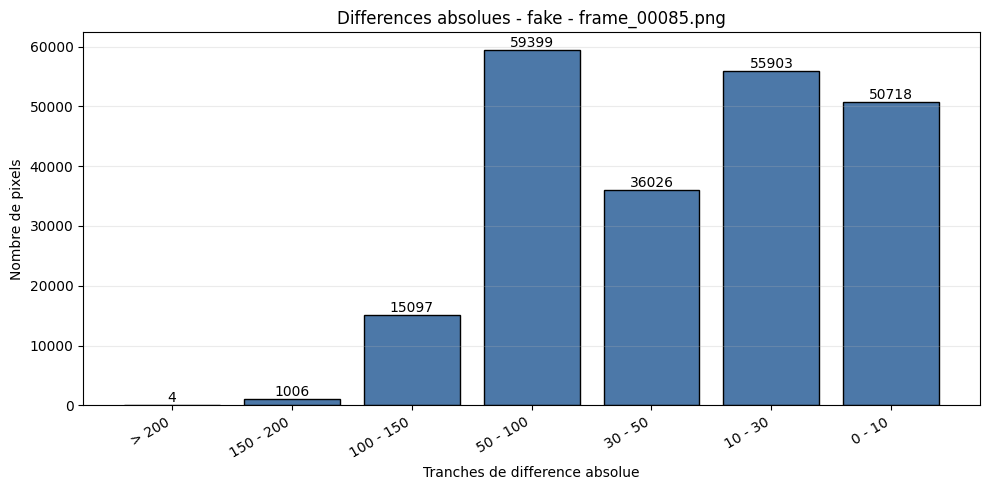

lvl:  4  initial error:  4188.219535783364
 error improvement too small, level converged! it:  3  error:  2594.012513858338  lambda:  112589990684262.4
lvl:  3  initial error:  2606.519548498565
 error improvement too small, level converged! it:  3  error:  2564.229219318152  lambda:  1.6
lvl:  2  initial error:  2788.9882316336007
 error improvement too small, level converged! it:  5  error:  2756.8788831268485  lambda:  0.0
[fake] frame 86 -> frame_00086.png | sum error = 616264256.00 | mean abs error = 40.4977 | valid pixels = 216839


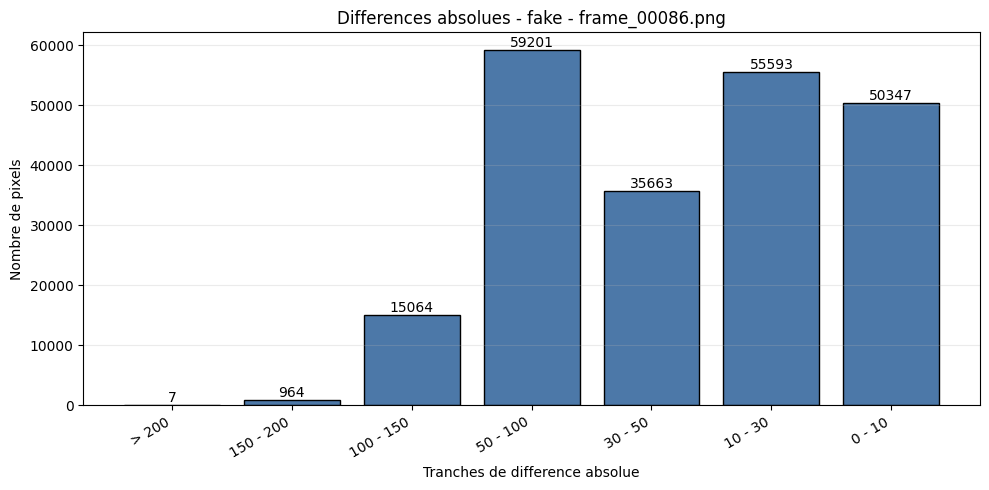

lvl:  4  initial error:  4186.941005802707
 error improvement too small, level converged! it:  3  error:  2623.1212369173345  lambda:  12.8
lvl:  3  initial error:  2642.4690549538186
 error improvement too small, level converged! it:  2  error:  2625.555605034988  lambda:  0.0
lvl:  2  initial error:  2818.8896589716824
 error improvement too small, level converged! it:  7  error:  2791.920733335759  lambda:  0.0
[fake] frame 87 -> frame_00087.png | sum error = 618355200.00 | mean abs error = 40.7241 | valid pixels = 215830


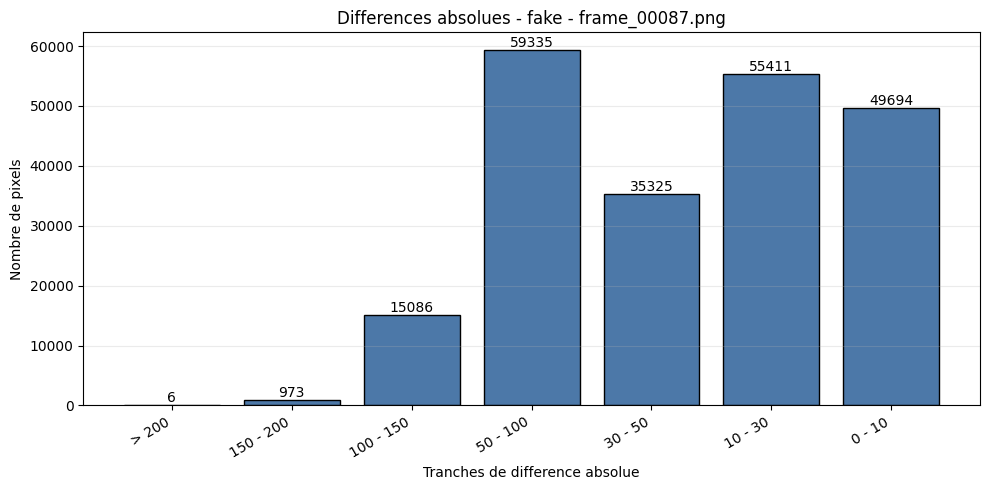

lvl:  4  initial error:  4197.814313346227
 error improvement too small, level converged! it:  2  error:  2626.0059503697967  lambda:  14073748835532.8
lvl:  3  initial error:  2721.7476273598418
 error improvement too small, level converged! it:  2  error:  2678.411608488402  lambda:  0.1
lvl:  2  initial error:  2834.884348520136
 error improvement too small, level converged! it:  7  error:  2796.0588090929155  lambda:  0.0
[fake] frame 88 -> frame_00088.png | sum error = 620858240.00 | mean abs error = 40.8674 | valid pixels = 214928


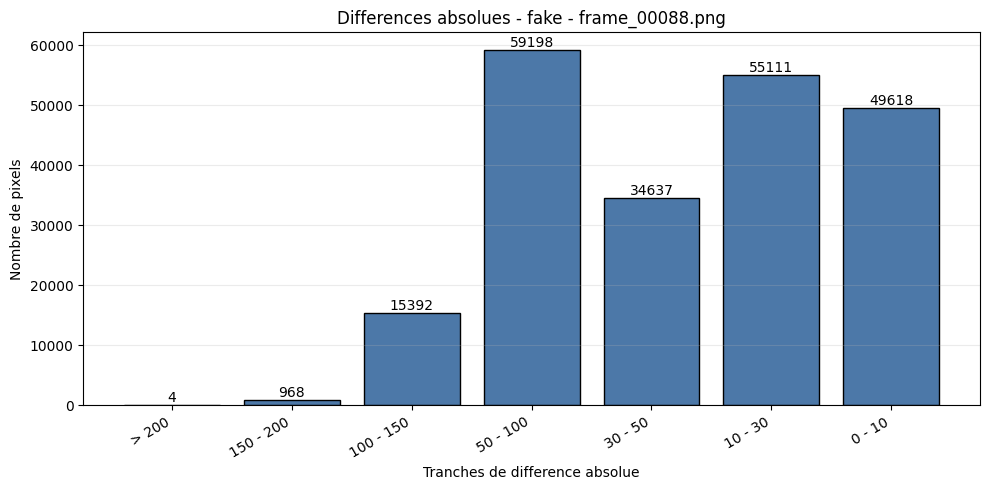

lvl:  4  initial error:  4215.159574468084
 error improvement too small, level converged! it:  3  error:  2675.73585617326  lambda:  0.4
lvl:  3  initial error:  2691.7160498239155
 error improvement too small, level converged! it:  7  error:  2654.422544626421  lambda:  0.0
lvl:  2  initial error:  2841.681514770816
 error improvement too small, level converged! it:  6  error:  2794.0047174478746  lambda:  0.0
[fake] frame 89 -> frame_00089.png | sum error = 620614272.00 | mean abs error = 41.0046 | valid pixels = 214047


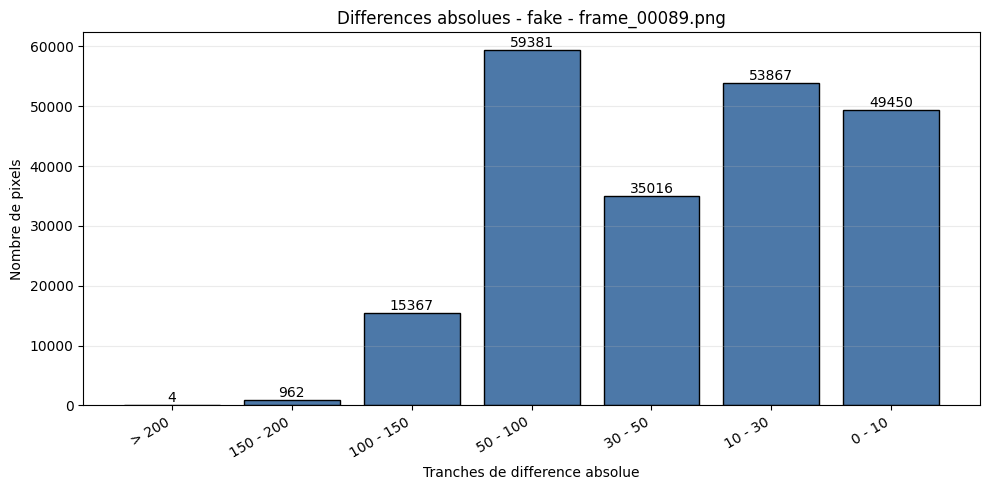

lvl:  4  initial error:  4215.024177949709
 error improvement too small, level converged! it:  7  error:  2677.77936893919  lambda:  0.2
lvl:  3  initial error:  2676.087006274082
 error improvement too small, level converged! it:  6  error:  2636.748092470805  lambda:  0.1
lvl:  2  initial error:  2866.6956498260765
 error improvement too small, level converged! it:  4  error:  2844.1278131712584  lambda:  0.0
[fake] frame 90 -> frame_00090.png | sum error = 633915072.00 | mean abs error = 41.4028 | valid pixels = 215670


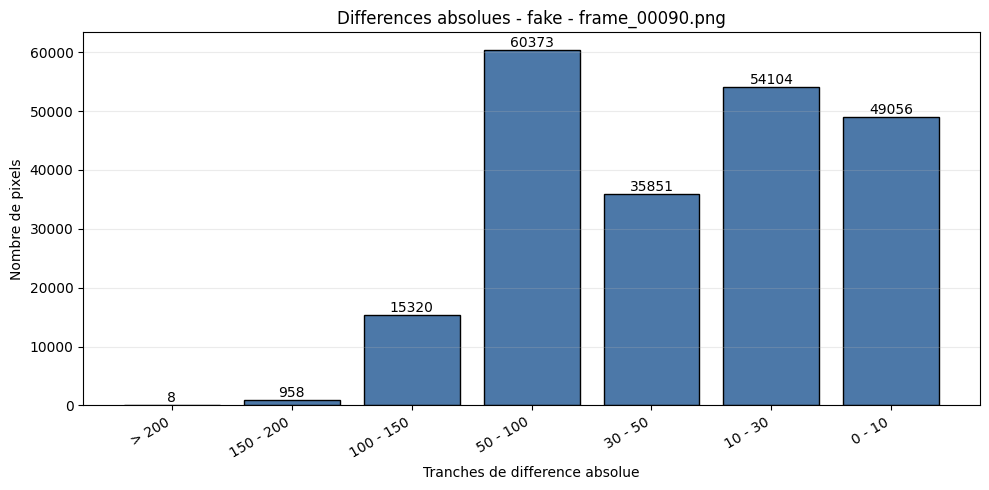

lvl:  4  initial error:  4247.875241779496
 error improvement too small, level converged! it:  5  error:  2709.8396204866826  lambda:  56294995342131.2
lvl:  3  initial error:  2698.292653034444
 error improvement too small, level converged! it:  4  error:  2671.1115587848612  lambda:  0.0
lvl:  2  initial error:  2907.19011722167
 error improvement too small, level converged! it:  8  error:  2856.267271310827  lambda:  0.0
[fake] frame 91 -> frame_00091.png | sum error = 633300416.00 | mean abs error = 41.5000 | valid pixels = 214800


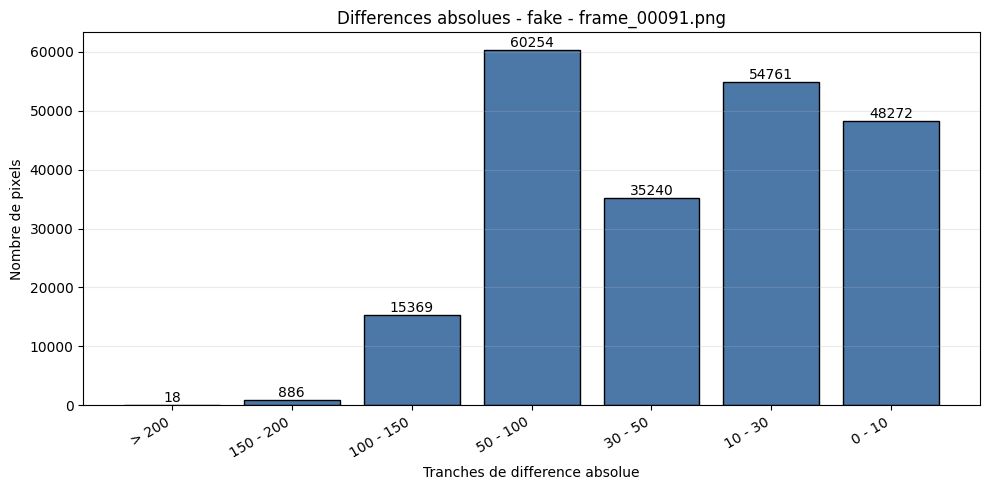

lvl:  4  initial error:  4201.823017408123
 error improvement too small, level converged! it:  4  error:  2676.8732613810425  lambda:  0.8
lvl:  3  initial error:  2744.862237207871
 error improvement too small, level converged! it:  9  error:  2674.571490753811  lambda:  0.0
lvl:  2  initial error:  2940.4991171008364
 error improvement too small, level converged! it:  5  error:  2887.3069111147147  lambda:  0.0
[fake] frame 92 -> frame_00092.png | sum error = 633303936.00 | mean abs error = 41.6423 | valid pixels = 212988


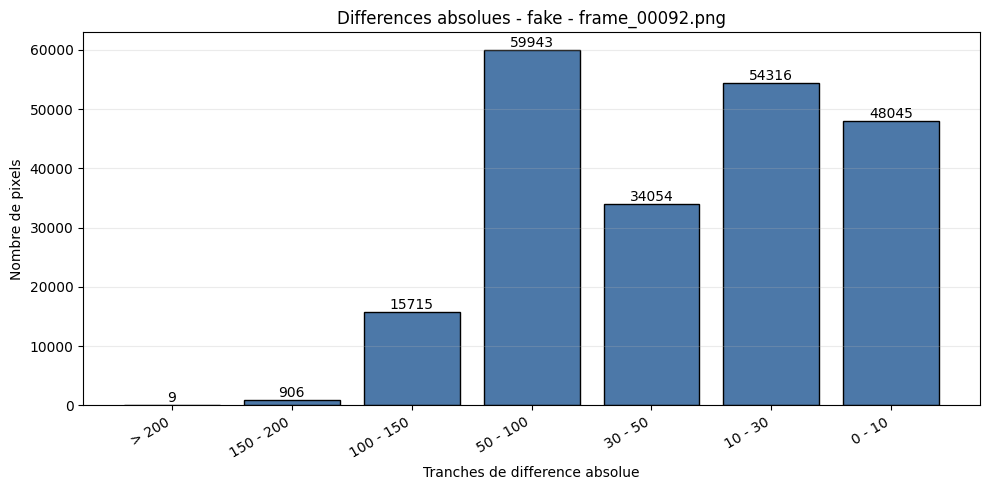

lvl:  4  initial error:  4138.242746615086
 error improvement too small, level converged! it:  5  error:  2634.287817408207  lambda:  0.4
lvl:  3  initial error:  2788.5967247695944
 error improvement too small, level converged! it:  9  error:  2697.24623180117  lambda:  0.0
lvl:  2  initial error:  2994.8392335498015
 error improvement too small, level converged! it:  6  error:  2917.4747979695553  lambda:  0.0
[fake] frame 93 -> frame_00093.png | sum error = 634704128.00 | mean abs error = 41.7786 | valid pixels = 212548


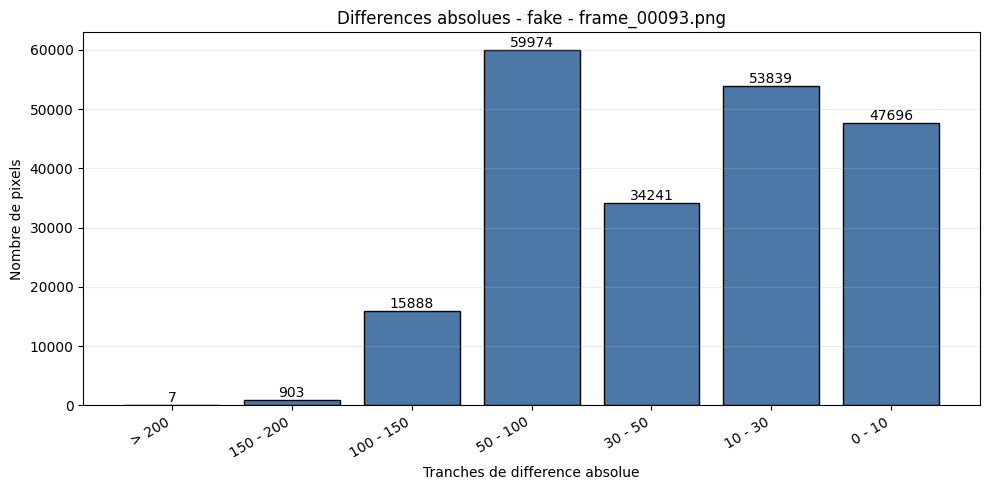

lvl:  4  initial error:  4107.794003868471
 error improvement too small, level converged! it:  6  error:  2645.102534572267  lambda:  0.0
lvl:  3  initial error:  2832.4823818136356
 error improvement too small, level converged! it:  8  error:  2739.41281555964  lambda:  0.1
lvl:  2  initial error:  2995.7013676247457
 error improvement too small, level converged! it:  13  error:  2899.4425308169443  lambda:  0.0
[fake] frame 94 -> frame_00094.png | sum error = 634772928.00 | mean abs error = 41.8380 | valid pixels = 211641


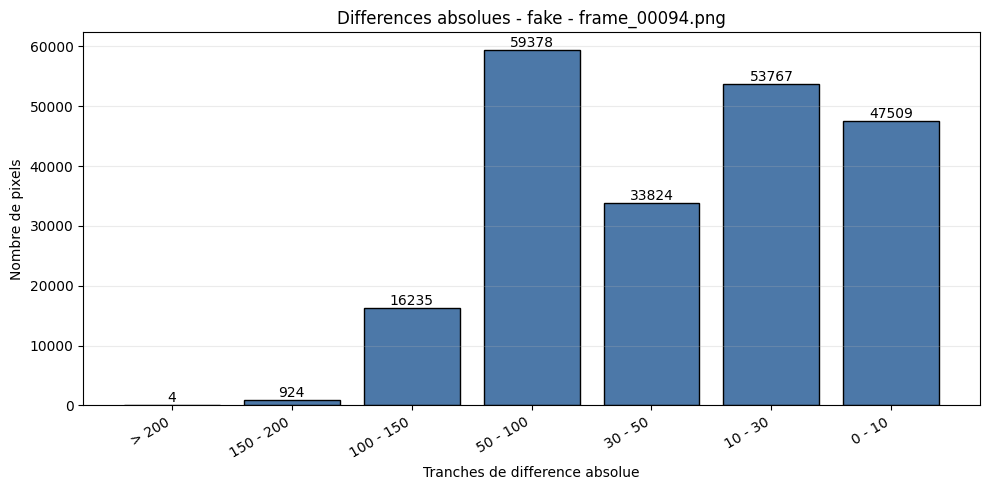

lvl:  4  initial error:  4064.5483558994188
 error improvement too small, level converged! it:  6  error:  2656.759063917906  lambda:  0.0
lvl:  3  initial error:  2781.750940473735
 error improvement too small, level converged! it:  2  error:  2767.9247831958032  lambda:  0.0
lvl:  2  initial error:  3005.8056164067657
 error improvement too small, level converged! it:  15  error:  2913.5261665776434  lambda:  0.0
[fake] frame 95 -> frame_00095.png | sum error = 640189632.00 | mean abs error = 42.0181 | valid pixels = 212642


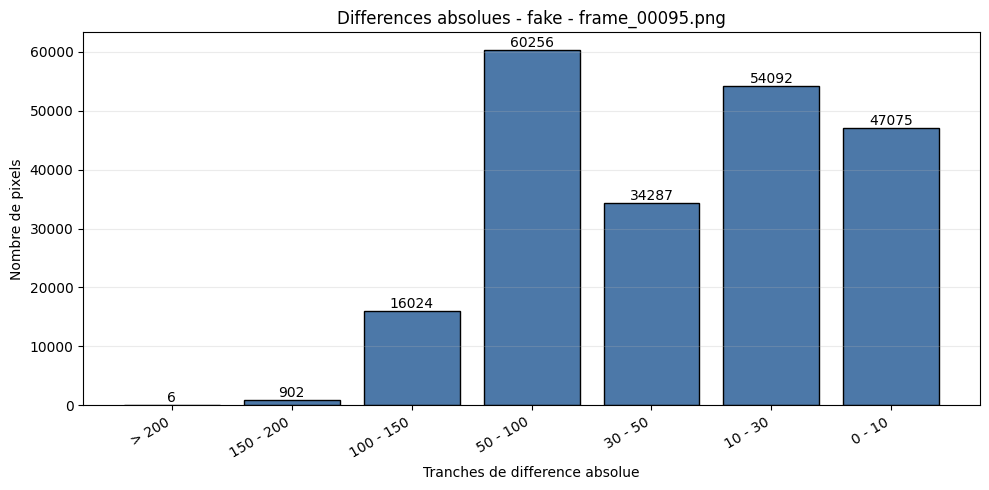

lvl:  4  initial error:  4100.552224371372
 error improvement too small, level converged! it:  4  error:  2682.2360468264574  lambda:  1759218604441.6
lvl:  3  initial error:  2849.5913614632777
 error improvement too small, level converged! it:  2  error:  2832.4836360738004  lambda:  0.2
lvl:  2  initial error:  3004.3366514203963
 error improvement too small, level converged! it:  9  error:  2937.3198183559916  lambda:  0.0
[fake] frame 96 -> frame_00096.png | sum error = 643038784.00 | mean abs error = 42.3067 | valid pixels = 211112


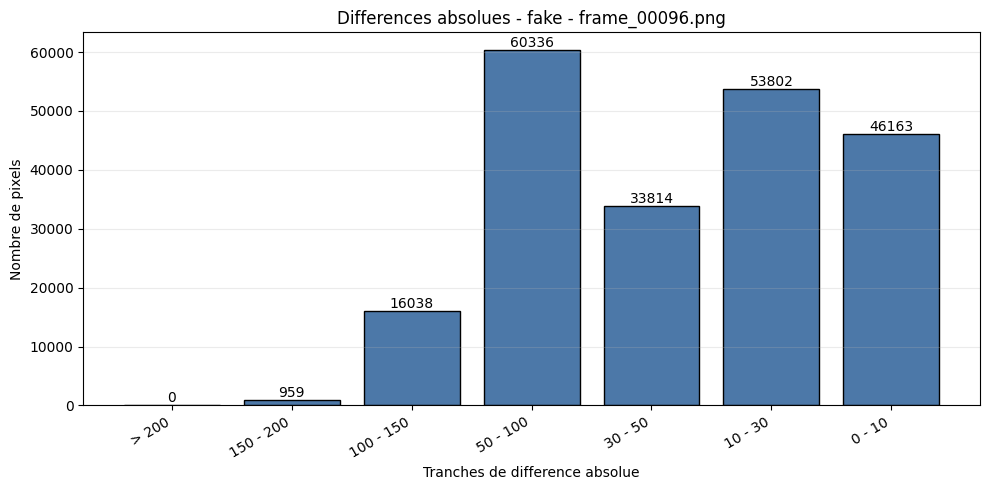

lvl:  4  initial error:  4125.820116054157
 error improvement too small, level converged! it:  6  error:  2714.938572720401  lambda:  28147497671065.6
lvl:  3  initial error:  2894.2794819130277
 error improvement too small, level converged! it:  2  error:  2868.487748095702  lambda:  0.0
lvl:  2  initial error:  3056.8955747925984
 error improvement too small, level converged! it:  11  error:  2958.611640033051  lambda:  0.0
[fake] frame 97 -> frame_00097.png | sum error = 648140032.00 | mean abs error = 42.4645 | valid pixels = 211802


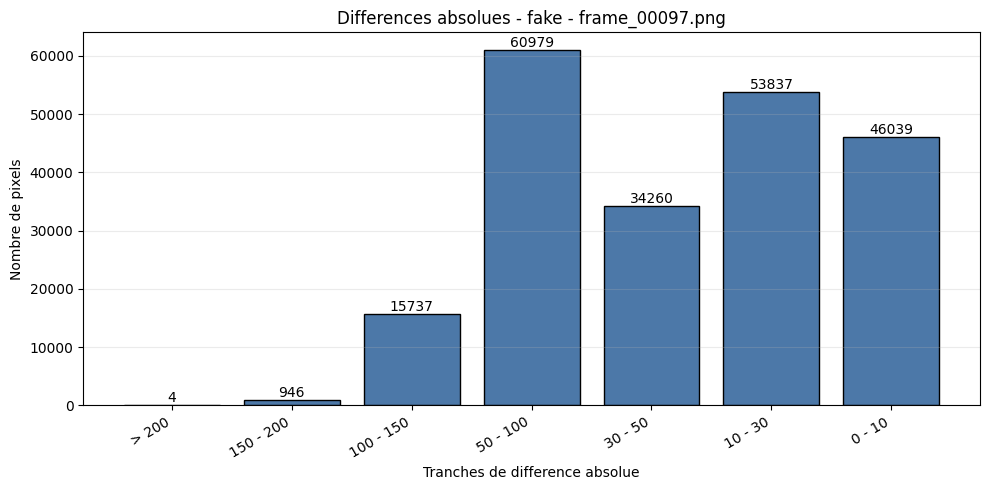

lvl:  4  initial error:  4049.4961315280457
 error improvement too small, level converged! it:  5  error:  2761.6296553027714  lambda:  12.8
lvl:  3  initial error:  2893.693639693801
 error improvement too small, level converged! it:  2  error:  2879.0254062888357  lambda:  0.2
lvl:  2  initial error:  3070.517141612713
 error improvement too small, level converged! it:  11  error:  2980.533095845221  lambda:  0.0
[fake] frame 98 -> frame_00098.png | sum error = 647009344.00 | mean abs error = 42.5491 | valid pixels = 210623


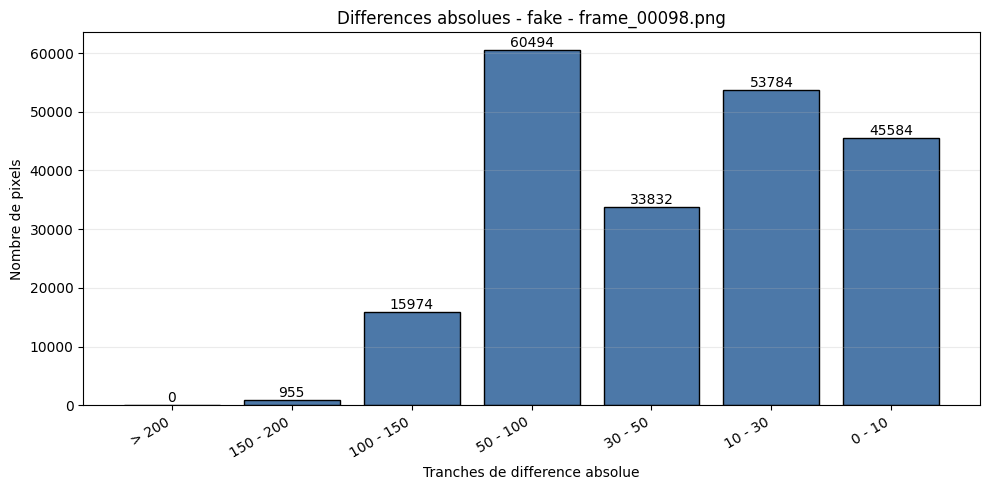

lvl:  4  initial error:  4066.3984526112176
 error improvement too small, level converged! it:  3  error:  2819.0323819184696  lambda:  0.0
lvl:  3  initial error:  2887.201285037552
 error improvement too small, level converged! it:  6  error:  2860.226628376212  lambda:  0.0
lvl:  2  initial error:  3073.6886040848785
 error improvement too small, level converged! it:  7  error:  3009.3463033006515  lambda:  0.0
[fake] frame 99 -> frame_00099.png | sum error = 653575040.00 | mean abs error = 42.7589 | valid pixels = 211102


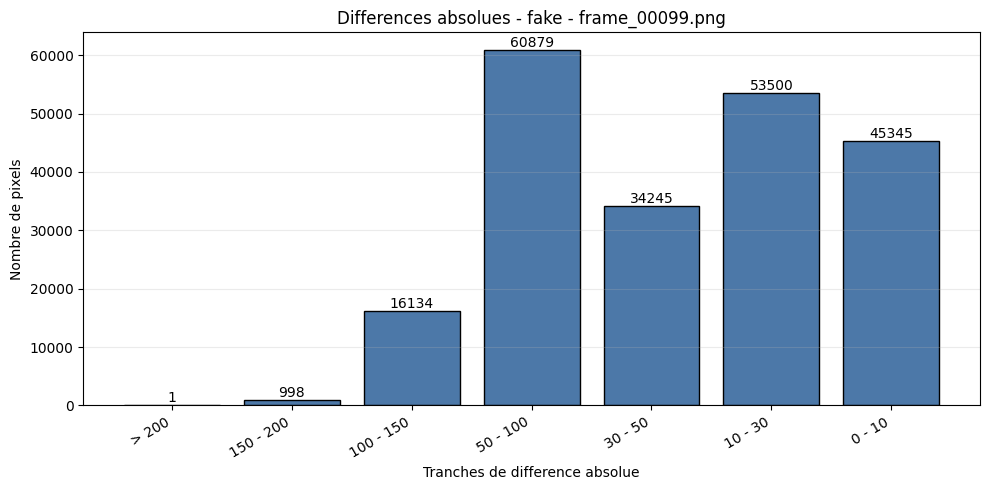

lvl:  4  initial error:  4094.4961315280457
update too small, level converged! it:  5  error:  2797.2604847684306  lambda:  1801439850948198.5
lvl:  3  initial error:  2913.3723550499963
 error improvement too small, level converged! it:  10  error:  2846.690713854824  lambda:  0.0
lvl:  2  initial error:  3092.5788644455206
 error improvement too small, level converged! it:  7  error:  3027.407413098893  lambda:  0.0
[fake] frame 100 -> frame_00100.png | sum error = 662644864.00 | mean abs error = 42.9464 | valid pixels = 212150


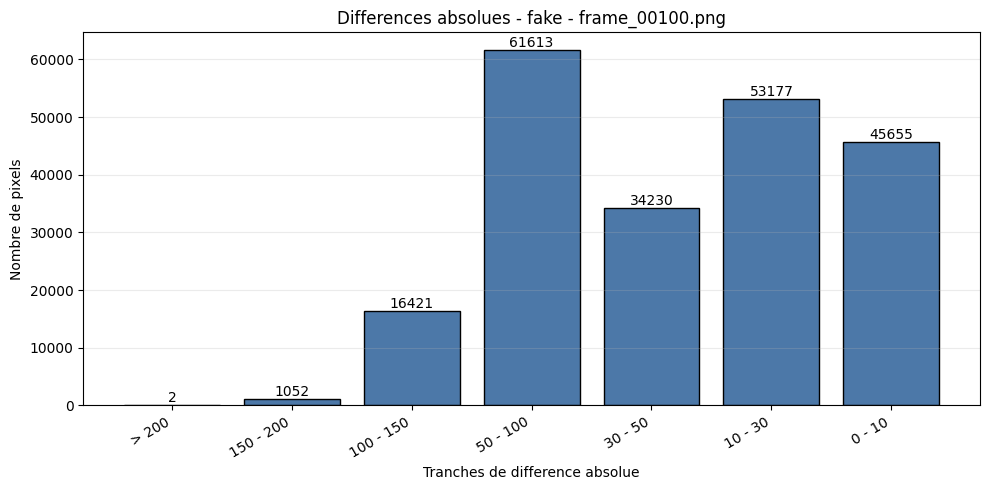

lvl:  4  initial error:  4079.060928433268
 error improvement too small, level converged! it:  4  error:  2782.9464814954754  lambda:  0.8
lvl:  3  initial error:  2908.764772763067
 error improvement too small, level converged! it:  5  error:  2834.933528862477  lambda:  0.0
lvl:  2  initial error:  3043.5304476302613
 error improvement too small, level converged! it:  5  error:  3016.454994710536  lambda:  0.0
[fake] frame 101 -> frame_00101.png | sum error = 659564480.00 | mean abs error = 42.8907 | valid pixels = 211797


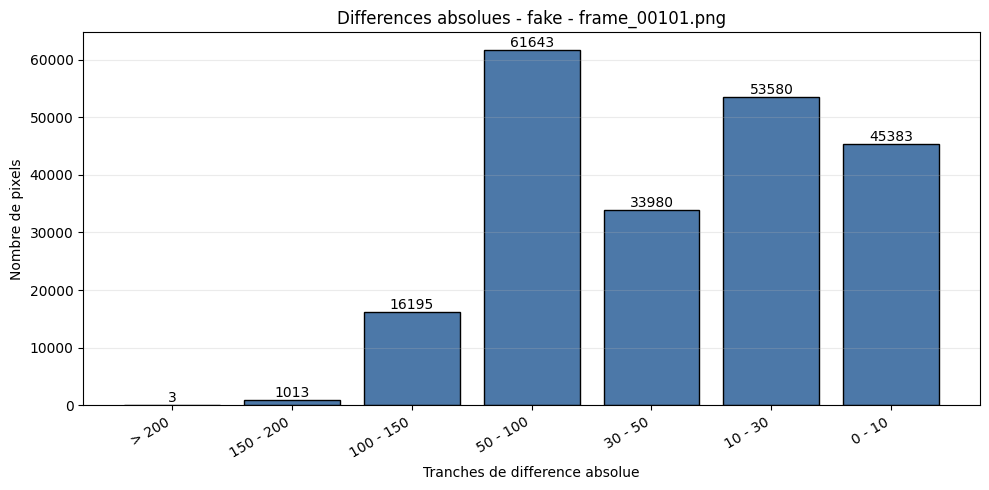

lvl:  4  initial error:  4035.972920696324
 error improvement too small, level converged! it:  5  error:  2811.9721506849546  lambda:  0.4
lvl:  3  initial error:  2926.329510218147
 error improvement too small, level converged! it:  7  error:  2876.4332481912024  lambda:  0.0
lvl:  2  initial error:  3084.0946447718934
 error improvement too small, level converged! it:  11  error:  3020.5716902433956  lambda:  0.0
[fake] frame 102 -> frame_00102.png | sum error = 662794688.00 | mean abs error = 42.9857 | valid pixels = 212440


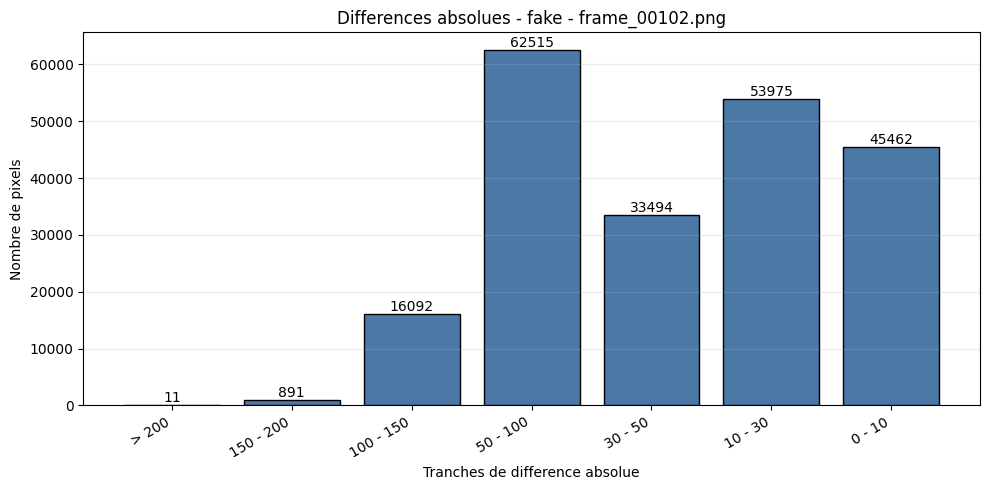

lvl:  4  initial error:  4013.575435203094
 error improvement too small, level converged! it:  4  error:  2791.8640167924214  lambda:  0.4
lvl:  3  initial error:  2951.4197696920683
 error improvement too small, level converged! it:  2  error:  2938.3203451294953  lambda:  0.4
lvl:  2  initial error:  3131.020511274864
 error improvement too small, level converged! it:  9  error:  3083.2014808781432  lambda:  0.0
[fake] frame 103 -> frame_00103.png | sum error = 673808192.00 | mean abs error = 43.4361 | valid pixels = 212707


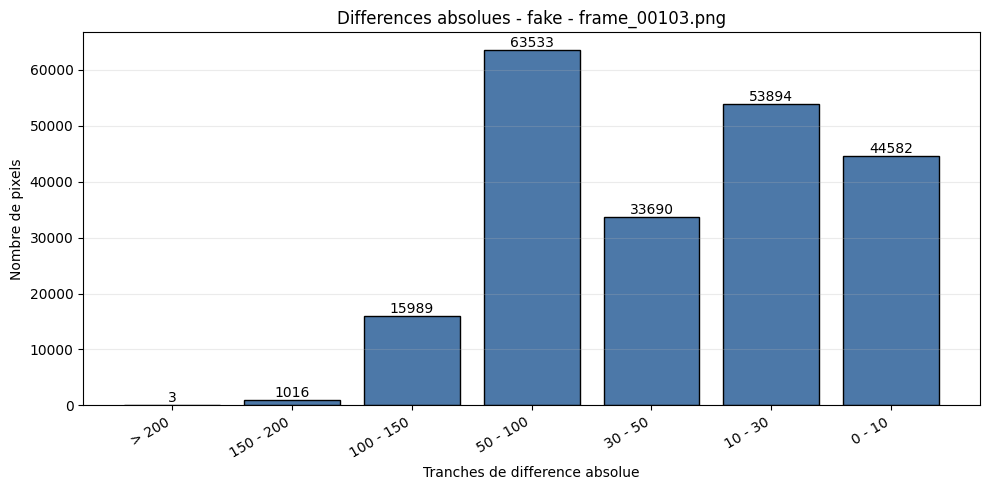

lvl:  4  initial error:  3998.219535783365
 error improvement too small, level converged! it:  3  error:  2779.328264931264  lambda:  0.0
lvl:  3  initial error:  2990.677607494908
 error improvement too small, level converged! it:  2  error:  2975.5664717029645  lambda:  0.2
lvl:  2  initial error:  3158.5444040013726
 error improvement too small, level converged! it:  7  error:  3101.054097175384  lambda:  0.0
[fake] frame 104 -> frame_00104.png | sum error = 686148928.00 | mean abs error = 43.8442 | valid pixels = 213006


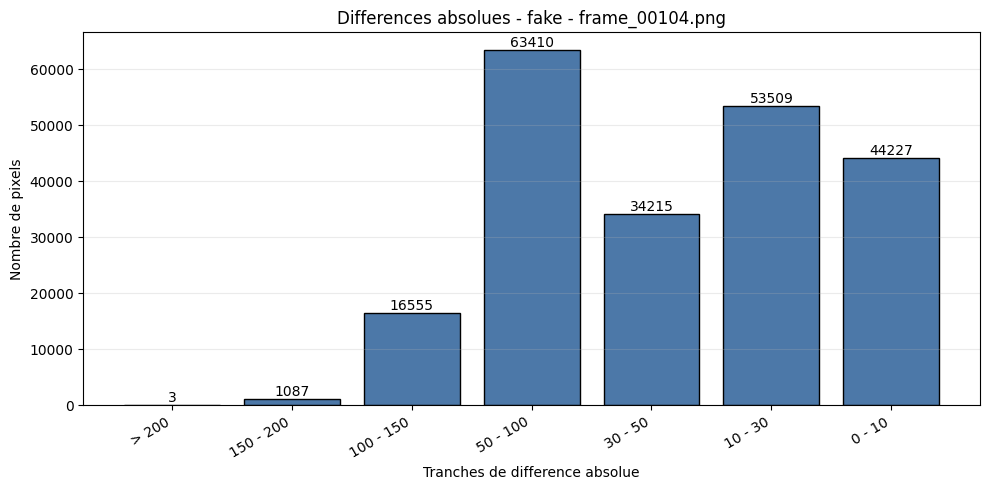

lvl:  4  initial error:  4055.217601547388
 error improvement too small, level converged! it:  5  error:  2766.1444465673558  lambda:  0.2
lvl:  3  initial error:  3030.637757548333
 error improvement too small, level converged! it:  8  error:  2938.9600710838195  lambda:  0.0
lvl:  2  initial error:  3197.8081365784183
 error improvement too small, level converged! it:  9  error:  3095.927689871805  lambda:  0.0
[fake] frame 105 -> frame_00105.png | sum error = 672984128.00 | mean abs error = 43.5485 | valid pixels = 211357


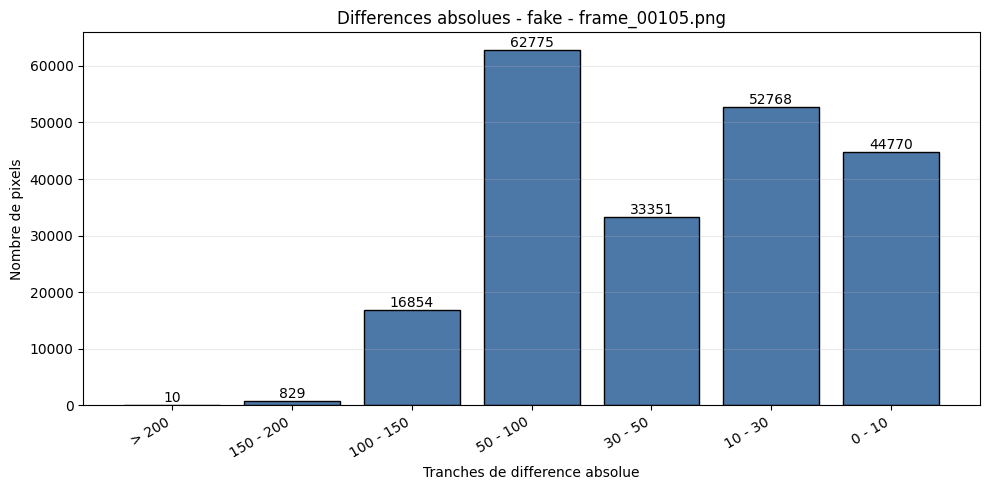

lvl:  4  initial error:  4060.441972920695
 error improvement too small, level converged! it:  6  error:  2755.71798300484  lambda:  1.6
lvl:  3  initial error:  2963.480905778964
 error improvement too small, level converged! it:  2  error:  2959.2909340757165  lambda:  0.4
lvl:  2  initial error:  3212.3291410037154
 error improvement too small, level converged! it:  12  error:  3114.933423553558  lambda:  0.0
[fake] frame 106 -> frame_00106.png | sum error = 674349568.00 | mean abs error = 43.7658 | valid pixels = 211124


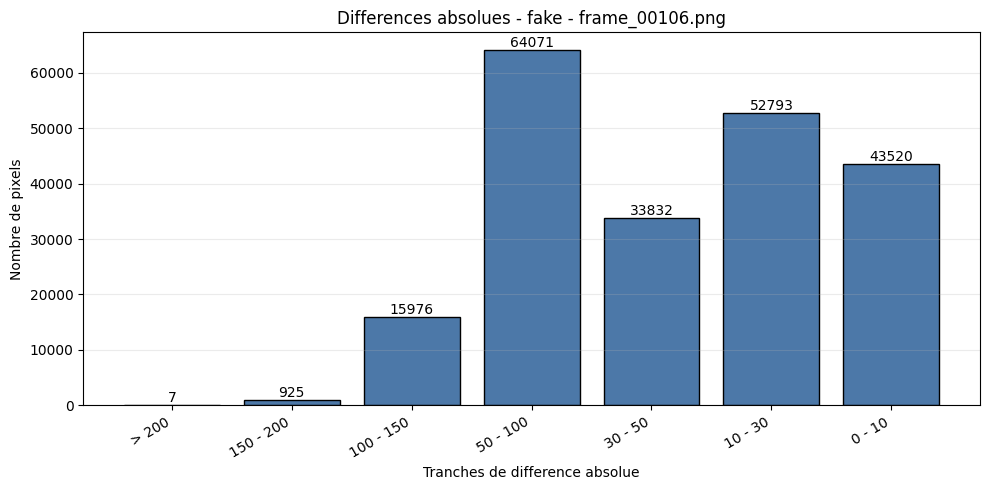

lvl:  4  initial error:  4058.1499032881993
 error improvement too small, level converged! it:  4  error:  2792.273601965563  lambda:  0.1
lvl:  3  initial error:  2972.1417788644217
 error improvement too small, level converged! it:  1  error:  2969.8830450707583  lambda:  0.1
lvl:  2  initial error:  3212.9657633955235
 error improvement too small, level converged! it:  12  error:  3099.7572271569575  lambda:  0.0
[fake] frame 107 -> frame_00107.png | sum error = 675122176.00 | mean abs error = 43.8159 | valid pixels = 211107


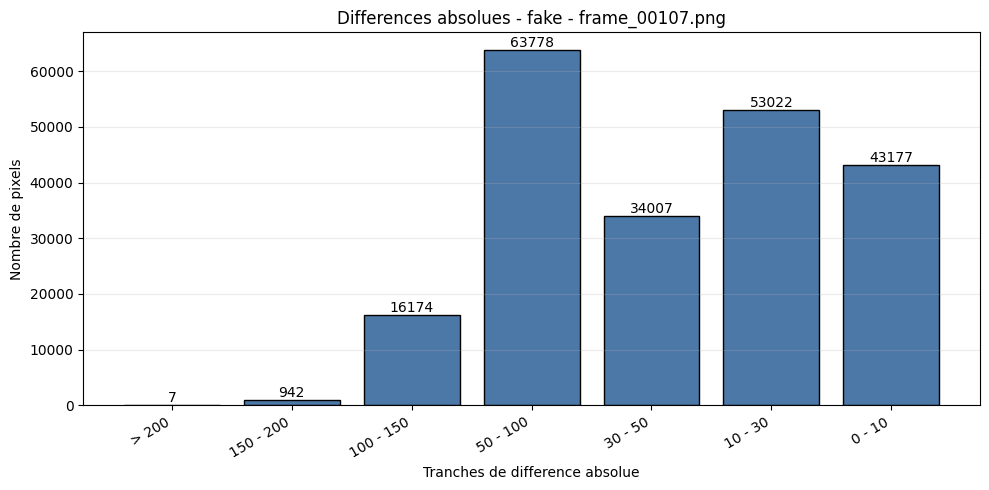

lvl:  4  initial error:  4005.1586073500957
 error improvement too small, level converged! it:  4  error:  2844.6512517363835  lambda:  0.1
lvl:  3  initial error:  3011.029552666662
 error improvement too small, level converged! it:  2  error:  3004.1473706505376  lambda:  1.6
lvl:  2  initial error:  3224.706905319276
 error improvement too small, level converged! it:  13  error:  3129.727516497477  lambda:  0.0
[fake] frame 108 -> frame_00108.png | sum error = 681747200.00 | mean abs error = 44.0490 | valid pixels = 211251


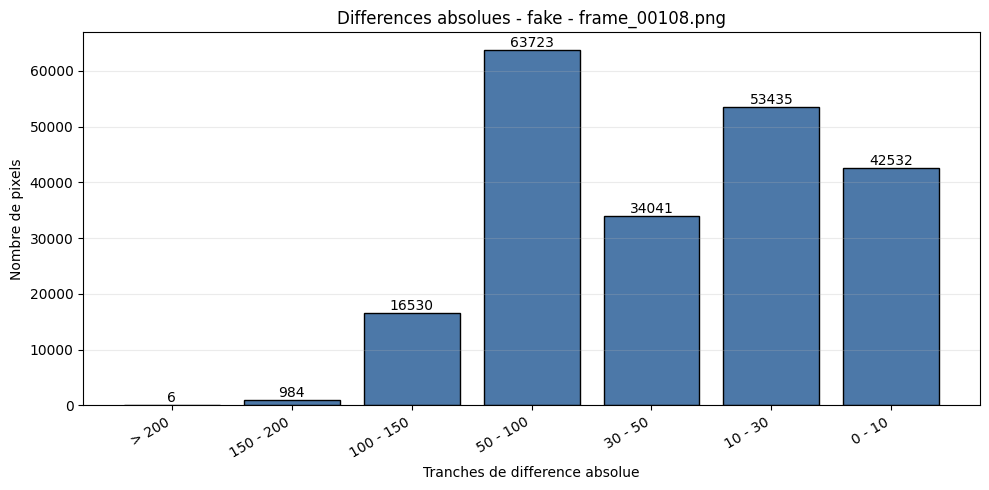

lvl:  4  initial error:  3999.7862669245637
 error improvement too small, level converged! it:  8  error:  2812.3277974038233  lambda:  25.6
lvl:  3  initial error:  2981.57948001234
 error improvement too small, level converged! it:  1  error:  2980.6478844906096  lambda:  0.1
lvl:  2  initial error:  3201.0575228529965
 error improvement too small, level converged! it:  5  error:  3137.033887152565  lambda:  0.0
[fake] frame 109 -> frame_00109.png | sum error = 672562816.00 | mean abs error = 44.0279 | valid pixels = 209686


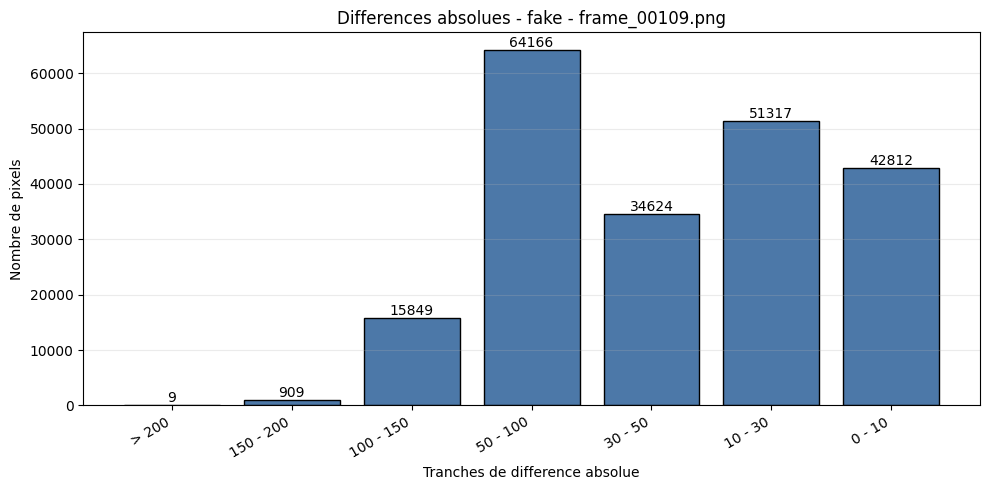

lvl:  4  initial error:  3969.9642166344283
 error improvement too small, level converged! it:  6  error:  2855.9541838232967  lambda:  1759218604441.6
lvl:  3  initial error:  3061.376794383674
 error improvement too small, level converged! it:  7  error:  2990.7136941385024  lambda:  0.0
lvl:  2  initial error:  3128.666456583788
 error improvement too small, level converged! it:  5  error:  3086.9511853060167  lambda:  0.0
[fake] frame 110 -> frame_00110.png | sum error = 678195776.00 | mean abs error = 44.0706 | valid pixels = 210844


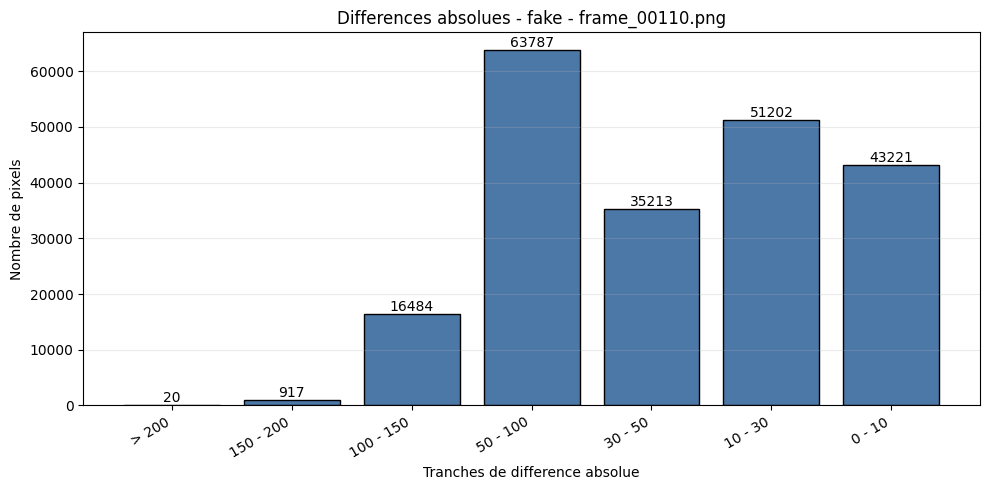

lvl:  4  initial error:  3949.516441005802
update too small, level converged! it:  6  error:  2932.950173790942  lambda:  900719925474099.2
lvl:  3  initial error:  3082.996207265554
 error improvement too small, level converged! it:  5  error:  2960.590683839452  lambda:  0.0
lvl:  2  initial error:  3132.9865157861827
 error improvement too small, level converged! it:  1  error:  3132.1502553721843  lambda:  0.0
[fake] frame 111 -> frame_00111.png | sum error = 692029632.00 | mean abs error = 44.4237 | valid pixels = 212150


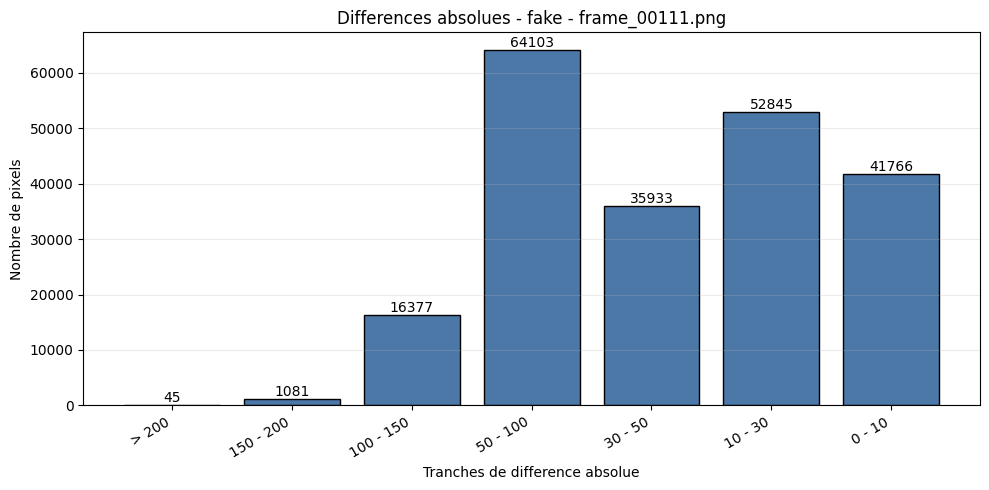

lvl:  4  initial error:  3998.242746615086
 error improvement too small, level converged! it:  6  error:  2936.3264298439594  lambda:  28147497671065.6
lvl:  3  initial error:  3070.939324485677
 error improvement too small, level converged! it:  3  error:  2995.1453200683136  lambda:  6.4
lvl:  2  initial error:  3129.680917503229
 error improvement too small, level converged! it:  1  error:  3128.6676800934556  lambda:  0.0
[fake] frame 112 -> frame_00112.png | sum error = 685149184.00 | mean abs error = 44.3112 | valid pixels = 210902


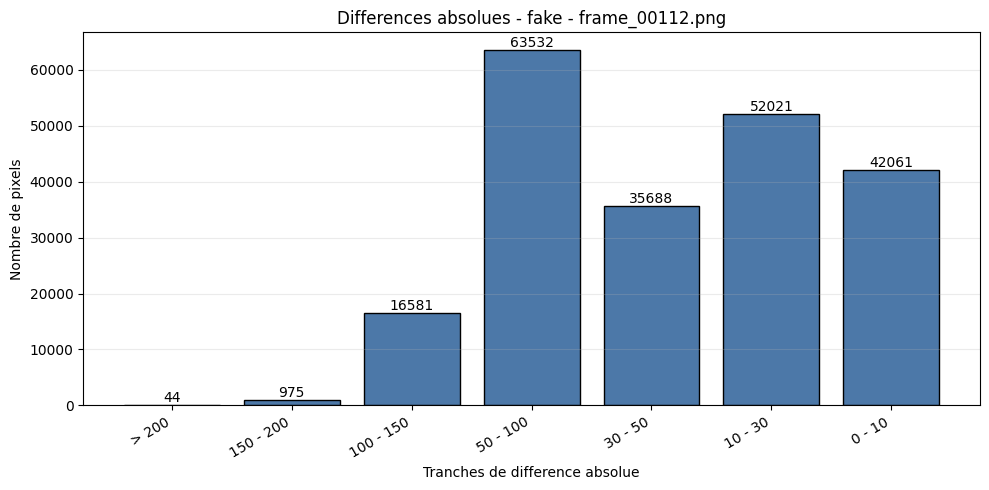

lvl:  4  initial error:  4024.974854932301
 error improvement too small, level converged! it:  9  error:  2897.6842867624896  lambda:  6.4
lvl:  3  initial error:  3122.10665899115
 error improvement too small, level converged! it:  8  error:  3004.2601046019076  lambda:  1.6
lvl:  2  initial error:  3203.850889000317
 error improvement too small, level converged! it:  4  error:  3177.8681250743516  lambda:  0.0
[fake] frame 113 -> frame_00113.png | sum error = 680629760.00 | mean abs error = 44.5218 | valid pixels = 208261


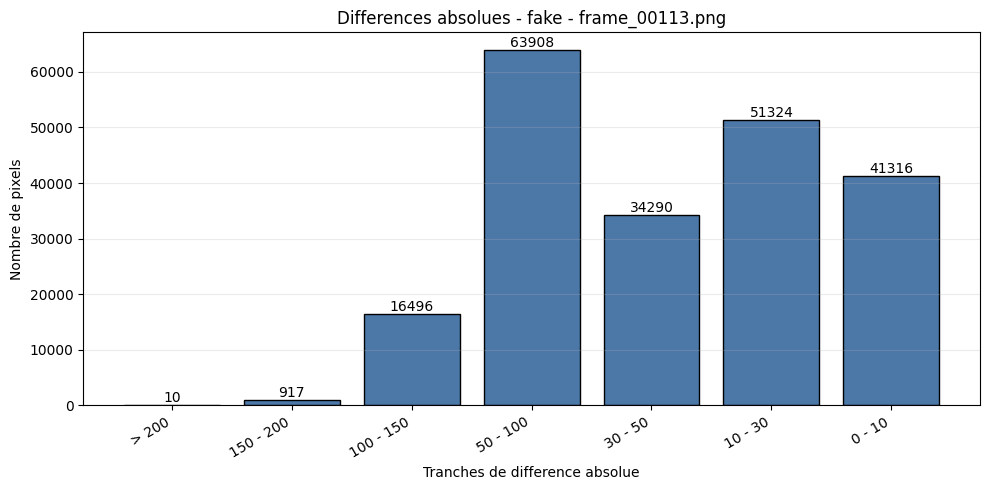

lvl:  4  initial error:  3964.008704061894
 error improvement too small, level converged! it:  5  error:  2902.438319311773  lambda:  28147497671065.6
lvl:  3  initial error:  3123.3280216365556
 error improvement too small, level converged! it:  11  error:  3031.58560501145  lambda:  0.0
lvl:  2  initial error:  3269.0376622100466
 error improvement too small, level converged! it:  5  error:  3247.904696251761  lambda:  0.0
[fake] frame 114 -> frame_00114.png | sum error = 685980288.00 | mean abs error = 44.6527 | valid pixels = 207465


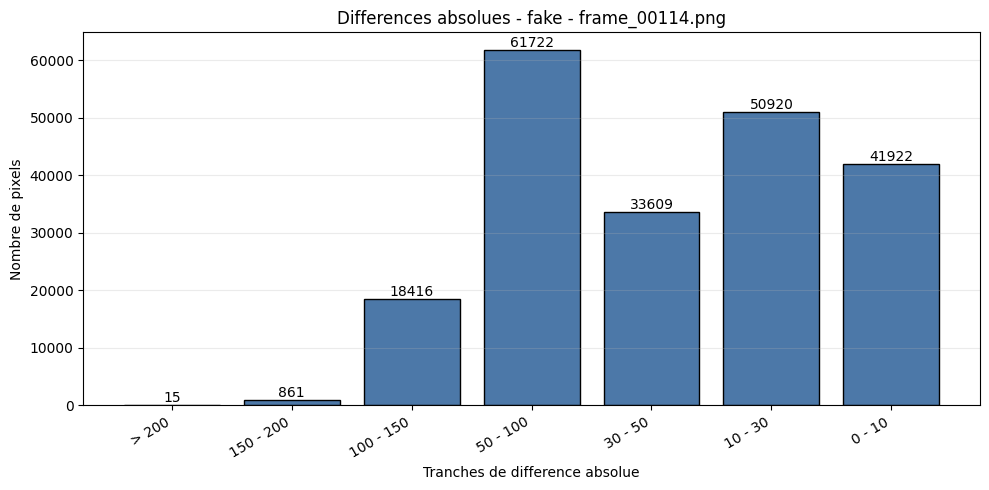

lvl:  4  initial error:  3942.7021276595733
 error improvement too small, level converged! it:  6  error:  2954.220168957542  lambda:  0.1
lvl:  3  initial error:  3125.002239106373
 error improvement too small, level converged! it:  1  error:  3122.672551452018  lambda:  0.1
lvl:  2  initial error:  3305.229695023752
 error improvement too small, level converged! it:  1  error:  3303.0916970727303  lambda:  0.0
[fake] frame 115 -> frame_00115.png | sum error = 711949376.00 | mean abs error = 45.4277 | valid pixels = 209642


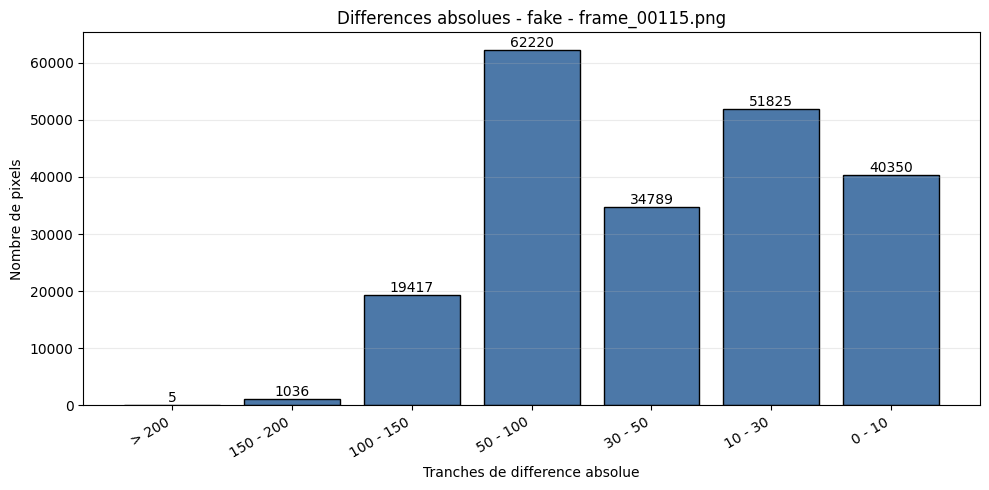

lvl:  4  initial error:  3876.6247582205015
 error improvement too small, level converged! it:  4  error:  2999.923932999651  lambda:  0.1
lvl:  3  initial error:  3217.1166710799002
 error improvement too small, level converged! it:  10  error:  3123.7270758652744  lambda:  0.0
lvl:  2  initial error:  3287.343992292215
 error improvement too small, level converged! it:  5  error:  3258.373764101568  lambda:  0.0
[fake] frame 116 -> frame_00116.png | sum error = 695938112.00 | mean abs error = 45.0529 | valid pixels = 207401


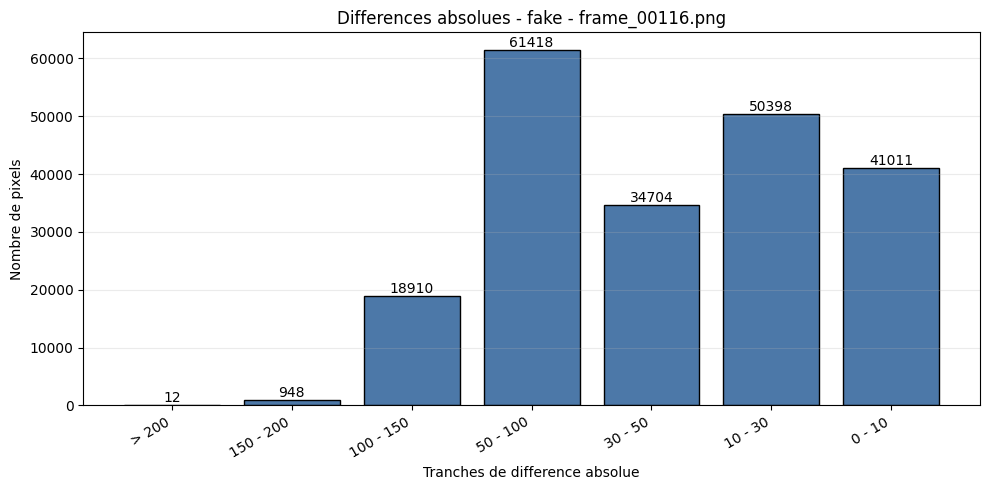

lvl:  4  initial error:  3864.6876208897474
 error improvement too small, level converged! it:  3  error:  3220.5231959508405  lambda:  0.1
lvl:  3  initial error:  3165.81646190464
 error improvement too small, level converged! it:  2  error:  3131.763424956821  lambda:  439804651110.4
lvl:  2  initial error:  3293.232948700213
 error improvement too small, level converged! it:  3  error:  3281.943254655071  lambda:  0.1
[fake] frame 117 -> frame_00117.png | sum error = 711907776.00 | mean abs error = 45.4405 | valid pixels = 208289


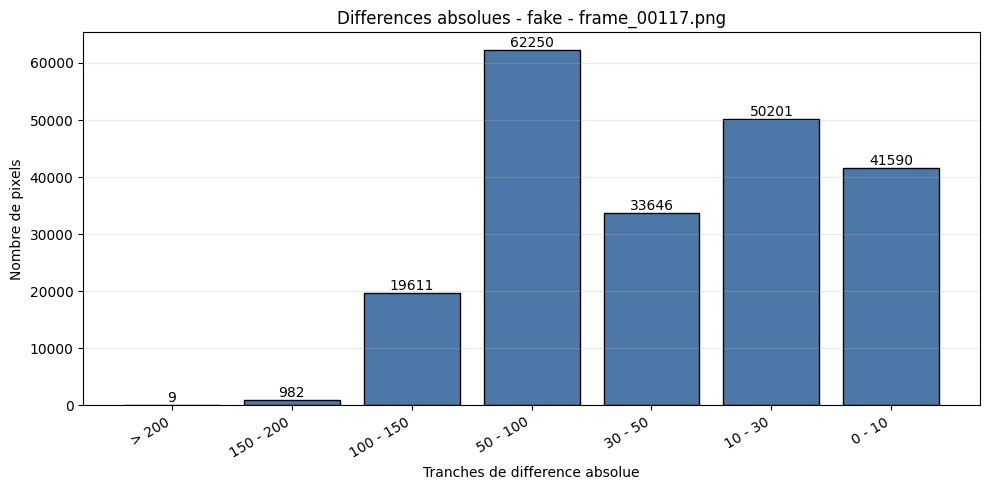

lvl:  4  initial error:  3869.1576402321075
 error improvement too small, level converged! it:  2  error:  3271.55983034989  lambda:  0.2
lvl:  3  initial error:  3179.9813633946414
update too small, level converged! it:  3  error:  3131.752475822499  lambda:  225179981368524.8
lvl:  2  initial error:  3338.137034771097
 error improvement too small, level converged! it:  1  error:  3338.0907198614404  lambda:  12.8
[fake] frame 118 -> frame_00118.png | sum error = 724809920.00 | mean abs error = 45.8782 | valid pixels = 209117


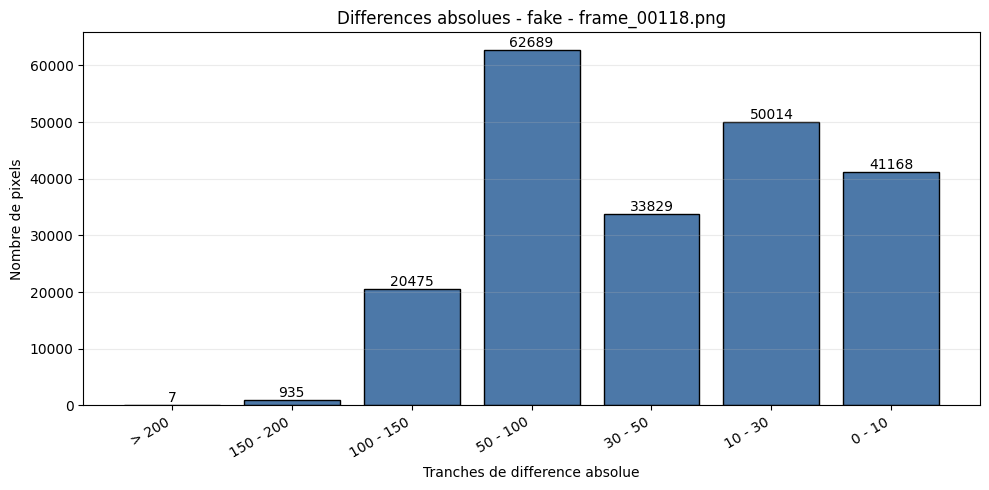

lvl:  4  initial error:  3836.858800773693
 error improvement too small, level converged! it:  7  error:  3200.7166044970377  lambda:  0.1
lvl:  3  initial error:  3304.5087780369026
 error improvement too small, level converged! it:  6  error:  3125.7471041362387  lambda:  0.0
lvl:  2  initial error:  3373.9691104215017
 error improvement too small, level converged! it:  9  error:  3334.955159826507  lambda:  0.0
[fake] frame 119 -> frame_00119.png | sum error = 714867968.00 | mean abs error = 45.5779 | valid pixels = 208258


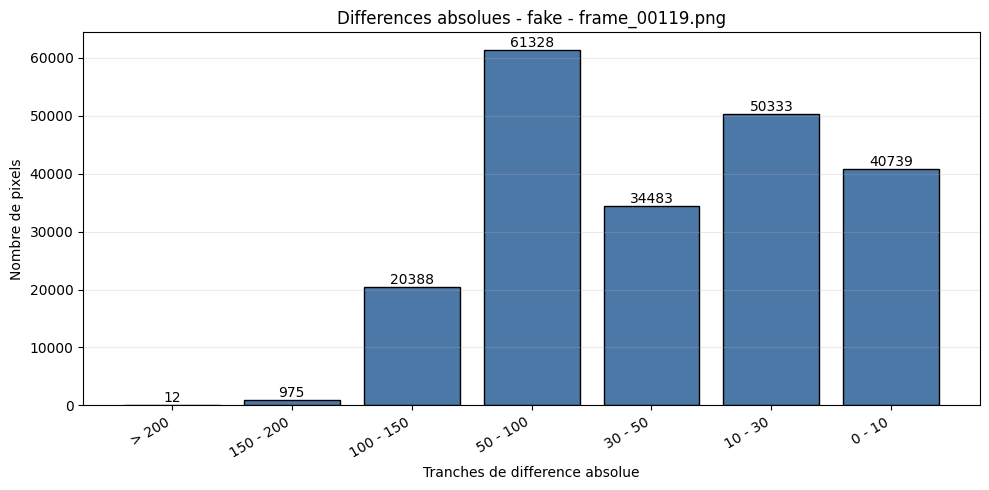

In [72]:
# Boucle simple sur toute la sequence: depth estimation puis pose estimation par frame.
# Cette version reconstruit une camera coherente pour la sequence traitee
# et reinitialise le solveur pour eviter de reutiliser un etat precedent.
frame_paths = fake_frame_paths[0:120]





if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_name = "fake"
sequence_keyframe = None
sequence_results = []

first_image_path = normalize_image_path(frame_paths[0])
first_image = load_gray_image(first_image_path)
sequence_height, sequence_width = first_image.shape[:2]

sequence_cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    sequence_width,
    sequence_height,
)
sequence_pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(sequence_cam, show_debug=False)

print(f"Sequence {sequence_name}:")
print(f"  source size = {sequence_width} x {sequence_height}")
print(f"  working size level-0 = {sequence_cam.width[0]} x {sequence_cam.height[0]}")
print(f"  fx level-0 = {sequence_cam.fx[0]}")
print(f"  fy level-0 = {sequence_cam.fy[0]}")
print()

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)

    if image.shape[:2] != (sequence_height, sequence_width):
        raise ValueError(
            f"Toutes les images de la sequence {sequence_name} doivent avoir la meme taille. "
            f"Attendu: {(sequence_height, sequence_width)}, obtenu: {image.shape[:2]} pour {image_path.name}"
        )

    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        print(f"[{sequence_name}] frame {step} -> keyframe de reference: {image_path.name}")
        sequence_results.append({
            "index": step,
            "image_path": str(image_path),
            "depth_valid_ratio": float(depth_valid_mask.mean()),
            "pose_matrix": current_frame.pose.as_matrix(),
            "photometric_error": None,
            "photometric_error_mean": None,
            "valid_pixel_count": None,
            "histogram_counts": None,
        })
        continue

    sequence_pose_solver.optPose(current_frame, sequence_keyframe)
    evaluation = compute_photometric_error(current_frame, sequence_keyframe, sequence_cam, lvl=0)

    abs_error_map = np.sqrt(evaluation["squared_error_map"])
    valid_mask = evaluation["valid_mask"]
    valid_abs_errors = abs_error_map[valid_mask]
    valid_pixel_count = int(valid_abs_errors.size)
    photometric_error = float(evaluation["photometric_error"])
    photometric_error_mean = float(valid_abs_errors.mean()) if valid_pixel_count > 0 else None
    mean_error_display = f"{photometric_error_mean:.4f}" if photometric_error_mean is not None else "None"

    print(
        f"[{sequence_name}] frame {step} -> {image_path.name} | "
        f"sum error = {photometric_error:.2f} | "
        f"mean abs error = {mean_error_display} | "
        f"valid pixels = {valid_pixel_count}"
    )

    num_gt_200 = int(np.sum(valid_abs_errors > 200))
    num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
    num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
    num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))
    num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))
    num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))
    num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

    range_labels = [
        "> 200",
        "150 - 200",
        "100 - 150",
        "50 - 100",
        "30 - 50",
        "10 - 30",
        "0 - 10",
    ]

    range_counts = [
        num_gt_200,
        num_150_200,
        num_100_150,
        num_50_100,
        num_30_50,
        num_10_30,
        num_0_10,
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
    plt.title(f"Differences absolues - {sequence_name} - {image_path.name}")
    plt.xlabel("Tranches de difference absolue")
    plt.ylabel("Nombre de pixels")
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=30, ha="right")

    for bar, count in zip(bars, range_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    sequence_results.append({
        "index": step,
        "image_path": str(image_path),
        "depth_valid_ratio": float(depth_valid_mask.mean()),
        "pose_matrix": current_frame.pose.as_matrix(),
        "photometric_error": photometric_error,
        "photometric_error_mean": photometric_error_mean,
        "valid_pixel_count": valid_pixel_count,
        "histogram_counts": range_counts,
    })


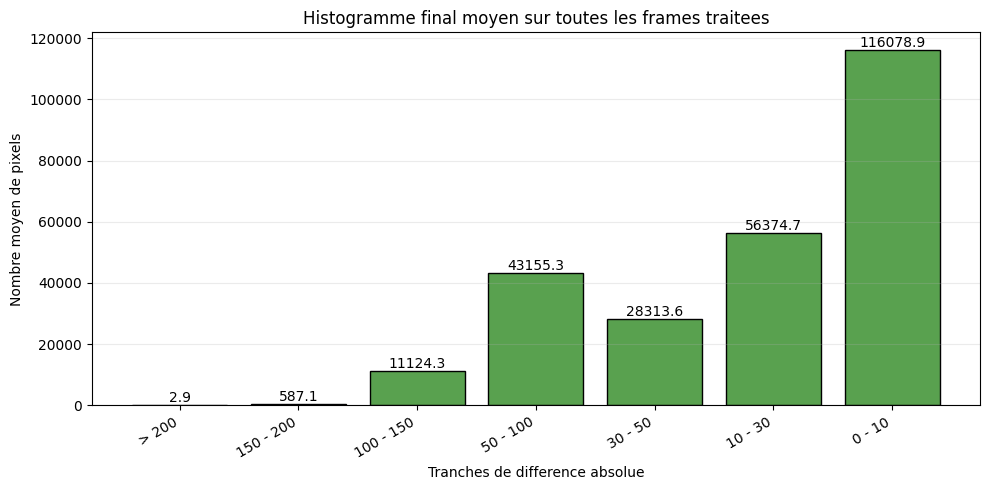

Histogramme final moyen:
     > 200 -> 2.87
  150 - 200 -> 587.10
  100 - 150 -> 11124.26
  50 - 100 -> 43155.33
   30 - 50 -> 28313.61
   10 - 30 -> 56374.66
    0 - 10 -> 116078.91


In [73]:
valid_histogram_results = [
    item for item in sequence_results
    if item.get("histogram_counts") is not None
]

if not valid_histogram_results:
    raise ValueError("Aucun histogramme valide disponible pour calculer la moyenne finale.")

histogram_matrix = np.array([item["histogram_counts"] for item in valid_histogram_results], dtype=np.float64)
mean_histogram_counts = histogram_matrix.mean(axis=0)

final_range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

plt.figure(figsize=(10, 5))
bars = plt.bar(final_range_labels, mean_histogram_counts, color="#59A14F", edgecolor="black")
plt.title("Histogramme final moyen sur toutes les frames traitees")
plt.xlabel("Tranches de difference absolue")
plt.ylabel("Nombre moyen de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, mean_histogram_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print("Histogramme final moyen:")
for label, value in zip(final_range_labels, mean_histogram_counts):
    print(f"  {label:>8} -> {value:.2f}")


458334555.33613443


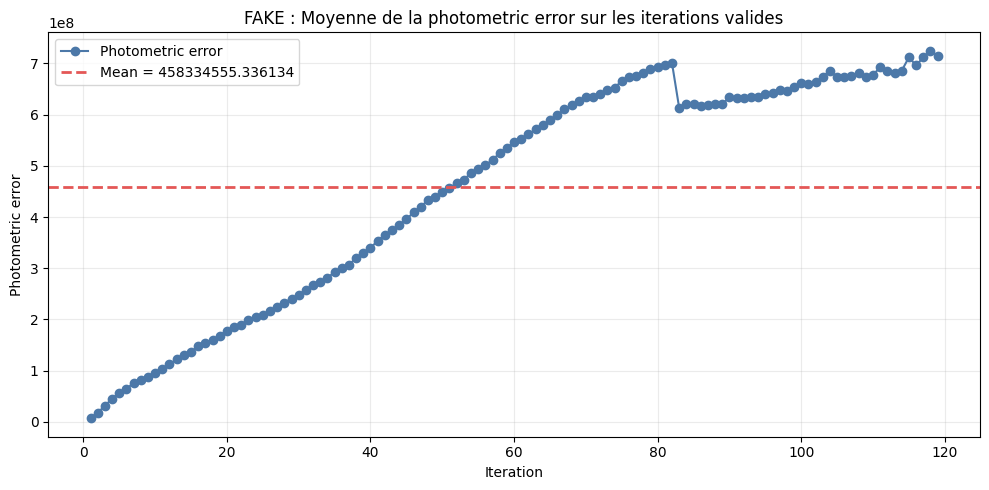

In [74]:
valid_results = [
    item for item in sequence_results
    if item["photometric_error"] is not None
]

if not valid_results:
    raise ValueError("Aucun résultat valide disponible pour calculer la moyenne des erreurs photométriques.")

iteration_indices = [item["index"] for item in valid_results]
photometric_errors = [item["photometric_error"] for item in valid_results]
mean_photometric_error = float(np.mean(photometric_errors))

print(mean_photometric_error)

plt.figure(figsize=(10, 5))
plt.plot(iteration_indices, photometric_errors, marker="o", color="#4C78A8", label="Photometric error")
plt.axhline(
    mean_photometric_error,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_photometric_error:.6f}"
)
plt.title("FAKE : Moyenne de la photometric error sur les iterations valides")
plt.xlabel("Iteration")
plt.ylabel("Photometric error")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()